# Person Data Analysis

This notebook contains the analysis of initial person authority data from 4 different Belgian Federal Scientific Institutes:

* Royal Library of Belgium
* Royal Institute for Cultural Heritage
* Royal Museums of Art and History
* Royal Museums of Fine Arts

Data dumps from each instiution were received or downloaded in different XML formats. In the following we will count how often MetaBelgica-relevant data fields are filled in, which will also entail standardization and uniformization of date and location values. This will not only allow us a comprehensive view across the data sources, but also ease future tasks of integrating the data by identifying the overlap of person authorities.

Several CSV files are generated by this notebook. Those files either contain data that needs to be checked and curated manually or contain standardized values that can be used to enrich the respective data source. For example, thousands of previously undstandardized dates from MARC field `100$d` at KBR are standardized and can be used to enrich the records' MARC field `046`.

**Released versions**

| Version | DOI | Date | Comment |
| --------|-----|------|---------|
| recent | https://doi.org/10.5281/zenodo.15120908 | recent | This DOI represents all versions and will link to the most recent version |
| v0.1.0 | https://doi.org/10.5281/zenodo.15120909 | 2025-04-01 | Person analysis with fields: name, alternateNames, birth/death date and birth/death place. |
| tbd | tbd | tbd | Added analysis of person fields: nationality, gender and occupation (or role).  Also adding manual corrections of the partner institutions. The filter criteria were adapted to only include creators, this means for KIK-IRPA there are now around 30k records instead of 80k. |

In [1]:
# setting to autoreload Python files if they have changed
%load_ext autoreload
%autoreload 2

# used software libraries for data management
import pandas as pd
import json
import ast
import os
import numpy as np

# used software libraries for visualization
from venn import venn
import matplotlib.pyplot as plt
import seaborn as sns

# used own software libraries
import notebook_utils
import utils
from xml_to_csv.xml_to_csv import main as xml_to_csv
import xml_to_csv.utils as xml_to_csv_utils
from geoname_enrichment.geoname_enrichment import main as enrich_with_geoname
from split_place_country import main as split_place_country

## Prepare input data

We first have to extract the data and then remove potentially irrelevant records.

### Data extraction

We first extract the data and count how often some specific fields are filled in. Below you can see a general configuration that defines relevant file names.
There currently seems to be a bug when calling the streaming-based extraction script from within the notebook that causes to skip the last few records of a stream (but it will only be executed when `extractAgain = True`). Hence we recommend to call the extraction scripts from the command line beforehand and keep `extractAgain` to `False`.

At the end of this section the data of the MetaBelgica partners are available in different Pandas dataframes.

In [2]:
# ##################################################################################################
# SCRIPT CONFIGURATION

extractAgain = False
enrichGeoAgain = False # this entails calling an API for each and every record and hence can take a while
useEnriched100d = True # use extracted standardized KBR 100$d dates for dates statistics
statsDataframes = []

# config file that specifies many regular expression patterns for the extraction of diverse date values
dateMappingConfigFile = 'date-mapping.json'

# ##################################################################################################
# OUTPUT FILES
outputDir = 'stats-2026-04-01'

# data categorized according to data quality categories
qualityCategorizationFilename = os.path.join(outputDir, 'categorized-data.csv')
qualityCategorizationDataframesDir = os.path.join(outputDir, 'fields')

# duplicate authority identifiers in data sources (usually empty)
duplicateAutIDofMainDf = os.path.join(outputDir, 'duplicate-autID-main-dataframe.csv')

# duplicate authority identifiers when merging main df with enriched 1:n files 
duplicateAutIDofMainDfCategories = os.path.join(outputDir, 'duplicate-autID-enriched.csv')

# duplicate authority identifiers after merging main df with 1:n file '100d-dates'
kbrDuplicate100dDateValues = os.path.join(outputDir, 'duplicate-values-kbr-100d.csv')

duplicateBirthDates = os.path.join(outputDir, 'duplicate-birth-dates.csv')
duplicateDeathDates = os.path.join(outputDir, 'duplicate-death-dates.csv')

# Dates in this file needs to be checked and splitted manually
kbr100dDateSplitProblem = os.path.join(outputDir, 'kbr-100d-split-problem.csv')

# Dates in these files can be used to enrich 046$f (birth) and 046$g (death) dates automatically
kbr100dDateCertainBirthDates = os.path.join(outputDir, 'kbr-birthDates-certain.csv')
kbr100dDateCertainDeathDates = os.path.join(outputDir, 'kbr-deathDates-certain.csv')

# Dates in these files still need to be curated manually
kbr100dDateCertainBirthDatesNotParsed = os.path.join(outputDir, 'kbr-birthDates-certain-not-parsed.csv')
kbr100dDateCertainDeathDatesNotParsed = os.path.join(outputDir, 'kbr-deathDates-certain-not-parsed.csv')

# Dates in these files can be used to indicate an uncertain birth/death date in 046$f/046$g
kbr100dDateUncertainBirthDates = os.path.join(outputDir, 'kbr-birthDates-uncertain.csv')
kbr100dDateUncertainDeathDates = os.path.join(outputDir, 'kbr-deathDates-uncertain.csv')

# Dates in these files still need to be curated manually
kbr100dDateUncertainBirthDatesNotParsed = os.path.join(outputDir, 'kbr-birthDates-uncertain-not-parsed.csv')
kbr100dDateUncertainDeathDatesNotParsed = os.path.join(outputDir, 'kbr-deathDates-uncertain-not-parsed.csv')

# Dates in these files can be used to enrich 046$s and 046$t (structured flourish start and flourish end)
kbr100dDateFormattedFlourishStart = os.path.join(outputDir, 'kbr-flourish-date-start.csv')
kbr100dDateFormattedFlourishEnd = os.path.join(outputDir, 'kbr-flourish-date-end.csv')

# Dates in these files still need to be curated manually
kbr100dDateFormattedFlourishStartNotParsed = os.path.join(outputDir, 'kbr-flourish-date-start-not-parsed.csv')
kbr100dDateFormattedFlourishEndNotParsed = os.path.join(outputDir, 'kbr-flourish-date-end-not-parsed.csv')

# additionally manually curated data


In [3]:
# this dictionary contains relevant filenames and variables to build subsequent result files per data source
extractInfo = {
              "KIK-IRPA": {"inputFilename":"kik-irpa/Export_people_EN.xml", 
                           "outputFilename": "kik-irpa/kik-irpa-data-2026.csv", 
                           "configFilename": "extract-config-kik-irpa.json",
                           "dateConfigFilename": dateMappingConfigFile,
                           "prefix":"kik-irpa-data-2026",
                           "geo-enriched-birth-place": "kik-irpa/kik-irpa-data-2026-birthPlace-enriched.csv",
                           "geo-enriched-death-place": "kik-irpa/kik-irpa-data-2026-deathPlace-enriched.csv",
                           "curated": {
                                "birthDates": [],
                                "deathDates": [],
                                "birthPlaces": ["kik-irpa/enriched/Birth_place_CORR_KIK_IRPA.csv"],
                                "deathPlaces": ["kik-irpa/enriched/Death_place_CORR_KIK_IRPA.csv"],
                                "birthPlacesEnriched": ["kik-irpa/enriched/birth_places_label_enriched.csv"],
                                "deathPlacesEnriched": ["kik-irpa/enriched/death_places_label_enriched.csv"]
                    }
                          },
            "KBR": {"inputFilename":"kbr/2026-03-20_apep.xml", 
                       "outputFilename": "kbr/kbr-data-2026.csv", 
                       "100dDatesFilename": "kbr/kbr-data-2026-dates100d.csv",
                       "configFilename": "extract-config-kbr.json", 
                       "dateConfigFilename": dateMappingConfigFile,
                       "prefix":"kbr-data-2026",
                       "geo-enriched-birth-place": "kbr/kbr-data-2026-birthPlace-enriched.csv",
                       "geo-enriched-death-place": "kbr/kbr-data-2026-deathPlace-enriched.csv",
                    "curated": {
                        "birthDates": [],
                        "deathDates": [],
                        "birthPlaces": [],
                        "deathPlaces": [],
                        "birthPlacesEnriched": [],
                        "deathPlacesEnriched": []
                    }
                   },
              "KMSKB": {"inputFilename":"kmskb/250909_CREATORS_fixed.xml", 
                        "outputFilename": "kmskb/kmskb-data.csv", 
                        "configFilename": "extract-config-kmskb.json", 
                        "dateConfigFilename": dateMappingConfigFile,
                        "prefix":"kmskb-data",
                        "geo-enriched-birth-place": "kmskb/kmskb-data-birthPlace-enriched.csv",
                        "geo-enriched-death-place": "kmskb/kmskb-data-deathPlace-enriched.csv",
                        "curated": {
                            "birthDates": ["kmskb/enriched/20251105_kmskb-data-birthDate-enriched.csv"],
                            "deathDates": ["kmskb/enriched/20251105_kmskb-data-deathDate-enriched.csv"],
                            "birthPlaces": ["kmskb/enriched/250909_kmskb-data-birthPlace-enriched.csv"],
                            "deathPlaces": ["kmskb/enriched/250909_kmskb-data-deathPlace-enriched.csv"],
                            "birthPlacesEnriched": ["kmskb/enriched/birth_places_label_enriched.csv"],
                            "deathPlacesEnriched": ["kmskb/enriched/death_places_label_enriched.csv"]
                    }
                       },
              "KMKG": {"inputFilename":"kmkg/Authors_KMKG-MRAH.xml", 
                       "outputFilename": "kmkg/kmkg-data.csv", 
                       "configFilename": "extract-config-kmkg.json",
                       "dateConfigFilename": dateMappingConfigFile,
                       "prefix":"kmkg-data",
                       "geo-enriched-birth-place": "kmkg/kmkg-data-birthPlace-enriched.csv",
                       "geo-enriched-death-place": "kmkg/kmkg-data-deathPlace-enriched.csv",
                       "curated": {
                            "birthDates": ["kmkg/enriched/kmkg-data-birthDate_Marianne.csv"],
                            "deathDates": ["kmkg/enriched/kmkg-data-deathDate-Marianne.csv"],
                            "birthPlaces": ["kmkg/enriched/kmkg-data-birthPlace-enriched_Multiple API results_Nacha_Sven.csv",
                                           "kmkg/enriched/kmkg-data-birthPlace-enriched_No API response_Heloise_Sven.csv"],
                            "deathPlaces": ["kmkg/enriched/kmkg-data-deathPlace-enriched_Multiple API results_Angelique_Sven.csv",
                                           "kmkg/enriched/kmkg-data-deathPlace-No API response_Marianne.csv"],
                            "birthPlacesEnriched": ["kmkg/enriched/birth_places_label_enriched_Nacha.csv",
                                                    "kmkg/enriched/birth_places_label_enriched_Heloise.csv"],
                            "deathPlacesEnriched": ["kmkg/enriched/death_places_label_enriched_Angelique.csv",
                                                    "kmkg/enriched/death_places_label_enriched_Marianne.csv"],
                            "manual-curation-identifiers": "kmkg/kmkg-data-extraIdentifiers.csv",
                            "manual-curation-to-delete": "kmkg/kmkg-delete-vorige-eigenaars.csv",
                    }
                      }
              }

In [4]:
# extract CSV data from the specified XML files
# (as mentioned above, due to a bug when calling from the Jupyter notebook 
# ideally call the xml_to_csv script on the commandline)
#
if extractAgain:
    for dataSource, info in extractInfo.items():

        logFileName = os.path.join(os.path.dirname(info['outputFilename']), f'{info["prefix"]}.log')
        print(f'Extracting data from {dataSource} (logging to {logFileName})')
        xml_to_csv([info['inputFilename']], info['outputFilename'], info['configFilename'], info['dateConfigFilename'], info['prefix'], False, logFile=logFileName)


The following piece of code reads data from the extraction step into different dataframes. The extraction phase created one main CSV file per data source as well as different CSV files per column, e.g. `kbr-data.csv` as well as `kbr-birthDate.csv` or `kbr-deathDate.csv`.

All main CSV files will be available in the variable `df` and content of specific data sources can be filtered via the column `dataSource`. For example `df[df['dataSource'] == 'KBR']`.

Similarly all column-specific CSV files will be loaded into single dataframes. To have these dataframes available at one place, they will be added to the dictionary `valueDataframes`. Thus all `1:n` birth date values can be accessed in a dataframe stored in `valueDataframes['birthDate']`. Retrieving all birth date values from KBR is then possible by calling `valueDataframes['birthDate'][valueDataframes['birthDate']['dataSource'] == 'KBR']`.

Or simplified for readability `birthDateDf = valueDataframes['birthDate']` and then afterwards `birthDateDf[birthDateDf['dataSource'] == 'KBR']`.

In [5]:
# load CSV data into Pandas dataframes
#

# a list of dataframes per data source that later will be used to create a single merged dataframe
dataframes = []

# a dictionary of dataframes of specific columns
# merged versions will be available via the variable valueDataframes
# For example valueDataframes['birthDate'] will be a single dataframe 
# with all birthDate values of the different data sources that can be filtered on the column 'dataSource'
allValueDataframes = {'name': [], 'alternateNames': [], 'birthDate': [], 'deathDate': [], 'birthPlace': [], 'deathPlace': [],
                     'nationality': [], 'role': [], 'gender': [], 'isni': [], 'viaf': [], 'wikidata': [], 'rkd': []}
valueDataframes = allValueDataframes.copy()

for dataSource, info in extractInfo.items():
    
    # read main dataframe
    currentDf = pd.read_csv(info['outputFilename'], 
                            converters={"name": utils.jsonParser, 
                                        "isni": utils.jsonParser, 
                                        "birthDate": utils.jsonParser, 
                                        "deathDate": utils.jsonParser, 
                                        "alternateNames": utils.jsonParser,
                                        "nameComponents": utils.jsonParser,
                                        "pseudonyms": utils.jsonParser, 
                                        "viaf": utils.jsonParser, 
                                        "bnf": utils.jsonParser, 
                                        "birthPlace": utils.jsonParser, 
                                        "deathPlace": utils.jsonParser, 
                                        "nationality": utils.jsonParser,
                                        "role": utils.jsonParser,
                                        "gender": utils.jsonParser},
                            keep_default_na=False)
    
    # explicitly indicate the data source in a separate column
    currentDf['dataSource'] = dataSource
    
    dataframes.append(currentDf)
    
    # read dataframes per value
    for col, colList in allValueDataframes.items():
        colFile = info['outputFilename'].replace('.csv', f'-{col}.csv')
        if os.path.isfile(colFile):
            print(f'processing {colFile}')
            currentColDf = pd.read_csv(colFile, keep_default_na=False)
            # explicitly indicate the data source in a separate column
            currentColDf['dataSource'] = dataSource
            currentColDf = currentColDf.drop_duplicates()
            currentColDf = currentColDf.set_index('autID')
            colList.append(currentColDf)
        else:
            print(f'no file found for {col}, adding empty dataframe')
            colList.append(pd.DataFrame(columns=[col, 'dataSource']).rename_axis('autID'))
        
for col, colList in allValueDataframes.items():
    valueDataframes[col] = pd.concat(colList)
    
df = pd.concat(dataframes)
df = df.set_index('autID')

processing kik-irpa/kik-irpa-data-2026-name.csv
processing kik-irpa/kik-irpa-data-2026-alternateNames.csv
processing kik-irpa/kik-irpa-data-2026-birthDate.csv
processing kik-irpa/kik-irpa-data-2026-deathDate.csv
processing kik-irpa/kik-irpa-data-2026-birthPlace.csv
processing kik-irpa/kik-irpa-data-2026-deathPlace.csv
processing kik-irpa/kik-irpa-data-2026-nationality.csv
processing kik-irpa/kik-irpa-data-2026-role.csv
processing kik-irpa/kik-irpa-data-2026-gender.csv
processing kik-irpa/kik-irpa-data-2026-isni.csv
no file found for viaf, adding empty dataframe
no file found for wikidata, adding empty dataframe
no file found for rkd, adding empty dataframe


/tmp/ipykernel_7159/458850517.py:18: DtypeWarning: Columns (3,6,8,10,12,13,14,15,16) have mixed types. Specify dtype option on import or set low_memory=False.
  currentDf = pd.read_csv(info['outputFilename'],


processing kbr/kbr-data-2026-name.csv
processing kbr/kbr-data-2026-alternateNames.csv
processing kbr/kbr-data-2026-birthDate.csv
processing kbr/kbr-data-2026-deathDate.csv
processing kbr/kbr-data-2026-birthPlace.csv
processing kbr/kbr-data-2026-deathPlace.csv
processing kbr/kbr-data-2026-nationality.csv
processing kbr/kbr-data-2026-role.csv
processing kbr/kbr-data-2026-gender.csv
processing kbr/kbr-data-2026-isni.csv
processing kbr/kbr-data-2026-viaf.csv
no file found for wikidata, adding empty dataframe
no file found for rkd, adding empty dataframe
processing kmskb/kmskb-data-name.csv
no file found for alternateNames, adding empty dataframe
processing kmskb/kmskb-data-birthDate.csv
processing kmskb/kmskb-data-deathDate.csv
processing kmskb/kmskb-data-birthPlace.csv
processing kmskb/kmskb-data-deathPlace.csv
processing kmskb/kmskb-data-nationality.csv
processing kmskb/kmskb-data-role.csv
processing kmskb/kmskb-data-gender.csv
no file found for isni, adding empty dataframe
no file found

In [6]:
df[df.index =='kmskb|509/2126']

,isni,name,alternateNames,birthDate-original,birthDate,deathDate-original,deathDate,birthPlace-original,birthPlace,deathPlace-original,...,dataSource,pseudonyms,dates100d,viaf,nameComponents,bnf,ulan,wikipedia,website,loc
autID,,,,,,,,,,,,,,,,,,,,,
kmskb|509/2126,NaN,"[MEESTER VAN FLÉMALLE / MAÎTRE DE FLÉMALLE, Test]",NaN,,"[{'birthDate': '1375~', 'rule': 'circa_year', ...",,"[{'deathDate': '1444', 'rule': 'simplePattern'...",NaN,NaN,NaN,...,KMSKB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
valueDataframes['birthDate'][valueDataframes['birthDate'].index == 'kmskb|509/2126']

,birthDate,birthDate-original,rule,dataSource
autID,,,,
kmskb|509/2126,1375~,ca. 1375,circa_year,KMSKB


In [8]:
df[df.index == 'kmskb|509/2557']

,isni,name,alternateNames,birthDate-original,birthDate,deathDate-original,deathDate,birthPlace-original,birthPlace,deathPlace-original,...,dataSource,pseudonyms,dates100d,viaf,nameComponents,bnf,ulan,wikipedia,website,loc
autID,,,,,,,,,,,,,,,,,,,,,
kmskb|509/2557,NaN,NaN,NaN,,"[{'birthDate': '1821', 'rule': 'simplePattern'...",,"[{'deathDate': '1884', 'rule': 'simplePattern'...",NaN,NaN,NaN,...,KMSKB,NaN,NaN,NaN,[{'lastName': 'van Imschoot;van Imschoot;van I...,NaN,NaN,NaN,NaN,NaN


In [9]:
# preview of the main dataframe containing data from the main CSV files per data source
df

,isni,name,alternateNames,birthDate-original,birthDate,deathDate-original,deathDate,birthPlace-original,birthPlace,deathPlace-original,...,dataSource,pseudonyms,dates100d,viaf,nameComponents,bnf,ulan,wikipedia,website,loc
autID,,,,,,,,,,,,,,,,,,,,,
kik-irpa|19,NaN,"[Loze, Pierre]",NaN,,NaN,,NaN,,NaN,,...,KIK-IRPA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
kik-irpa|42,NaN,[Masson],NaN,,NaN,,NaN,,NaN,,...,KIK-IRPA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
kik-irpa|61,NaN,"[Restany, Pierre]",NaN,,NaN,,NaN,,NaN,,...,KIK-IRPA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
kik-irpa|64,NaN,"[Díaz Padrón, Matías]",NaN,,"[{'birthDate': '1935', 'rule': 'simplePattern'...",,"[{'deathDate': '2022', 'rule': 'simplePattern'...",,NaN,,...,KIK-IRPA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
kik-irpa|65,NaN,"[Padrón Mérida, Aida]",NaN,,NaN,,NaN,,NaN,,...,KIK-IRPA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
kmkg|5750,[0000000114445455],"[Zoritchak, Yan]",NaN,,NaN,,NaN,NaN,"[{'birthTown': 'Ždiar', 'birthCountry': 'Slova...",NaN,...,KMKG,NaN,NaN,NaN,NaN,NaN,,['https://fr.wikipedia.org/wiki/Yan_Zoritchak'],,['http://id.loc.gov/authorities/names/n92053567']
kmkg|4830,NaN,[Zuccarelli],NaN,,NaN,,NaN,NaN,NaN,NaN,...,KMKG,NaN,NaN,NaN,NaN,NaN,,,,
kmkg|2315,NaN,[Zumpe],NaN,,NaN,,NaN,NaN,NaN,NaN,...,KMKG,NaN,NaN,NaN,NaN,NaN,,,,


In [10]:
df[df.index == 'kmskb|509/2579']

,isni,name,alternateNames,birthDate-original,birthDate,deathDate-original,deathDate,birthPlace-original,birthPlace,deathPlace-original,...,dataSource,pseudonyms,dates100d,viaf,nameComponents,bnf,ulan,wikipedia,website,loc
autID,,,,,,,,,,,,,,,,,,,,,
kmskb|509/2579,NaN,NaN,NaN,,"[{'birthDate': '1761', 'rule': 'simplePattern'...",,"[{'deathDate': '1845', 'rule': 'simplePattern'...",NaN,NaN,NaN,...,KMSKB,NaN,NaN,NaN,"[{'lastName': 'Boilly;Boilly', 'firstName': 'L...",NaN,NaN,NaN,NaN,NaN


In [11]:
valueDataframes['birthDate'][valueDataframes['birthDate'].index == 'kik-irpa|68']

,birthDate,birthDate-original,rule,dataSource
autID,,,,
kik-irpa|68,1525,1525,simplePattern,KIK-IRPA


In [12]:
valueDataframes['birthDate'][valueDataframes['birthDate']['dataSource'] == 'KIK-IRPA']

,birthDate,birthDate-original,rule,dataSource
autID,,,,
kik-irpa|64,1935,1935,simplePattern,KIK-IRPA
kik-irpa|68,1525,1525,simplePattern,KIK-IRPA
kik-irpa|69,1924,1924,simplePattern,KIK-IRPA
kik-irpa|112,1892,1892,simplePattern,KIK-IRPA
kik-irpa|113,1944,1944,simplePattern,KIK-IRPA
...,...,...,...,...
kik-irpa|268029,1974,1974,simplePattern,KIK-IRPA
kik-irpa|268038,1951,1951,simplePattern,KIK-IRPA
kik-irpa|268040,1951,1951,simplePattern,KIK-IRPA


In [13]:
# test for duplicate detection
duplicateTestDf = pd.DataFrame([
    {'autID': '1', 'birthDate': '1930', 'rule': 'simplePattern', 'otherCol': [{'id': '1', 'val': 'A'}]},
    {'autID': '1', 'birthDate': '1931', 'rule': 'simplePattern', 'otherCol': [{'id': '2', 'val': 'A'}]},
    {'autID': '2', 'birthDate': '1930', 'rule': 'simplePattern', 'otherCol': [{'id': '1', 'val': 'A'}]},
    {'autID': '3', 'birthDate': '1890', 'rule': 'simplePattern', 'otherCol': np.nan},
    {'autID': '3', 'birthDate': '1890', 'rule': 'simplePattern', 'otherCol': np.nan}
])
duplicateTestDf = duplicateTestDf.set_index('autID')
duplicateTestDf

,birthDate,rule,otherCol
autID,,,
1,1930,simplePattern,"[{'id': '1', 'val': 'A'}]"
1,1931,simplePattern,"[{'id': '2', 'val': 'A'}]"
2,1930,simplePattern,"[{'id': '1', 'val': 'A'}]"
3,1890,simplePattern,NaN
3,1890,simplePattern,NaN


In [14]:
# fails because of lists in 'otherCol'
#
# duplicateTestDf[duplicateTestDf.duplicated()] 

# lists handled correctly, but wrongly reports a duplicate, 
# because index is not taken into account, only values of columns
#
# duplicateTestDf[duplicateTestDf.astype(str).duplicated()]

# correct duplicate detection by taking index and list values into account
#
duplicateTestDf.reset_index()[duplicateTestDf.reset_index().astype(str).duplicated()]


,autID,birthDate,rule,otherCol
4,3,1890,simplePattern,NaN


In [15]:
# duplicate only marks the duplicates, not all occurrences
duplicateTestDf.astype(str).duplicated()

autID
1    False
1    False
2     True
3    False
3     True
dtype: bool

In [16]:
df.index[df.index.duplicated()]

Index([], dtype='object', name='autID')

In [17]:
# Detect duplicate authority identifiers of main dataframe
# remove possible duplicates, but keep them in separate file to analyse further
duplicates_indices = df.index[df.index.duplicated()].unique()
df[df.index.isin(duplicates_indices)].to_csv(duplicateAutIDofMainDf)
df = df[~df.index.isin(duplicates_indices)]

In [18]:
# number of rows per data source in the main CSV (one person authority record is one row)
df['dataSource'].value_counts(dropna=False)

dataSource
KBR         956110
KIK-IRPA     30233
KMKG          7484
KMSKB         3598
Name: count, dtype: int64

In [19]:
# Build name in case there is no name, but name components
# this was specifically the case for some of the KMSKB data
df['nameTest'] = np.nan
df['nameTest'] = df.apply(lambda row: notebook_utils.extractCompleteName(row['nameComponents'], asList=True), axis=1)
df['name'] = np.where(df['name'].isna(), df['nameTest'], df['name'])
df = df.drop(columns=['nameTest'])

### Remove irrelevant records

**KMKG**
A few records are out of scope, but we could not exclude them systematically during the data extraction phase.
The following list contains KMKG records that should be removed from our dataframes.



In [20]:
kmkgIDsToRemoveDf = pd.read_csv(extractInfo['KMKG']['curated']['manual-curation-to-delete'], index_col='MRAH Author ID')
kmkgIDsToRemoveDf.index = 'kmkg|' + kmkgIDsToRemoveDf.index.astype(str)
print(f'read {kmkgIDsToRemoveDf.shape[0]} KMKG identifiers that have to be removed')

read 191 KMKG identifiers that have to be removed


**KMSKB** A few records only represent "anonymous" creators for which often not much information is available. They represent either non-identifiable creators or stylistic/attributional groupings.

In [21]:
kmskbRemoveMask = (
    (df['dataSource'] == 'KMSKB') &
    df['name'].apply(
        lambda names: isinstance(names, list) and any(
            ('anonymous' in n.lower()) or ('school' in n.lower())
            for n in names if isinstance(n, str)
        )
    )
)

kmskbIDsToRemoveDf = df.loc[kmskbRemoveMask, []]

In [22]:
print(f'identified {kmskbIDsToRemoveDf.shape[0]} KMSKB identifiers that have to be removed')

identified 404 KMSKB identifiers that have to be removed


In [23]:
partnerIDsToRemoveDf = pd.concat([kmkgIDsToRemoveDf, kmskbIDsToRemoveDf])

In [24]:
print(f'in total {partnerIDsToRemoveDf.shape[0]} rows have to be removed')

in total 595 rows have to be removed


First we have to remove the rows of the main dataframe, then we will remove related rows from all of the value dataframes.

In [25]:
partnerIDsToRemove = df.index.intersection(partnerIDsToRemoveDf.index)
print(f'{len(partnerIDsToRemove)} rows match and will be deleted!')

595 rows match and will be deleted!


In [26]:
print(f'{df.shape[0]} rows before deletion')

997425 rows before deletion


In [27]:
df = df[ ~df.index.isin(partnerIDsToRemoveDf.index)]

In [28]:
print(f'{df.shape[0]} rows after deletion')

996830 rows after deletion


In [29]:
for col, colDf in valueDataframes.items():
    print(f'{col}')
    print(f'{colDf.shape[0]} rows before deletion')
    colDf = colDf[ ~colDf.index.isin(partnerIDsToRemoveDf.index)]
    print(f'{colDf.shape[0]} rows after deletion')
    print()

name
998052 rows before deletion
997481 rows after deletion

alternateNames
93290 rows before deletion
93278 rows after deletion

birthDate
121865 rows before deletion
121814 rows after deletion

deathDate
68119 rows before deletion
68069 rows after deletion

birthPlace
33696 rows before deletion
33693 rows after deletion

deathPlace
20387 rows before deletion
20387 rows after deletion

nationality
91298 rows before deletion
91210 rows after deletion

role
148026 rows before deletion
147833 rows after deletion

gender
225507 rows before deletion
225441 rows after deletion

isni
526468 rows before deletion
526467 rows after deletion

viaf
10875 rows before deletion
10875 rows after deletion

wikidata
0 rows before deletion
0 rows after deletion

rkd
0 rows before deletion
0 rows after deletion



In [30]:
df['website']

autID
kik-irpa|19    NaN
kik-irpa|42    NaN
kik-irpa|61    NaN
kik-irpa|64    NaN
kik-irpa|65    NaN
              ... 
kmkg|5750         
kmkg|4830         
kmkg|2315         
kmkg|407442       
kmkg|564442       
Name: website, Length: 996830, dtype: object

### Derive values

For KMKG, we have the general column `website` from which we can extract more specific identifiers for which we have more specific columns and dataframes.

In [31]:
df['website'] = df['website'].replace('', np.nan, regex=True)

In [32]:
websiteMergeDf = df.copy()

# --- ensure website is a list ---
websiteMergeDf['website'] = websiteMergeDf['website'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# --- mapping ---
mapping = {
    'rkd.nl': 'rkd',
    'wikidata': 'wikidata',
    'viaf.org': 'viaf',
    'isni.org': 'isni'
}

# --- explode ---
exploded = websiteMergeDf['website'].explode()

# --- build result columns ---
for key, col in mapping.items():
    matches = exploded[exploded.str.contains(key, na=False)]
    grouped = matches.groupby(level=0).agg(list)

    # ensure column exists and is list
    if col not in websiteMergeDf:
        websiteMergeDf[col] = [[] for _ in range(len(websiteMergeDf))]
    else:
        websiteMergeDf[col] = websiteMergeDf[col].apply(lambda x: x if isinstance(x, list) else [])

    # append instead of overwrite
    websiteMergeDf[col] = websiteMergeDf[col].combine(
        grouped,
        lambda old, new: list(set(old + new)) if isinstance(new, list) else old
    )

    # also update related 1:n dataframes (add new rows)
    if col in valueDataframes:
        # flatten grouped into rows
        new_rows = (
            grouped.explode()              # one value per row
            .dropna()
            .to_frame(name=col)            # column name = 'isni', 'rkd', etc.
        )

        # ensure index name matches
        new_rows.index.name = 'autID'
        new_rows['dataSource'] = 'KMKG'
        
        # append
        valueDataframes[col] = pd.concat(
            [valueDataframes[col], new_rows]
        )

for col in mapping.values():
    df[col] = websiteMergeDf[col]
    df[col] = df[col].apply(lambda x: np.nan if isinstance(x, list) and len(x) == 0 else x)

In [33]:
df[(df['dataSource'] == 'KMKG') & (df['website'].notna())][['website', 'wikidata','isni','rkd', 'viaf']]

,website,wikidata,isni,rkd,viaf
autID,,,,,
kmkg|2546,['https://fomu.atomis.be/index.php/van-der-bur...,NaN,NaN,NaN,NaN
kmkg|4812,['https://isni.org/isni/0000000116749540'],NaN,[https://isni.org/isni/0000000116749540],NaN,NaN
kmkg|146440,['https://isni.org/isni/0000000459628572'],NaN,[https://isni.org/isni/0000000459628572],NaN,NaN
kmkg|5949,['https://rkd.nl/en/explore/artists/416354'],NaN,NaN,[https://rkd.nl/en/explore/artists/416354],NaN
kmkg|1267,['http://ark.bnf.fr/ark:/12148/cb126486853'],NaN,[0000000357953198],NaN,NaN
...,...,...,...,...,...
kmkg|108455,['https://ja.wikipedia.org/wiki/%E5%90%89%E6%9...,NaN,[0000000051219150],NaN,NaN
kmkg|74441,['https://portal.dnb.de/opac.htm?method=simple...,NaN,NaN,NaN,NaN
kmkg|2578,['https://fomu.atomis.be/index.php/zeyen-leona...,NaN,[0000000367356231],NaN,NaN


###  Add identifiers

For KMKG identifiers were added via manual curation, we have to add those to the respective dataframes.

In [34]:
# Load additionally curated identifiers (KMKG)
kmkgExtraIdentifiersColumnsToKeep = ['kmkg autID', 'ISNIID', 'WikidataID', 'VIAFID', 'RKDArtistsID']
kmkgExtraIdentifiers = pd.read_csv(extractInfo['KMKG']['curated']['manual-curation-identifiers'], delimiter=';')[kmkgExtraIdentifiersColumnsToKeep]
kmkgExtraIdentifiers = kmkgExtraIdentifiers.rename(columns={'kmkg autID': 'autID', 'ISNIID': 'isni', 'VIAFID': 'viaf', 'WikidataID': 'wikidata', 'RKDArtistsID': 'rkd'}).set_index('autID')
kmkgExtraIdentifiers

,isni,wikidata,viaf,rkd
autID,,,,
3686,0000000020754169,Q100307740,25684193,380932
2578,0000000367356231,Q100325084,232588304,NaN
5007,0000000000496801,Q100924470,64129486,NaN
267469,0000000114707259,Q101307,36785857,NaN
5709,0000000066350768,Q1034140,NaN,25702
...,...,...,...,...
2062,NaN,NaN,NaN,370462
4821,NaN,NaN,NaN,357347
112440,NaN,NaN,NaN,338639


In [35]:
kmkgExtraIdentifiers.count()

isni        1174
wikidata    1126
viaf         666
rkd          799
dtype: int64

In [36]:
kmkgExtraIdentifiers.index = 'kmkg|' + kmkgExtraIdentifiers.index.astype(str)

In [37]:
kmkgIdentifierStatsBefore = df[df['dataSource'] == 'KMKG'][mapping.values()].count()

Now we can further add the enriched values to increase the number of identifiers even more.

In [38]:
# --- setup ---
df_main = df.copy()
df_extra = kmkgExtraIdentifiers.copy()

# ensure autID is index
if 'autID' in df_main.columns:
    df_main = df_main.set_index('autID')

# columns to enrich (intersection of both dfs)
cols = df_extra.columns.intersection(df_main.columns)

print(f'enriching columns: {cols}')
# --- ensure list structure in main df ---
for col in cols:
    df_main[col] = df_main[col].apply(
        lambda x: x if isinstance(x, list) else ([] if pd.isna(x) else [x])
    )

# --- append extra identifiers ---
for col in cols:
    print(f'processing {col}')
    extra_series = df_extra[col]

    df_main[col] = df_main[col].combine(
        extra_series,
        notebook_utils.mergeListValues
    )

# --- replace empty lists with NaN ---
for col in cols:
    df_main[col] = df_main[col].apply(
        lambda x: np.nan if isinstance(x, list) and not x else x
    )

# --- write back ---
for col in cols:
    df[col] = df_main[col]

enriching columns: Index(['isni', 'wikidata', 'viaf', 'rkd'], dtype='object')
processing isni
processing wikidata
processing viaf
processing rkd


In [39]:
df['rkd']

autID
kik-irpa|19         NaN
kik-irpa|42         NaN
kik-irpa|61         NaN
kik-irpa|64         NaN
kik-irpa|65         NaN
                 ...   
kmkg|5750      [232112]
kmkg|4830           NaN
kmkg|2315           NaN
kmkg|407442         NaN
kmkg|564442         NaN
Name: rkd, Length: 996830, dtype: object

In [40]:
# stats before
kmkgIdentifierStatsBefore

rkd          141
wikidata       8
viaf          13
isni        1168
dtype: int64

In [41]:
# stats after
df[df['dataSource'] == 'KMKG'][mapping.values()].count()

rkd          830
wikidata    1132
viaf         679
isni        1177
dtype: int64

We have updated the main dataframe `df`, but also have to add the new identifier rows to the respective dataframes in the `valueDataframes` dictionary

In [42]:
for col in ['isni', 'viaf', 'wikidata', 'rkd']:
    
    new_rows = (
        kmkgExtraIdentifiers.loc[
            kmkgExtraIdentifiers[col].notna(), [col]
        ]
    )

    # ensure index name
    new_rows.index.name = 'autID'

    # add datasource
    new_rows['dataSource'] = 'KMKG'
    
    # append
    valueDataframes[col] = pd.concat(
        [valueDataframes[col], new_rows]
    )

In [43]:
valueDataframes['rkd']

,rkd,dataSource
autID,,
kmkg|109444,https://rkd.nl/explore/artists/480067,KMKG
kmkg|112440,https://rkd.nl/artists/338639,KMKG
kmkg|113440,https://rkd.nl/nl/explore/artists/252222,KMKG
kmkg|1155,https://rkd.nl/artists/81065,KMKG
kmkg|1325,https://rkd.nl/nl/explore/artists/417725,KMKG
...,...,...
kmkg|2062,370462,KMKG
kmkg|4821,357347,KMKG
kmkg|112440,338639,KMKG


## KBR MARC field 046 date enrichment from field 100d
Date information in KBR authorities is stored in two places: MARC field `100$d` for certain and uncertain birth and death year (possibly only an indicative flourish date) as well as MARC field `046` containing subfields for certain birth and death year, subfield `046$f` respectively `046$g`.
This section contains code to extract birth and death year from field `100$d` in EDTF format for authorities where no date is mentioned in field `046`. Therefore it helps to complete the picture for the analysis and also to enrich MARC field 046 in KBR's catalogue.

We start by splitting the single field `100$d` into _birth date_ and _death date_ components. Splitting up those components is already difficult due to the various patterns. Please note that we have a Python software library to standardize uncertain dates into EDTF based on detecting patterns with different regular expressions (`xml_to_csv_utils.parseComplexDate`). However, that software library works on a single data field only, not on a combination of birth and death date. Therefore we use another set of regular expressions here below to split as much data as possible. Afterwards we use the mentioned software library to standardize the extracted dates.
For easier maintenance, we subsequently build the regular expressionn based on smaller regular expressions: this is easier to read and better to maintain than a single very long regular expression.

In [44]:
# Build regex pattern to correctly split most of the dates
# The Series at the end shows some representative examples and helps to verify that the regex works

# smaller regular expressions for specific pieces that will be part of composite expressions
regexTwoYearDigitDotsDashes = r'(?:\d{2}[.-]{2})'
regexTwoYearQuestionMark = r'(?:\d{2}[\?]{2})'
regexFourYearQuestionMark = r'(?:\d{4}[\?]{1})'
regexYear = r'[°]*\d{3,4}'
regexCentury = r'\d{2}\s*[e]*\s*(?:)'
regexYearOnly = r'^\d{2,4}(?=$)'
regexSlashDate = r'\d{1,2}\/\d{1,2}\/\d{2,4}'
regexText = r'[A-zÀ-ÿ\.,\…\s\?]*\s*'


# composit regular expression: regexText and afterwards other regular expressions with or condition
regexBirthWithPreceedingText = '%s(?:%s|%s|%s|%s|%s|%s)' % (regexText, 
                                                            regexTwoYearDigitDotsDashes,
                                                            regexFourYearQuestionMark,
                                                            regexTwoYearQuestionMark, 
                                                            regexYear,
                                                            regexYearOnly, regexSlashDate)

# composit regular expressoin: different regular expressions with an or condition, followed by regexText
regexBirthWithSucceedingText = '(?:%s|%s|%s|%s|%s|%s)%s' % (regexYear, regexCentury,
                                                            regexTwoYearDigitDotsDashes, 
                                                            regexTwoYearQuestionMark, 
                                                            regexYearOnly, regexSlashDate, regexText)


# some more smaller regular expressions used together with the composite expressions
regexEmptyBirth = r'^[-]{1}'
regexQuestionmarkBirth = r'^[\?]{1,4}\s*(?=-)'
regexEmptyBirthDots = r'^[.]{2,4}(?=-)'
regexEmptyBirthDotsUnicode = r'^[…](?=-)'

# final regular expression that is either one the composite expressions or other expressions
testRegex = '(%s|%s|%s|%s|%s|%s|%s)' % (regexSlashDate, regexEmptyBirth, regexQuestionmarkBirth, 
                                  regexEmptyBirthDots, regexEmptyBirthDotsUnicode, 
                                  regexBirthWithPreceedingText,
                                  regexBirthWithSucceedingText)

# birth year should end up in column 1, death year in column 2
# and column 0 should only have a value if the splitting was not correct
pd.Series(['...-1845', 
           '…-1849',
           '1620-1682', 
           'Anvers, 1638 - Anvers, 1710', 
           '17-- - 1812',
           '16',
           '23/08/1970',
           'Text 23/08/1970',
           '-1880',
           '?1789',
           '?-1708',
           '°1992',
           '18.?',
           '????-1920',
           '..-1687',
           '17e siècle',
           '17e s.',
           '17??-',
           '19..-',
           '15??-16??',
           '1790?',
           '17---1800',
           '878-942 abbé de Cluny',
           'Licentiaat in de rechten',
           '1870-',
           '1721?-1798?']).str.split(testRegex, n=1, expand=True)

,0,1,2
0,,...,-1845
1,,…,-1849
2,,1620,-1682
3,,"Anvers, 1638","- Anvers, 1710"
4,,17--,- 1812
5,,16,
6,,23/08/1970,
7,,Text 23/08/1970,
8,,-,1880
9,,?1789,


In [45]:
# get KBR 100$d dates
dates100d = pd.read_csv(extractInfo['KBR']['100dDatesFilename'], keep_default_na=True)

# remove surrounding brackets, e.g. "[1860-...]" becomes "1860-..."
dates100d['dates100d'] = dates100d['dates100d'].str.replace(r'^[\[\(\<](.*)[\]\)\>]$', r'\1', regex=True)

# extract birth and death date from MARC field 100$d
# in case the splitting did not work as expected, there will be data in the 'splitProblem' column
dates100d[['splitProblem','birthDate100d', 'deathDate100d']] = dates100d['dates100d'].str.split(testRegex, n=1, expand=True)
dates100d.loc[dates100d['dates100d'].isna(), ['birthDate100d', 'deathDate100d']] = np.nan
dates100d.loc[dates100d['splitProblem'] == '', ['splitProblem']] = np.nan
dates100d['autID'] = dates100d['autID'].astype(str)
dates100d = dates100d.set_index('autID')

# remove dash from death date (remainder of splitting), e.g. "-1880" becomes "1880"
dates100d['deathDate100d'] = dates100d['deathDate100d'].astype(str).str.lstrip('-')

# remove trailing dot if there is a single dot only
# e.g. "1980." becomes "1980", but "19.." stays the same
dates100d['deathDate100d'] = dates100d['deathDate100d'].str.replace(r'(?<!\.)\.$', '', regex=True)


In [46]:
dates100d.loc[['kbr|22504292']]

,dates100d,splitProblem,birthDate100d,deathDate100d
autID,,,,
kbr|22504292,1721?-1798?,NaN,1721?,1798?


In [47]:
# Examples of correctly splitted dates
dates100d[dates100d['birthDate100d'].notna()]

,dates100d,splitProblem,birthDate100d,deathDate100d
autID,,,,
kbr|22751078,1596-1645,NaN,1596,1645
kbr|14605911,1652-1726,NaN,1652,1726
kbr|14022004,1867-1943,NaN,1867,1943
kbr|14811744,1684-1756,NaN,1684,1756
kbr|14237973,1868-1953,NaN,1868,1953
...,...,...,...,...
kbr|22750608,1687-1748,NaN,1687,1748
kbr|22750616,1698-1731,NaN,1698,1731
kbr|22750794,19..-,NaN,19..,


In [48]:
# Examples of cases that were not correctly splitted
dates100d[dates100d['splitProblem'].notna()]

,dates100d,splitProblem,birthDate100d,deathDate100d
autID,,,,
kbr|14780089,"KUL, afdeling orthopedagogiek","KUL, afdeling orthopedagogiek",None,None
kbr|14515668,"Saint-Josse-ten-Noode, 1843 - Bruxelles, 1910",Saint-Josse-ten-,"Noode, 1843","- Bruxelles, 1910"
kbr|14073538,peintre à Berlin,peintre à Berlin,None,None
kbr|14386304,XIXe siècle,XIXe siècle,None,None
kbr|14674076,tenor soloist and singing teacher,tenor soloist and singing teacher,None,None
...,...,...,...,...
kbr|22565920,c. 1.758-1776,c. 1,.758,1776
kbr|22602857,"Parme , 2 janvier 1793 – Parme , 15 mai 1848","Parme , 2",janvier 1793,"– Parme , 15 mai 1848"
kbr|22703675,fl. 18th century ?,fl.,18th century ?,


Afterwards we take the dataframe containing KBR date information from MARC field `046` and merge it with the dataframe of the `100$d` date components. We join by the authority ID and then are able to filter for cases where we for example do not have a `046` date, but where we have a `100$d` date.
This new dataframe is called `dateDiff`, it will contain both birth date and date information from both MARC fields. Please note that we take the main output CSV of KBR as input of authorities, because when taking only the 1:n birth date or death date CSV files, we would only get authorities that _already_ have `046` date information. Because we take the main output CSV as input the `birthDate` and `deathDate` column will contain lists of JSON objects. However, for the enrichment this is not important as we only need to filter for cases where `birthDate` or `deathDate` are `null`.

In [49]:
# update 046 birth date and death date frame with previously unknown clear values from 100$d

# join KBR records with 100$d dates frame to get 046 dates next to 100$d dates
kbrDates = df[df['dataSource'] == 'KBR'][['birthDate', 'deathDate']].copy()
dateDiff = kbrDates.join(dates100d, how='left', on='autID')

# both empty and None should become NaN for proper filtering/counting afterwards
dateDiff.replace("", np.nan, inplace=True)
dateDiff.replace({None: np.nan}, inplace=True)



In [50]:
dateDiff.index[dateDiff.index.duplicated()]

Index(['kbr|14538735', 'kbr|14733442', 'kbr|20872835', 'kbr|13939238',
       'kbr|10039201', 'kbr|19606247', 'kbr|14651455', 'kbr|14913795',
       'kbr|14913795', 'kbr|14464005', 'kbr|14464005', 'kbr|14688225',
       'kbr|14441400', 'kbr|14441400', 'kbr|14420258', 'kbr|14497742',
       'kbr|14288942', 'kbr|10039123', 'kbr|14817889', 'kbr|14817889',
       'kbr|14503551', 'kbr|14587160', 'kbr|13995867', 'kbr|14750296',
       'kbr|14705177', 'kbr|14809823', 'kbr|14809823', 'kbr|14826616',
       'kbr|14826616', 'kbr|20812049', 'kbr|20812049', 'kbr|20813084',
       'kbr|20813084', 'kbr|20765127', 'kbr|19580063', 'kbr|19580063',
       'kbr|20995426', 'kbr|20995426'],
      dtype='object', name='autID')

In [51]:
# manual check on a few examples
dateDiff[(dateDiff.index == 'kbr|14568766') | (dateDiff.index == 'kbr|20890208') | (dateDiff.index == 'kbr|14266203') | (dateDiff.index == 'kbr|19606247')]

,birthDate,deathDate,dates100d,splitProblem,birthDate100d,deathDate100d
autID,,,,,,
kbr|19606247,"[{'birthDate': '1741-03-13', 'rule': 'simplePa...","[{'deathDate': '1790-02-20', 'rule': 'simplePa...",1741-1790,NaN,1741,1790
kbr|19606247,"[{'birthDate': '1741-03-13', 'rule': 'simplePa...","[{'deathDate': '1790-02-20', 'rule': 'simplePa...",1765-1790,NaN,1765,1790
kbr|20890208,NaN,NaN,17-18-?,NaN,17,18-?
kbr|14266203,NaN,NaN,19--?,NaN,19--,?
kbr|14568766,NaN,NaN,17---1800,NaN,17--,1800


In [52]:
# there might be a few duplicates, those we store separately in a CSV and remove afterwards
# they can be checked and manually fixed in the data source afterwards
duplicate_indices = dateDiff.index[dateDiff.index.duplicated()].unique()
dateDiff[dateDiff.index.isin(duplicate_indices)].to_csv(kbrDuplicate100dDateValues)
dateDiff = dateDiff[~dateDiff.index.isin(duplicate_indices)]

# manual check on a few examples
dateDiff[(dateDiff.index == 'kbr|14568766') | (dateDiff.index == 'kbr|20890208') | (dateDiff.index == 'kbr|14266203') | (dateDiff.index == 'kbr|19606247')]

,birthDate,deathDate,dates100d,splitProblem,birthDate100d,deathDate100d
autID,,,,,,
kbr|20890208,NaN,NaN,17-18-?,NaN,17,18-?
kbr|14266203,NaN,NaN,19--?,NaN,19--,?
kbr|14568766,NaN,NaN,17---1800,NaN,17--,1800


In [53]:
df[df.index == 'kbr|14266203']

,isni,name,alternateNames,birthDate-original,birthDate,deathDate-original,deathDate,birthPlace-original,birthPlace,deathPlace-original,...,dates100d,viaf,nameComponents,bnf,ulan,wikipedia,website,loc,rkd,wikidata
autID,,,,,,,,,,,,,,,,,,,,,
kbr|14266203,NaN,[[s.n.]],NaN,,NaN,,NaN,,NaN,,...,['[19--?]'],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [54]:
kbrDates[kbrDates.index == 'kbr|14266203']

,birthDate,deathDate
autID,,
kbr|14266203,NaN,NaN


In [55]:
# remove placeholder values such as "..." and "....", but keep dots like in "16.."
placeholderPatternsList = [r'^\.{3,}$', 
                           r'^-$', 
                           r'^-\.\.\.$', 
                           r'^- \.\.\.$', 
                           r'^-…$', 
                           r'^\.\.\.\.$', 
                           r'^-\.\.\.\.$', 
                           r'^- \.\.\.\.$', 
                           r'^\?-\.\.\.\.$', 
                           r'^\?-\?$',
                           r'^\?-$', 
                           r'^\?$', 
                           r'^-\.\.\.\.\.$', 
                           r'^-\.\.\.\.\?$', 
                           r'^-\.\.$', 
                           r'^-[\?]?$']

notebook_utils.replacePlaceholderValues(dateDiff, 'birthDate100d', placeholderPatternsList)
notebook_utils.replacePlaceholderValues(dateDiff, 'deathDate100d', placeholderPatternsList)

# test to check one specific entity
dateDiff[(dateDiff.index == '14568766') | (dateDiff.index == '20890208') | (dateDiff.index == '14266203')]

,birthDate,deathDate,dates100d,splitProblem,birthDate100d,deathDate100d
autID,,,,,,


In [56]:
# do some tests
testDateDf = pd.DataFrame([{'046Date': np.nan, 'value': '1904‏'},
                           {'046Date': '1880', 'value': '1880?'},
                           {'046Date': np.nan, 'value': '1935?'},
                           {'046Date': np.nan, 'value': '19..-'},
                           {'046Date': np.nan, 'value': '19..'},
                           {'046Date': np.nan, 'value': '...'}])
notebook_utils.replacePlaceholderValues(testDateDf, 'value', placeholderPatternsList)
testDateDf

,046Date,value
0,NaN,1904‏
1,1880,1880?
2,NaN,1935?
3,NaN,19..-
4,NaN,19..
5,NaN,NaN


In [57]:
dateDiff[(dateDiff.index == 'kbr|14568766') | (dateDiff.index == 'kbr|20890208') | (dateDiff.index == 'kbr|14266203')]['birthDate100d'].str.rstrip('- ')#.replace('', np.nan)

autID
kbr|20890208    17
kbr|14266203    19
kbr|14568766    17
Name: birthDate100d, dtype: object

In [58]:
# fix dates like "1830 -" to "1830"
#dateDiff['birthDate100d'] = dateDiff['birthDate100d'].str.rstrip('- ').replace('', np.nan)


# If a date is a flourish date, also add the flourish text to the death date column
# E.g. "flor. ca. 1858-1881" should become "flor. ca. 1851" and "flor. ca. 1881"
# otherwise the death date would seem certain.
dateDiff['deathDate100d'] = np.where(
    dateDiff['birthDate100d'].str.startswith('fl') & dateDiff['deathDate100d'].notna(),
    dateDiff['birthDate100d'].str.extract(r'^(fl[^0-9]*)')[0].fillna('') + dateDiff['deathDate100d'].fillna(''),
    dateDiff['deathDate100d']
)

dateDiff[(dateDiff['birthDate'].isna()) & (dateDiff['birthDate100d'].notna())]
#birthDateDiff = pd.merge(valueDataframes['birthDate']

,birthDate,deathDate,dates100d,splitProblem,birthDate100d,deathDate100d
autID,,,,,,
kbr|14237973,NaN,NaN,1868-1953,NaN,1868,1953
kbr|14389726,NaN,NaN,flor. 1686(?)-1739,NaN,flor. 1686,flor. (?)-1739
kbr|14415109,NaN,NaN,flor. 1646-1681,NaN,flor. 1646,flor. 1681
kbr|21479787,NaN,NaN,ca. 1515-1565,NaN,ca. 1515,1565
kbr|22750613,NaN,NaN,19..-,NaN,19..,NaN
...,...,...,...,...,...,...
kbr|22750608,NaN,NaN,1687-1748,NaN,1687,1748
kbr|22750616,NaN,NaN,1698-1731,NaN,1698,1731
kbr|22750794,NaN,NaN,19..-,NaN,19..,NaN


In [59]:
dateDiff[(dateDiff['birthDate'].isna()) & (dateDiff['birthDate100d'].notna()) & (dateDiff['splitProblem'].isna())]

,birthDate,deathDate,dates100d,splitProblem,birthDate100d,deathDate100d
autID,,,,,,
kbr|14237973,NaN,NaN,1868-1953,NaN,1868,1953
kbr|14389726,NaN,NaN,flor. 1686(?)-1739,NaN,flor. 1686,flor. (?)-1739
kbr|14415109,NaN,NaN,flor. 1646-1681,NaN,flor. 1646,flor. 1681
kbr|21479787,NaN,NaN,ca. 1515-1565,NaN,ca. 1515,1565
kbr|22750613,NaN,NaN,19..-,NaN,19..,NaN
...,...,...,...,...,...,...
kbr|22750608,NaN,NaN,1687-1748,NaN,1687,1748
kbr|22750616,NaN,NaN,1698-1731,NaN,1698,1731
kbr|22750794,NaN,NaN,19..-,NaN,19..,NaN


In [60]:
# test to check one specific entity
dateDiff[(dateDiff.index == 'kbr|14568766') | (dateDiff.index == 'kbr|14266203')]

,birthDate,deathDate,dates100d,splitProblem,birthDate100d,deathDate100d
autID,,,,,,
kbr|14266203,NaN,NaN,19--?,NaN,19--,NaN
kbr|14568766,NaN,NaN,17---1800,NaN,17--,1800


In [61]:
dateDiff[(dateDiff['deathDate'].isna()) & (dateDiff['deathDate100d'].notna())]

,birthDate,deathDate,dates100d,splitProblem,birthDate100d,deathDate100d
autID,,,,,,
kbr|14237973,NaN,NaN,1868-1953,NaN,1868,1953
kbr|14389726,NaN,NaN,flor. 1686(?)-1739,NaN,flor. 1686,flor. (?)-1739
kbr|14415109,NaN,NaN,flor. 1646-1681,NaN,flor. 1646,flor. 1681
kbr|14497180,NaN,NaN,-1702,NaN,NaN,1702
kbr|21479787,NaN,NaN,ca. 1515-1565,NaN,ca. 1515,1565
...,...,...,...,...,...,...
kbr|22749287,NaN,NaN,1560-1620,NaN,1560,1620
kbr|22750184,NaN,NaN,c. 1776-1777,NaN,c. 1776,1777
kbr|22750569,NaN,NaN,1582-1622,NaN,1582,1622


In [62]:
# update 046 death date with uncertain flourish dates previosly unknown
notebook_utils.markDates100dType(dateDiff, 'birthDate', 'birthDate100d', 'deathDate100d', 'splitProblem', 'birthDate100dType')
notebook_utils.markDates100dType(dateDiff, 'deathDate', 'deathDate100d', 'birthDate100d', 'splitProblem', 'deathDate100dType')

In [63]:
# test to check one specific entity
dateDiff[(dateDiff.index == 'kbr|14568766') | (dateDiff.index == 'kbr|14266203')]

,birthDate,deathDate,dates100d,splitProblem,birthDate100d,deathDate100d,birthDate100dType,deathDate100dType
autID,,,,,,,,
kbr|14266203,NaN,NaN,19--?,NaN,19--,NaN,uncertain,noDate
kbr|14568766,NaN,NaN,17---1800,NaN,17--,1800,uncertain,certain


After splitting and marking dates we get the following statistics about splitted `100$d` dates.

* **Irrelevant**: The `100$d` date component of those rows are not important, because we also have a `046` date
* **Uncertain**: The date contains text or special characters such as `?` or `.` indicating an uncertain date like `19..`
* **Certain**: A full date or year
* **noDate**: After splitting no date could be extracted, for example `-1930` does not contain a birth date, only a death date component after the dash
* **splitProblem**: The dates could not be split correctly, there was an additional extra column with information

In [64]:
dateDiff.shape[0]

956082

In [65]:
dateDiff['birthDate100dType'].value_counts(dropna=False)

birthDate100dType
noDate          749659
irrelevant      106860
certain          44603
uncertain        40985
splitProblem     13975
Name: count, dtype: int64

In the following we have a look at some examples of each of those 4 types (without the type noDate, where we have no date at all)

In [66]:
# CERTAIN
dateDiff[dateDiff['birthDate100dType'] == 'certain'].head(2)

,birthDate,deathDate,dates100d,splitProblem,birthDate100d,deathDate100d,birthDate100dType,deathDate100dType
autID,,,,,,,,
kbr|14237973,NaN,NaN,1868-1953,NaN,1868,1953,certain,certain
kbr|22004930,NaN,"[{'deathDate': '1942-05-26', 'rule': 'simplePa...",1867-1942,NaN,1867,1942,certain,irrelevant


In [67]:
# UNCERTAIN
dateDiff[dateDiff['birthDate100dType'] == 'uncertain'].head(2)

,birthDate,deathDate,dates100d,splitProblem,birthDate100d,deathDate100d,birthDate100dType,deathDate100dType
autID,,,,,,,,
kbr|14389726,NaN,NaN,flor. 1686(?)-1739,NaN,flor. 1686,flor. (?)-1739,uncertain,uncertain
kbr|14415109,NaN,NaN,flor. 1646-1681,NaN,flor. 1646,flor. 1681,uncertain,uncertain


In [68]:
# IRRELEVANT
dateDiff[dateDiff['birthDate100dType'] == 'irrelevant'].head(2)

,birthDate,deathDate,dates100d,splitProblem,birthDate100d,deathDate100d,birthDate100dType,deathDate100dType
autID,,,,,,,,
kbr|22751078,"[{'birthDate': '1596-07-12', 'rule': 'simplePa...","[{'deathDate': '1645-07-13', 'rule': 'simplePa...",1596-1645,NaN,1596,1645,irrelevant,irrelevant
kbr|14605911,"[{'birthDate': '1652', 'rule': 'simplePattern'...","[{'deathDate': '1726', 'rule': 'simplePattern'...",1652-1726,NaN,1652,1726,irrelevant,irrelevant


In [69]:
# SPLITPROBLEM
dateDiff[dateDiff['birthDate100dType'] == 'splitProblem'].head(2)

,birthDate,deathDate,dates100d,splitProblem,birthDate100d,deathDate100d,birthDate100dType,deathDate100dType
autID,,,,,,,,
kbr|14125609,NaN,NaN,124?-1304?,NaN,124,?-1304?,splitProblem,uncertain
kbr|14780089,NaN,NaN,"KUL, afdeling orthopedagogiek","KUL, afdeling orthopedagogiek",NaN,None,splitProblem,splitProblem


In [70]:
dateDiff['birthDate100dType'].value_counts(dropna=False).sum()

956082

In [71]:
dateDiff['deathDate100dType'].value_counts(dropna=False)

deathDate100dType
noDate          821422
irrelevant       56045
certain          52154
uncertain        20214
splitProblem      6247
Name: count, dtype: int64

In [72]:
dateDiff['deathDate100dType'].value_counts(dropna=False).sum()

956082

In [73]:
dateDiff[(dateDiff.index == 'kbr|14568766') | (dateDiff.index == 'kbr|14266203')]

,birthDate,deathDate,dates100d,splitProblem,birthDate100d,deathDate100d,birthDate100dType,deathDate100dType
autID,,,,,,,,
kbr|14266203,NaN,NaN,19--?,NaN,19--,NaN,uncertain,noDate
kbr|14568766,NaN,NaN,17---1800,NaN,17--,1800,uncertain,certain


After splitting `100$d` dates and categorizing rows we can apply our software library to standardize date values to EDTF. Afterwards we can create different CSV files that can further be used for manual cleaning or bulk import to KBR's Library Management system. Additionally we can use the standardized `certain`  and `uncertain` `100$d` birth date and death date components to enrich missing `046` dates in our export. Please note that after the created CSV files were used to clean up KBR's Library Management System, a new data export will already contain more high quality and enriched data.

In [74]:
# read the coniguration with regular expressions for date parsing
# and build needed lookup data structures needed for subsequent calls to our software library
with open(dateMappingConfigFile) as dateConfigFile:
    dateMappingConfig = json.load(dateConfigFile) 
monthMapping = xml_to_csv_utils.buildMonthMapping(dateMappingConfig)

In [75]:
# example of how the function to parse common date patterns is used
xml_to_csv_utils.parseDate('750',['%Y'])

'750'

In [76]:
# example of how the function to parse more complex date patterns with our configuration is used
xml_to_csv_utils.parseComplexDate('Before 1900', dateMappingConfig, monthMapping)

('[..1900]', 'before_year')

In [77]:
# example of how the higher level function to parse any date is used 
# (internally this calls the previously mentioned parseDate and parseComplexDate)
xml_to_csv_utils.handleTypeDate('fakeId', '750', dateMappingConfig, monthMapping)

('750', 'simplePattern')

In [78]:
# example of how the higher level function to parse any date is used 
# (internally this calls the previously mentioned parseDate and parseComplexDate)
xml_to_csv_utils.handleTypeDate('fakeId', 'flor. 18--', dateMappingConfig, monthMapping)

('[..18XX]', 'flourish_century')

In [79]:
dateDiff[dateDiff['birthDate100dType'].isin(['certain'])]

,birthDate,deathDate,dates100d,splitProblem,birthDate100d,deathDate100d,birthDate100dType,deathDate100dType
autID,,,,,,,,
kbr|14237973,NaN,NaN,1868-1953,NaN,1868,1953,certain,certain
kbr|22004930,NaN,"[{'deathDate': '1942-05-26', 'rule': 'simplePa...",1867-1942,NaN,1867,1942,certain,irrelevant
kbr|14439564,NaN,NaN,1691-1756,NaN,1691,1756,certain,certain
kbr|22750432,NaN,NaN,1781-1854,NaN,1781,1854,certain,certain
kbr|21130646,NaN,NaN,1998-,NaN,1998,NaN,certain,noDate
...,...,...,...,...,...,...,...,...
kbr|22749851,NaN,NaN,1953-,NaN,1953,NaN,certain,noDate
kbr|22750488,NaN,NaN,1963-...,NaN,1963,NaN,certain,noDate
kbr|22750569,NaN,NaN,1582-1622,NaN,1582,1622,certain,certain


In [80]:
# This function from the xml_to_csv software library tries to standardize date values to EDTF.
# It returns both the standardized date value as well as the rule that was used to standardize
#
# Please note that usually this function is part of the more general xml_to_csv script
# hence there is some logging 

# standardize birth dates
dateDiff = notebook_utils.applyEDTFStandardization(
    dateDiff,
    type_column='birthDate100dType',  # The column that has to be filtered
    type_list=['certain', 'uncertain'],  # Valid values for the type column
    date_column='birthDate100d',
    new_columns=['birthDate100dEDTF', 'birthDate100dEDTFRule'],  # List of columns for the function result
    func=xml_to_csv_utils.handleTypeDate,  # The function to apply to matching rows
    dateMapping=dateMappingConfig,  
    monthMapping=monthMapping  
)

# standardize death dates
dateDiff = notebook_utils.applyEDTFStandardization(
    dateDiff,
    type_column='deathDate100dType',  # The column that has to be filtered
    type_list=['certain', 'uncertain'],  # Valid values for the type column
    date_column='deathDate100d',
    new_columns=['deathDate100dEDTF', 'deathDate100dEDTFRule'],  # List of columns for the function result
    func=xml_to_csv_utils.handleTypeDate,  # The function to apply to matching rows
    dateMapping=dateMappingConfig,  
    monthMapping=monthMapping 
)


kbr|21149656: no match with parseDate or parseComplexDate for 03..
kbr|14136546: no match with parseDate or parseComplexDate for 43 B.C.
kbr|20728512: no match with parseDate or parseComplexDate for 69 AD
kbr|20728511: no match with parseDate or parseComplexDate for 69 AD
kbr|14131491: no match with parseDate or parseComplexDate for 00..
kbr|14067725: no match with parseDate or parseComplexDate for 05..
kbr|14788450: no match with parseDate or parseComplexDate for 00..
kbr|22394232: no match with parseDate or parseComplexDate for 08..
kbr|14528735: no match with parseDate or parseComplexDate for 01..
kbr|14519621: no match with parseDate or parseComplexDate for 03.?
kbr|22362258: no match with parseDate or parseComplexDate for 28 december
kbr|20728474: no match with parseDate or parseComplexDate for 27 BC
kbr|14519932: no match with parseDate or parseComplexDate for 03..
kbr|22234465: no match with parseDate or parseComplexDate for ..
kbr|10246877: no match with parseDate or parseCompl

After standardizing relevant values we can start putting the different categories of data in different CSV files or use the data for further steps.

* Dates that could not be split properly need to be checked manually or need to be further refined
* Birth and death dates that are certain can be used to automatically update the `046$f` and `046$t` MARC subfields at the KBR catalogue and can further be used in this notebook merged with the values we already obtained from `046`
* Flourish dates taken from `100$d` can be used to update the `046$s` and `046$t` subfields at the KBR catalogue
* Uncertain dates as well as uncertain birth dates derived from flourish dates can be used as uncertain birth dates

In [81]:
flourishMask = (dateDiff['birthDate100dType'] == 'uncertain') & (dateDiff['birthDate100d'].astype(str).str.startswith(('f', 'Floruit')))
uncertainWithoutFlourishMask = (dateDiff['birthDate100dType'] == 'uncertain') & (~dateDiff['birthDate100d'].astype(str).str.startswith(('f', 'Floruit')))
birthColumns = ['dates100d', 'birthDate100d', 'birthDate100dEDTF', 'birthDate100dEDTFRule']
deathColumns = ['dates100d', 'deathDate100d', 'deathDate100dEDTF', 'deathDate100dEDTFRule']

# save 100d dates that could not be split properly
dateDiff[(dateDiff['birthDate100dType'] == 'splitProblem') 
         | (dateDiff['deathDate100dType'] == 'splitProblem')][['dates100d']].to_csv(kbr100dDateSplitProblem)

# Types of dates were marked before we actually parsed the data
# This means that some dates marked as e.g. "uncertain"
# could not be parsed and standardized to a uncertain EDTF date with an existing pattern, 
# those values should be excluded and stored separately

# first the certain dates that could be parsed
dateDiff[ (dateDiff['birthDate100dType'] == 'certain') & (dateDiff['birthDate100dEDTF'].notna())][birthColumns].to_csv(kbr100dDateCertainBirthDates)
dateDiff[ (dateDiff['deathDate100dType'] == 'certain') & (dateDiff['deathDate100dEDTF'].notna())][deathColumns].to_csv(kbr100dDateCertainDeathDates)

# then the certain dates that could not be parsed
dateDiff[ (dateDiff['birthDate100dType'] == 'certain') & (dateDiff['birthDate100dEDTF'].isna())][birthColumns].to_csv(kbr100dDateCertainBirthDatesNotParsed)
dateDiff[ (dateDiff['deathDate100dType'] == 'certain') & (dateDiff['deathDate100dEDTF'].isna())][deathColumns].to_csv(kbr100dDateCertainDeathDatesNotParsed)

# similarly for Flourish and uncertain dates
#
# save uncertain dates that could be parsed
dateDiff[uncertainWithoutFlourishMask & dateDiff['birthDate100dEDTF'].notna()][birthColumns].to_csv(kbr100dDateUncertainBirthDates)
dateDiff[uncertainWithoutFlourishMask & dateDiff['deathDate100dEDTF'].notna()][deathColumns].to_csv(kbr100dDateUncertainDeathDates)

# save uncertain dates that could not be parsed
dateDiff[uncertainWithoutFlourishMask & dateDiff['birthDate100dEDTF'].isna()][birthColumns].to_csv(kbr100dDateUncertainBirthDatesNotParsed)
dateDiff[uncertainWithoutFlourishMask & dateDiff['deathDate100dEDTF'].isna()][deathColumns].to_csv(kbr100dDateUncertainDeathDatesNotParsed)


# save flourish dates that could be parsed
dateDiff[flourishMask & dateDiff['birthDate100dEDTF'].notna()][birthColumns].to_csv(kbr100dDateFormattedFlourishStart)
dateDiff[flourishMask & dateDiff['deathDate100dEDTF'].notna()][deathColumns].to_csv(kbr100dDateFormattedFlourishEnd)

# save flourish dates that could not be parsed
dateDiff[flourishMask & dateDiff['birthDate100dEDTF'].isna()][birthColumns].to_csv(kbr100dDateFormattedFlourishStartNotParsed)
dateDiff[flourishMask & dateDiff['deathDate100dEDTF'].isna()][deathColumns].to_csv(kbr100dDateFormattedFlourishEndNotParsed)
                                      

In [82]:
dateDiff[dateDiff.index == 'kbr|14519932']

,birthDate,deathDate,dates100d,splitProblem,birthDate100d,deathDate100d,birthDate100dType,deathDate100dType,birthDate100dEDTF,birthDate100dEDTFRule,deathDate100dEDTF,deathDate100dEDTFRule
autID,,,,,,,,,,,,
kbr|14519932,NaN,NaN,03..-03..,NaN,03..,03..,uncertain,uncertain,None,None,None,None


In [83]:
valueDataframes['birthDate']

,birthDate,birthDate-original,rule,dataSource
autID,,,,
kik-irpa|64,1935,1935,simplePattern,KIK-IRPA
kik-irpa|68,1525,1525,simplePattern,KIK-IRPA
kik-irpa|69,1924,1924,simplePattern,KIK-IRPA
kik-irpa|112,1892,1892,simplePattern,KIK-IRPA
kik-irpa|113,1944,1944,simplePattern,KIK-IRPA
...,...,...,...,...
kmkg|2491,1609-11,Novembre 1609,written_month_year,KMKG
kmkg|86444,1900,1900,simplePattern,KMKG
kmkg|212440,1953,1953,simplePattern,KMKG


In the following we actually enrich missing 046 dates with date information from 100$d, meaning that we merge the dataframes that we prepared before. More concretely we use the following merge strategy:

* left join of `df` with birthDate dataframe to ensure we have all authorities (with and without date info)
* left join of the previous with deathDate dataframe
* left join of the previous with enriched 100$d dates

The columns `birthDate` and `deathDate` of the dataframe `df` contain a list of JSON objects. Enough information to count if null or not, but not enough information for quick date comparisons. Additionally the mix of NaN values and lists sometimes lead to errors when applying a function on the dataframe.
When merging the dataframes we will have a conflict of the column names. Therefore we store the single `birthDate`/`deathDate` information from the dataframe `valueDataframes['birthDate']` with the column names `birthDate_value` respectively `deathDate_value`. This may lead to duplicates if a person has several birth or death dates, but we filter out the duplicates and store them in a seperate file to analyze further if needed.

After merging we will have the following structure of date-related columns:

* columns `birthDateEDTF`/`deathDateEDTF` with the merged date information from date-specific df as well as 100$d enrichment
* columns `birthDate`/`deathDate` with the list-values from `df`
* columns `birthDate_value`/`deathDate_value` with the (EDTF) values from date-specific df

In [84]:
# first a left join of the main dataframe df with birthDate dataframe
# we also ensure that the column 'rule' is renamed to 'birthDate_rule' to avoid name collisions
df_enriched100d = df.merge(valueDataframes['birthDate'][['birthDate', 'rule']], 
                     left_index=True, right_index=True, how='left', suffixes=(None, '_value'))
df_enriched100d = df_enriched100d.rename(columns={'rule': 'birthDate_rule'})


In [85]:
valueDataframes['birthDate'][valueDataframes['birthDate'].index == 'kik-irpa|68']

,birthDate,birthDate-original,rule,dataSource
autID,,,,
kik-irpa|68,1525,1525,simplePattern,KIK-IRPA


In [86]:
df_enriched100d[df_enriched100d.index == 'kik-irpa|68']

,isni,name,alternateNames,birthDate-original,birthDate,deathDate-original,deathDate,birthPlace-original,birthPlace,deathPlace-original,...,nameComponents,bnf,ulan,wikipedia,website,loc,rkd,wikidata,birthDate_value,birthDate_rule
autID,,,,,,,,,,,,,,,,,,,,,
kik-irpa|68,NaN,"[Bruegel, Pieter I]","[Breugel, Pieter I]",,"[{'birthDate': '1525', 'rule': 'simplePattern'...",,"[{'deathDate': '1569', 'rule': 'simplePattern'...",['Pays-Bas'],[Pays-Bas],['Brussel'],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1525,simplePattern


In [87]:
# remove duplicates that might have come up by merging
# do not keep one of the duplicates, but move them all to a separate CSV to check
duplicate_enrichment_indices_birth = df_enriched100d.index[df_enriched100d.index.duplicated()].unique()
df_enriched100d[df_enriched100d.index.isin(duplicate_enrichment_indices_birth)].to_csv(duplicateBirthDates)
df_enriched100d = df_enriched100d[~df_enriched100d.index.isin(duplicate_enrichment_indices_birth)]

In [88]:
# number of rows in original dataframe
df.shape[0]

996830

In [89]:
# number of rows after merging with 1:n birth date CSV
df_enriched100d.shape[0]

996828

In [90]:
df.index.difference(df_enriched100d.index)

Index(['kbr|14220052', 'kmskb|509/2573'], dtype='object', name='autID')

In [91]:
valueDataframes['birthDate'][valueDataframes['birthDate'].index == 'kbr|14220052']

,birthDate,birthDate-original,rule,dataSource
autID,,,,
kbr|14220052,1907,1907,simplePattern,KBR
kbr|14220052,1946-02-05,1946-02-05,simplePattern,KBR


In [92]:
# the duplicate was removed completely
df_enriched100d[df_enriched100d.index == 'kbr|14220052']

,isni,name,alternateNames,birthDate-original,birthDate,deathDate-original,deathDate,birthPlace-original,birthPlace,deathPlace-original,...,nameComponents,bnf,ulan,wikipedia,website,loc,rkd,wikidata,birthDate_value,birthDate_rule
autID,,,,,,,,,,,,,,,,,,,,,


In [93]:
# secondly a left join of the previously created dataframe with the deathDate dataframe
df_enriched100d = df_enriched100d.merge(valueDataframes['deathDate'][['deathDate', 'rule']], 
                     left_index=True, right_index=True, how='left', suffixes=(None, '_value'))
df_enriched100d = df_enriched100d.rename(columns={'rule': 'deathDate_rule'})

In [94]:
df_enriched100d.columns

Index(['isni', 'name', 'alternateNames', 'birthDate-original', 'birthDate',
       'deathDate-original', 'deathDate', 'birthPlace-original', 'birthPlace',
       'deathPlace-original', 'deathPlace', 'role-original', 'role',
       'nationality-original', 'nationality', 'gender-original', 'gender',
       'dataSource', 'pseudonyms', 'dates100d', 'viaf', 'nameComponents',
       'bnf', 'ulan', 'wikipedia', 'website', 'loc', 'rkd', 'wikidata',
       'birthDate_value', 'birthDate_rule', 'deathDate_value',
       'deathDate_rule'],
      dtype='object')

In [95]:
duplicate_enrichment_indices_death = df_enriched100d.index[df_enriched100d.index.duplicated()].unique()
df_enriched100d[df_enriched100d.index.isin(duplicate_enrichment_indices_death)].to_csv(duplicateDeathDates)
df_enriched100d = df_enriched100d[~df_enriched100d.index.isin(duplicate_enrichment_indices_death)]

In [96]:
df_enriched100d.shape[0]

996827

In [97]:
# finally a left join of the previously created dataframe with 100$d date information
df_enriched100d = df_enriched100d.merge(dateDiff[['birthDate100dEDTF', 'birthDate100dType', 'birthDate100dEDTFRule', 'deathDate100dEDTF', 'deathDate100dType', 'deathDate100dEDTFRule']], 
                     left_index=True, right_index=True, how='left')

In [98]:
# a list of the columns that are now present in the newly merged dataframe
df_enriched100d.columns

Index(['isni', 'name', 'alternateNames', 'birthDate-original', 'birthDate',
       'deathDate-original', 'deathDate', 'birthPlace-original', 'birthPlace',
       'deathPlace-original', 'deathPlace', 'role-original', 'role',
       'nationality-original', 'nationality', 'gender-original', 'gender',
       'dataSource', 'pseudonyms', 'dates100d', 'viaf', 'nameComponents',
       'bnf', 'ulan', 'wikipedia', 'website', 'loc', 'rkd', 'wikidata',
       'birthDate_value', 'birthDate_rule', 'deathDate_value',
       'deathDate_rule', 'birthDate100dEDTF', 'birthDate100dType',
       'birthDate100dEDTFRule', 'deathDate100dEDTF', 'deathDate100dType',
       'deathDate100dEDTFRule'],
      dtype='object')

In [99]:
df_enriched100d.index[df_enriched100d.index.duplicated()]

Index([], dtype='object', name='autID')

In [100]:
df_enriched100d.shape[0]

996827

In [101]:
enrichedMask100dBirthDatesToEnrich = (df_enriched100d['dataSource'] == 'KBR') \
                & (df_enriched100d['birthDate_value'].isna()) \
                & (df_enriched100d['birthDate100dType'].isin(['certain', 'uncertain'])) \
                & (df_enriched100d['birthDate100dEDTF'].notna())

enrichedMask100dDeathDatesToEnrich = (df_enriched100d['dataSource'] == 'KBR') \
                & (df_enriched100d['deathDate_value'].isna()) \
                & (df_enriched100d['deathDate100dType'].isin(['certain', 'uncertain'])) \
                & (df_enriched100d['deathDate100dEDTF'].notna())

In [102]:
# Number of KBR records without 046 birth date
df_enriched100d[(df_enriched100d['dataSource'] == 'KBR')
                & (df_enriched100d['birthDate_value'].isna())].shape[0]

849245

In [103]:
# Number of KBR records without 046 birth date that can be enriched with certain dates
df_enriched100d[(df_enriched100d['dataSource'] == 'KBR')
                & (df_enriched100d['birthDate_value'].isna())
                & (df_enriched100d['birthDate100dType'] == 'certain')
                & (df_enriched100d['birthDate100dEDTF'].notna())].shape[0]

44602

In [104]:
# Number of KBR records without 046 birth date that can be enriched with uncertain dates
df_enriched100d[(df_enriched100d['dataSource'] == 'KBR')
                & (df_enriched100d['birthDate_value'].isna())
                & (df_enriched100d['birthDate100dType'] == 'uncertain')
                & (df_enriched100d['birthDate100dEDTF'].notna())].shape[0]

40702

In [105]:
# Number of KBR records without 046 birth date that can be enriched with any date
df_enriched100d[(df_enriched100d['dataSource'] == 'KBR')
                & (df_enriched100d['birthDate_value'].isna())
                & (df_enriched100d['birthDate100dType'].isin(['certain', 'uncertain']))
                & (df_enriched100d['birthDate100dEDTF'].notna())].shape[0]

85304

In [106]:
# Number of KBR records without 046 death date
df_enriched100d[(df_enriched100d['dataSource'] == 'KBR')
                & (df_enriched100d['deathDate_value'].isna())].shape[0]

900062

In [107]:
# Number of KBR records without 046 death date that can be enriched with certain dates
df_enriched100d[(df_enriched100d['dataSource'] == 'KBR')
                & (df_enriched100d['deathDate_value'].isna())
                & (df_enriched100d['deathDate100dType'] == 'certain')
                & (df_enriched100d['deathDate100dEDTF'].notna())].shape[0]

52148

In [108]:
# Number of KBR records without 046 death date that can be enriched with certain dates
df_enriched100d[(df_enriched100d['dataSource'] == 'KBR')
                & (df_enriched100d['deathDate_value'].isna())
                & (df_enriched100d['deathDate100dType'] == 'uncertain')
                & (df_enriched100d['deathDate100dEDTF'].notna())].shape[0]

17001

In [109]:
# Number of KBR records without 046 death date that can be enriched with certain dates
df_enriched100d[(df_enriched100d['dataSource'] == 'KBR')
                & (df_enriched100d['deathDate_value'].isna())
                & (df_enriched100d['deathDate100dType'].isin(['certain', 'uncertain']))
                & (df_enriched100d['deathDate100dEDTF'].notna())].shape[0]

69149

In [110]:
# fill missing NaN in birthDate_value and deathDate_value with 100$d-standardized data if possible
df_enriched100d.loc[enrichedMask100dBirthDatesToEnrich, 'birthDate_value'] = df_enriched100d.loc[enrichedMask100dBirthDatesToEnrich, 'birthDate100dEDTF']
df_enriched100d.loc[enrichedMask100dDeathDatesToEnrich, 'deathDate_value'] = df_enriched100d.loc[enrichedMask100dDeathDatesToEnrich, 'deathDate100dEDTF']



In [111]:
# make the combination of EDTF-standardized 046 data and 100$d data available 
# in the columns birthDateEDTF respectively deathDateEDTF
df_enriched100d['birthDateEDTF'] = np.where(df_enriched100d['birthDate_value'].notna(),
                                        df_enriched100d['birthDate_value'],
                                        df_enriched100d['birthDate'])

df_enriched100d['deathDateEDTF'] = np.where(df_enriched100d['deathDate_value'].notna(),
                                        df_enriched100d['deathDate_value'],
                                        df_enriched100d['deathDate'])

## Overview
In the following we generate an overview table of filled datafields per data source.
We do this based on the original data as well as based on the enriched data. Like this we can see how many more dates are available thanks to standardizing `100$d` dates at KBR.

Please note that the total sums are slightly different due to the removal of duplicates.

In [112]:
# Example JSON config
overview_table_config_json = """
{
  "features": [
    {
      "label": "Number of person records",
      "column": "autID",
      "percentage": false
    },
    {
      "label": "with ISNI",
      "column": "isni",
      "percentage": true
    },
    {
      "label": "with VIAF",
      "column": "viaf",
      "percentage": true
    },
    {
      "label": "with Wikidata",
      "column": "wikidata",
      "percentage": true
    },
    {
      "label": "with RKD",
      "column": "rkd",
      "percentage": true
    },
    {
      "label": "with birth date value",
      "column": "birthDateEDTF",
      "percentage": true
    },
    {
      "label": "with death date value",
      "column": "deathDateEDTF",
      "percentage": true
    },
    {
      "label": "with birth place value",
      "column": "birthPlace",
      "percentage": true
    },
    {
      "label": "with death place value",
      "column": "deathPlace",
      "percentage": true
    },
    {
      "label": "with nationality value",
      "column": "nationality",
      "percentage": true
    },
    {
      "label": "with gender value",
      "column": "gender",
      "percentage": true
    },
    {
      "label": "with role value",
      "column": "role",
      "percentage": true
    }
  ],
  "dataSources": {
      "dataSourcesColumnName": "dataSource",
      "dataSourcesNames": ["KBR", "KIK-IRPA", "KMSKB", "KMKG"]
  }
}
"""

# Load JSON config
overviewConfig = json.loads(overview_table_config_json)

### Datafield stats without 100d enrichment

In [113]:
statsDf = df.copy()
statsDf['birthDateEDTF'] = statsDf['birthDate']
statsDf['deathDateEDTF'] = statsDf['deathDate']
totals_without_100d_enrichment = notebook_utils.compute_totals(statsDf, overviewConfig)


notebook_utils.render_markdown_table(totals_without_100d_enrichment)

| Feature | KBR | KIK-IRPA | KMSKB | KMKG |
| --- | --- | --- | --- | --- |
| Number of person records | 956,110 | 30,233 | 3,194 | 7,293 |
| with ISNI | 524,732 (<strong>55%</strong>) | 433 (<strong>1%</strong>) | 0 (<strong>0%</strong>) | 1,177 (<strong>16%</strong>) |
| with VIAF | 10,830 (<strong>1%</strong>) | 0 (<strong>0%</strong>) | 0 (<strong>0%</strong>) | 679 (<strong>9%</strong>) |
| with Wikidata | 0 (<strong>0%</strong>) | 0 (<strong>0%</strong>) | 0 (<strong>0%</strong>) | 1,132 (<strong>16%</strong>) |
| with RKD | 0 (<strong>0%</strong>) | 0 (<strong>0%</strong>) | 0 (<strong>0%</strong>) | 830 (<strong>11%</strong>) |
| with birth date value | 106,865 (<strong>11%</strong>) | 10,962 (<strong>36%</strong>) | 2,932 (<strong>92%</strong>) | 1,053 (<strong>14%</strong>) |
| with death date value | 56,048 (<strong>6%</strong>) | 8,577 (<strong>28%</strong>) | 2,591 (<strong>81%</strong>) | 850 (<strong>12%</strong>) |
| with birth place value | 23,978 (<strong>3%</strong>) | 2,289 (<strong>8%</strong>) | 2,785 (<strong>87%</strong>) | 1,885 (<strong>26%</strong>) |
| with death place value | 14,094 (<strong>1%</strong>) | 1,320 (<strong>4%</strong>) | 2,411 (<strong>75%</strong>) | 1,447 (<strong>20%</strong>) |
| with nationality value | 79,520 (<strong>8%</strong>) | 4,594 (<strong>15%</strong>) | 2,043 (<strong>64%</strong>) | 4,502 (<strong>62%</strong>) |
| with gender value | 216,459 (<strong>23%</strong>) | 1,765 (<strong>6%</strong>) | 2,991 (<strong>94%</strong>) | 4,224 (<strong>58%</strong>) |
| with role value | 99,839 (<strong>10%</strong>) | 30,233 (<strong>100%</strong>) | 2,976 (<strong>93%</strong>) | 0 (<strong>0%</strong>) |

### Datafield stats with 100d enrichment

In [114]:
totals_with_100d_enrichment = notebook_utils.compute_totals(df_enriched100d, overviewConfig)
notebook_utils.render_markdown_table(totals_with_100d_enrichment, totals_without_100d_enrichment)

| Feature | KBR | KIK-IRPA | KMSKB | KMKG |
| --- | --- | --- | --- | --- |
| Number of person records | 956,109 | 30,233 | 3,193 | 7,292 |
| with ISNI | 524,731 (<strong>55%</strong>) | 433 (<strong>1%</strong>) | 0 (<strong>0%</strong>) | 1,177 (<strong>16%</strong>) |
| with VIAF | 10,830 (<strong>1%</strong>) | 0 (<strong>0%</strong>) | 0 (<strong>0%</strong>) | 679 (<strong>9%</strong>) |
| with Wikidata | 0 (<strong>0%</strong>) | 0 (<strong>0%</strong>) | 0 (<strong>0%</strong>) | 1,132 (<strong>16%</strong>) |
| with RKD | 0 (<strong>0%</strong>) | 0 (<strong>0%</strong>) | 0 (<strong>0%</strong>) | 830 (<strong>11%</strong>) |
| with birth date value | 192,168 (<strong>20%</strong> <span style='color:green;'>+9%</span>) | 10,962 (<strong>36%</strong>) | 2,931 (<strong>92%</strong>) | 1,053 (<strong>14%</strong>) |
| with death date value | 125,196 (<strong>13%</strong> <span style='color:green;'>+7%</span>) | 8,577 (<strong>28%</strong>) | 2,590 (<strong>81%</strong>) | 849 (<strong>12%</strong>) |
| with birth place value | 23,978 (<strong>3%</strong>) | 2,289 (<strong>8%</strong>) | 2,785 (<strong>87%</strong>) | 1,885 (<strong>26%</strong>) |
| with death place value | 14,094 (<strong>1%</strong>) | 1,320 (<strong>4%</strong>) | 2,411 (<strong>76%</strong>) | 1,447 (<strong>20%</strong>) |
| with nationality value | 79,519 (<strong>8%</strong>) | 4,594 (<strong>15%</strong>) | 2,042 (<strong>64%</strong>) | 4,502 (<strong>62%</strong>) |
| with gender value | 216,458 (<strong>23%</strong>) | 1,765 (<strong>6%</strong>) | 2,991 (<strong>94%</strong>) | 4,223 (<strong>58%</strong>) |
| with role value | 99,838 (<strong>10%</strong>) | 30,233 (<strong>100%</strong>) | 2,976 (<strong>93%</strong>) | 0 (<strong>0%</strong>) |

In [115]:
if useEnriched100d:
    statsDf = df_enriched100d.copy()
else:
    statsDf = df.copy()

In [116]:
birth_date_stats = utils.compute_column_percentage(statsDf, group_col='dataSource', count_col='autID', percentage_col='birthDateEDTF')
death_date_stats = utils.compute_column_percentage(statsDf, group_col='dataSource', count_col='autID', percentage_col='deathDateEDTF')
isni_stats = utils.compute_column_percentage(statsDf, group_col='dataSource', count_col='autID', percentage_col='isni')
viaf_stats = utils.compute_column_percentage(statsDf, group_col='dataSource', count_col='autID', percentage_col='viaf')
wikidata_stats = utils.compute_column_percentage(statsDf, group_col='dataSource', count_col='autID', percentage_col='wikidata')
rkd_stats = utils.compute_column_percentage(statsDf, group_col='dataSource', count_col='autID', percentage_col='rkd')

birth_place_stats = utils.compute_column_percentage(statsDf, group_col='dataSource', count_col='autID', percentage_col='birthPlace')
death_place_stats = utils.compute_column_percentage(statsDf, group_col='dataSource', count_col='autID', percentage_col='deathPlace')

nationality_stats = utils.compute_column_percentage(statsDf, group_col='dataSource', count_col='autID', percentage_col='nationality')
gender_stats = utils.compute_column_percentage(statsDf, group_col='dataSource', count_col='autID', percentage_col='gender')
role_stats = utils.compute_column_percentage(statsDf, group_col='dataSource', count_col='autID', percentage_col='role')


### Datafield stats visualizations

In [117]:
statsDataframes = [isni_stats, viaf_stats, wikidata_stats, rkd_stats, birth_date_stats, death_date_stats, birth_place_stats, death_place_stats, nationality_stats, gender_stats, role_stats]
variables = ['isni', 'viaf', 'wikidata', 'rkd', 'birthDateEDTF', 'deathDateEDTF', 'birthPlace', 'deathPlace', 'nationality', 'gender', 'role']

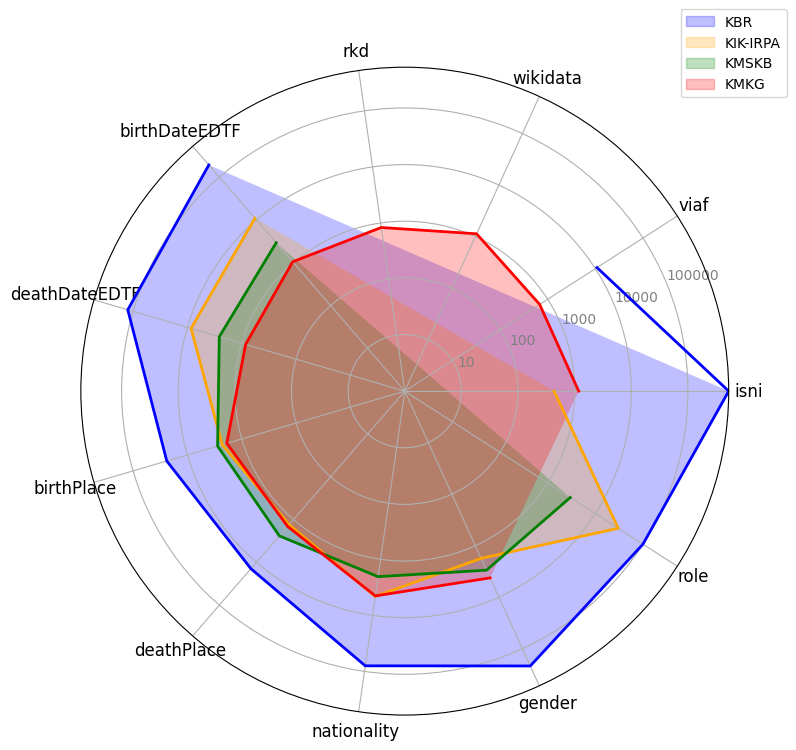

In [118]:
notebook_utils.plotRadarChart(statsDataframes, variables)

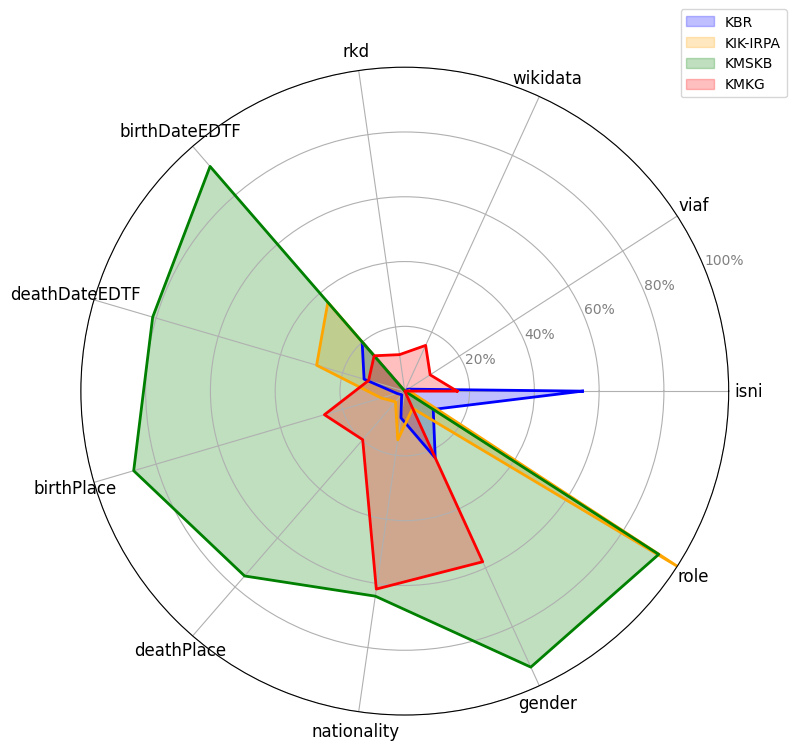

In [119]:
notebook_utils.plotRadarChartPercentage(statsDataframes, variables)

## Statistics and visualizations per datafield

We first look into birth and death dates and afterwards into birth and death places.
Based on the existing birth and death dates we performed manual curation to correct a few dates.
It is fine if they are counted above, because "there is a date", it's rather a correction.

Similarly, for birth and death places we counted above how often it is filled in, but in the curation phase
we further enriched it with GeoNames identifiers.

### Manual curations

Based on the first version of this notebook, the different partner institutions took generated CSV files and manually inspected them. If necessary, EDTF dates were corrected in the related CSV files, those CSV files are the input of this manual curation step.

We first update the main dataframe `statsDf`.

**birth/death dates**

In [120]:
statsDf.columns

Index(['isni', 'name', 'alternateNames', 'birthDate-original', 'birthDate',
       'deathDate-original', 'deathDate', 'birthPlace-original', 'birthPlace',
       'deathPlace-original', 'deathPlace', 'role-original', 'role',
       'nationality-original', 'nationality', 'gender-original', 'gender',
       'dataSource', 'pseudonyms', 'dates100d', 'viaf', 'nameComponents',
       'bnf', 'ulan', 'wikipedia', 'website', 'loc', 'rkd', 'wikidata',
       'birthDate_value', 'birthDate_rule', 'deathDate_value',
       'deathDate_rule', 'birthDate100dEDTF', 'birthDate100dType',
       'birthDate100dEDTFRule', 'deathDate100dEDTF', 'deathDate100dType',
       'deathDate100dEDTFRule', 'birthDateEDTF', 'deathDateEDTF'],
      dtype='object')

In [121]:
valueDataframes['deathDate'].keys()

Index(['deathDate', 'deathDate-original', 'rule', 'dataSource'], dtype='object')

In [122]:
# tuples are: target column name, curation input column, 1:n dataframe name in valueDataframes ditionary
dateCorrections = {
    'birthDates': ('birthDateEDTF', 'correctBirthDate', 'birthDate'), 
    'deathDates': ('deathDateEDTF', 'correctDeathDate', 'deathDate')
}

# loop over each data source
for dataSource, info in extractInfo.items():

    # loop over each curated field
    for curation, correctedCol in dateCorrections.items():
        targetCol = correctedCol[0]
        curationInputCol = correctedCol[1]
        scalarValuesDfName = correctedCol[2]
        
        curationFiles = info['curated'][curation]
        # make one data frame of potentially all files of the same type
        # e.g. for kmkg, birthPlace has several files, per type of issue that was fixed
        if curationFiles:
            curatedDf = pd.concat((pd.read_csv(f) for f in curationFiles))
            numberInputRows = curatedDf.shape[0]
           
            curatedDf = curatedDf[
                curatedDf[curationInputCol].notna() &
                (curatedDf[curationInputCol].astype(str).str.strip() != '')
            ]
            curatedDf = curatedDf.set_index('autID')
            print(f'{dataSource} - {curation}: read {numberInputRows} from which {curatedDf.shape[0]} rows contain corrections')

            # Update 1:n relationships
            update_series = curatedDf[curationInputCol]    
            # align values to df_values index
            mapped = valueDataframes[scalarValuesDfName].index.map(update_series)       
            # mask where we actually have curated values
            mask = mapped.notna()   
            # update main value column
            valueDataframes[scalarValuesDfName].loc[mask, scalarValuesDfName] = mapped[mask]
            # update rule column
            valueDataframes[scalarValuesDfName].loc[mask, 'rule'] = 'curated'
            

    

KMSKB - birthDates: read 2987 from which 41 rows contain corrections
KMSKB - deathDates: read 2647 from which 20 rows contain corrections
KMKG - birthDates: read 1056 from which 10 rows contain corrections
KMKG - deathDates: read 852 from which 22 rows contain corrections


In [123]:
valueDataframes['birthDate'][valueDataframes['birthDate'].index == 'kmskb|509/1333']

,birthDate,birthDate-original,rule,dataSource
autID,,,,
kmskb|509/1333,1627,1625 / 1627,curated,KMSKB


Since we also have seperate dataframes for each column to resolve possible 1:n relations, we also have to correct the dates there.
It is sufficient to correct the data in the `valueDataframes` dictionary. In later sections those dataframes will be used to further analyze specific fields, e.g. in the section of birth places, we will create a `birthPlaceDf` by saying `birthPlaceDf = valueDataframes['birthPlace']`

### Birth date stats

In [124]:
if useEnriched100d:
    # birth dates from df_enriched were already merged with the scalar values from 1:n relationship dataframes in valueDataframes
    birthDateDf = df_enriched100d.copy()
    birthDateDf.loc[birthDateDf['birthDate_rule'].isna(), 'birthDate_rule'] = birthDateDf.loc[birthDateDf['birthDate_rule'].isna(), 'birthDate100dEDTFRule'] 
    birthDateDf = birthDateDf[birthDateDf['birthDateEDTF'].notna()].rename(columns={'birthDate_rule': 'rule'})[['birthDateEDTF', 'birthDate-original', 'rule', 'dataSource']]
else:
    # take birth dates scalar values from 1:n relationship dataframes
    birthDateDf = valueDataframes['birthDate'].rename(columns={'birthDate': 'birthDateEDTF'})

In [125]:
groupedBirthDates = birthDateDf.groupby(['rule', 'dataSource']).size().reset_index(name='count').sort_values(by=['count'], ascending=False)

In [126]:
pivotBirthDates = groupedBirthDates.pivot(index='rule', columns='dataSource', values='count').fillna(0).astype(int)

In [127]:
pivotBirthDates

dataSource,KBR,KIK-IRPA,KMKG,KMSKB
rule,,,,
after_year,10,0,0,0
before_dash_date,0,0,2,0
before_year,19,0,7,0
between_years,0,0,2,0
century,11356,0,0,0
circa_year,16705,0,99,178
flourish_century,24,0,0,0
flourish_year,9712,0,0,0
one_of_two_years_dash,3,0,4,17


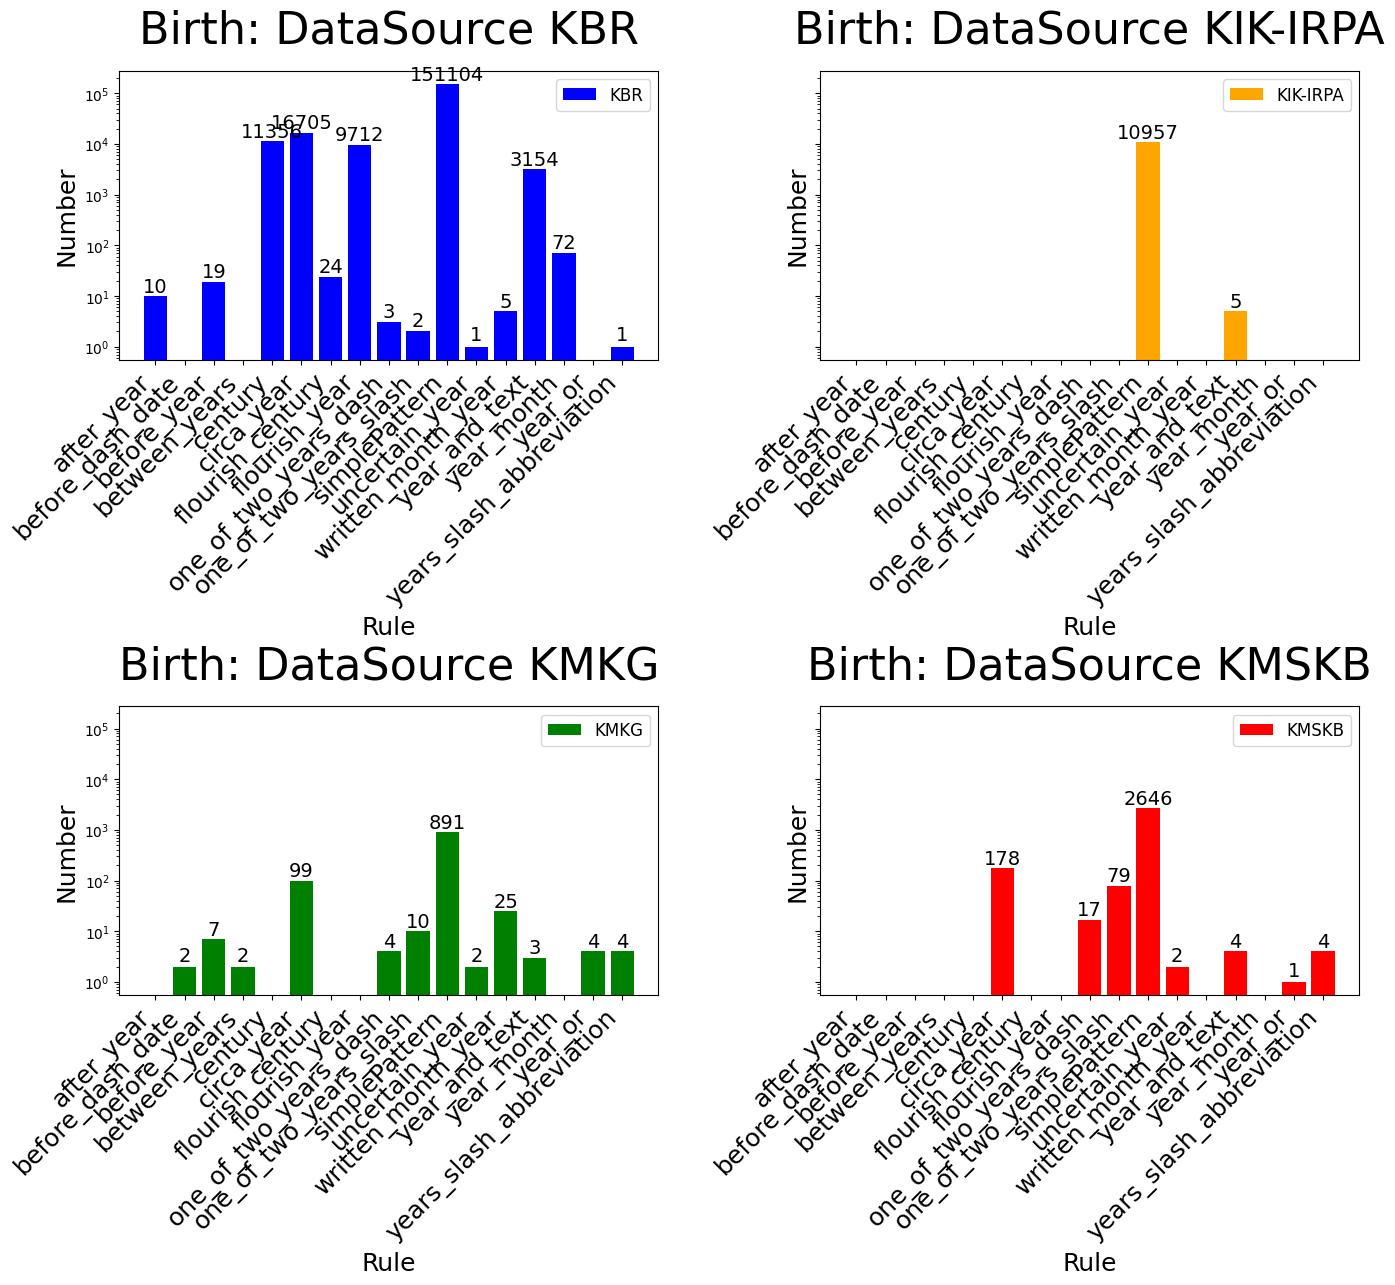

In [128]:
notebook_utils.plotDatePatternsPercentages(pivotBirthDates, 
                                           'Birth',
                                           is_percentage=False,
                                           save_path_pdf='birthDate-rules_plot.pdf', 
                                           save_path_png='birthDate-rules_plot.png')

In [129]:
birthDateDf

,birthDateEDTF,birthDate-original,rule,dataSource
autID,,,,
kbr|10038111,1883,,simplePattern,KBR
kbr|10038121,1885,,simplePattern,KBR
kbr|10038133,1897,,simplePattern,KBR
kbr|10038139,1844,,simplePattern,KBR
kbr|10038142,1850,,simplePattern,KBR
...,...,...,...,...
kmskb|509/95,1859,,simplePattern,KMSKB
kmskb|509/96,1873,,simplePattern,KMSKB
kmskb|509/97,1883,,simplePattern,KMSKB


In [130]:
birthDateDf['certainBirthDate'] = birthDateDf['birthDateEDTF'].apply(notebook_utils.isCertainEDTFDate)
birthDateDf['birthDatePrecision'] = birthDateDf['birthDateEDTF'].apply(notebook_utils.getDatePrecision)

In [131]:
birthDateDf['birthDatePrecision'].shape[0]

207114

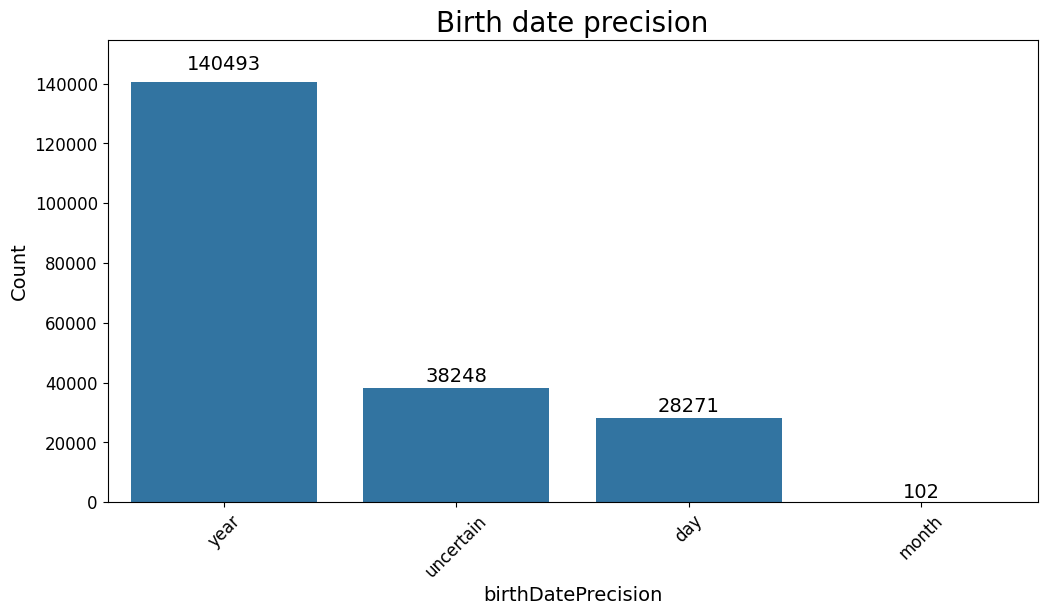

In [132]:
notebook_utils.plotBarChart(birthDateDf, 
                            x_column='birthDatePrecision',
                            title='Birth date precision',
                           save_path_pdf='birth-date-precision.pdf',
                           save_path_png='birth-date-precision.png')

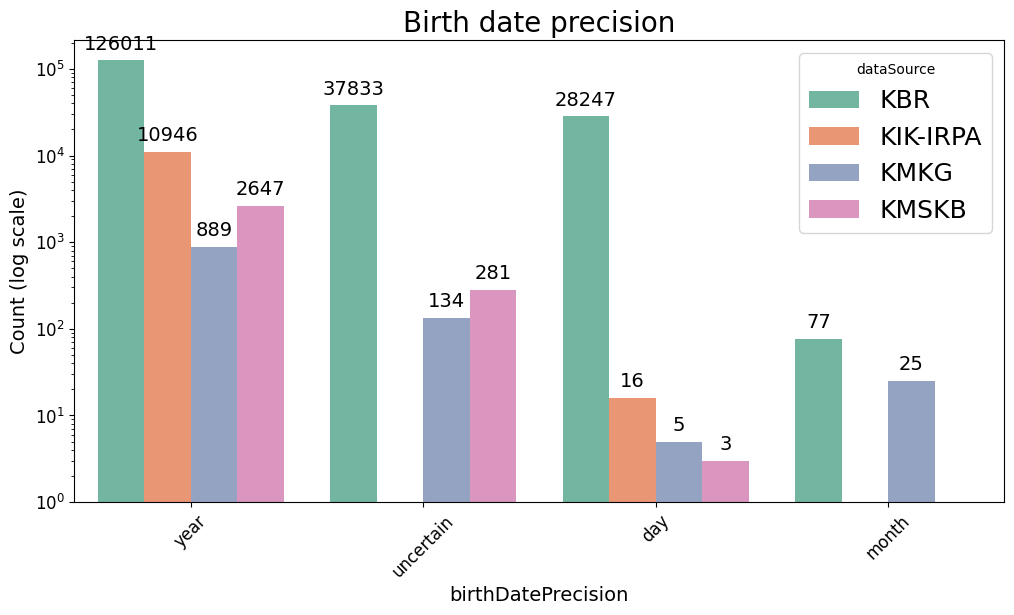

In [133]:
notebook_utils.plotBarChart(birthDateDf, 
                            x_column='birthDatePrecision',
                            group_column='dataSource',
                            title='Birth date precision',
                            log_scale=True,
                           save_path_pdf='birth-date-precision-per-data-source.pdf',
                           save_path_png='birth-date-precision-per-data-source.png')

In [134]:
birthDateDf[['birthDatePrecision', 'dataSource']]

,birthDatePrecision,dataSource
autID,,
kbr|10038111,year,KBR
kbr|10038121,year,KBR
kbr|10038133,year,KBR
kbr|10038139,year,KBR
kbr|10038142,year,KBR
...,...,...
kmskb|509/95,year,KMSKB
kmskb|509/96,year,KMSKB
kmskb|509/97,year,KMSKB


In [135]:
# Normalize the data by dataSource to get percentages
#percentage_data_birth = pivotBirthDates.div(pivotBirthDates.sum(axis=0), axis=1) * 100

In [136]:
#percentage_data_birth

In [137]:
#notebook_utils.plotDatePatternsPercentages(percentage_data_birth, 
#                                           'Birth',
#                                           is_percentage=True,
#                                           save_path_pdf='birthDate-rules_percentage_plot.pdf', 
#                                           save_path_png='birthDate-rules_percentage_plot.png')

In [138]:
# Extract the decade from birthDate
def extract_decade(date):
    if isinstance(date, str) and date[:4].isdigit():
        year = int(date[:4])
        return (year // 10) * 10  # Calculate decade
    else:
        return np.nan  # Handle non-numeric cases

birthDateDf['decade'] = birthDateDf['birthDateEDTF'].apply(extract_decade)

# Group data by dataSource and decade
decade_counts_birth = (birthDateDf.groupby(['dataSource', 'decade'])
                 .size()
                 .reset_index(name='count'))

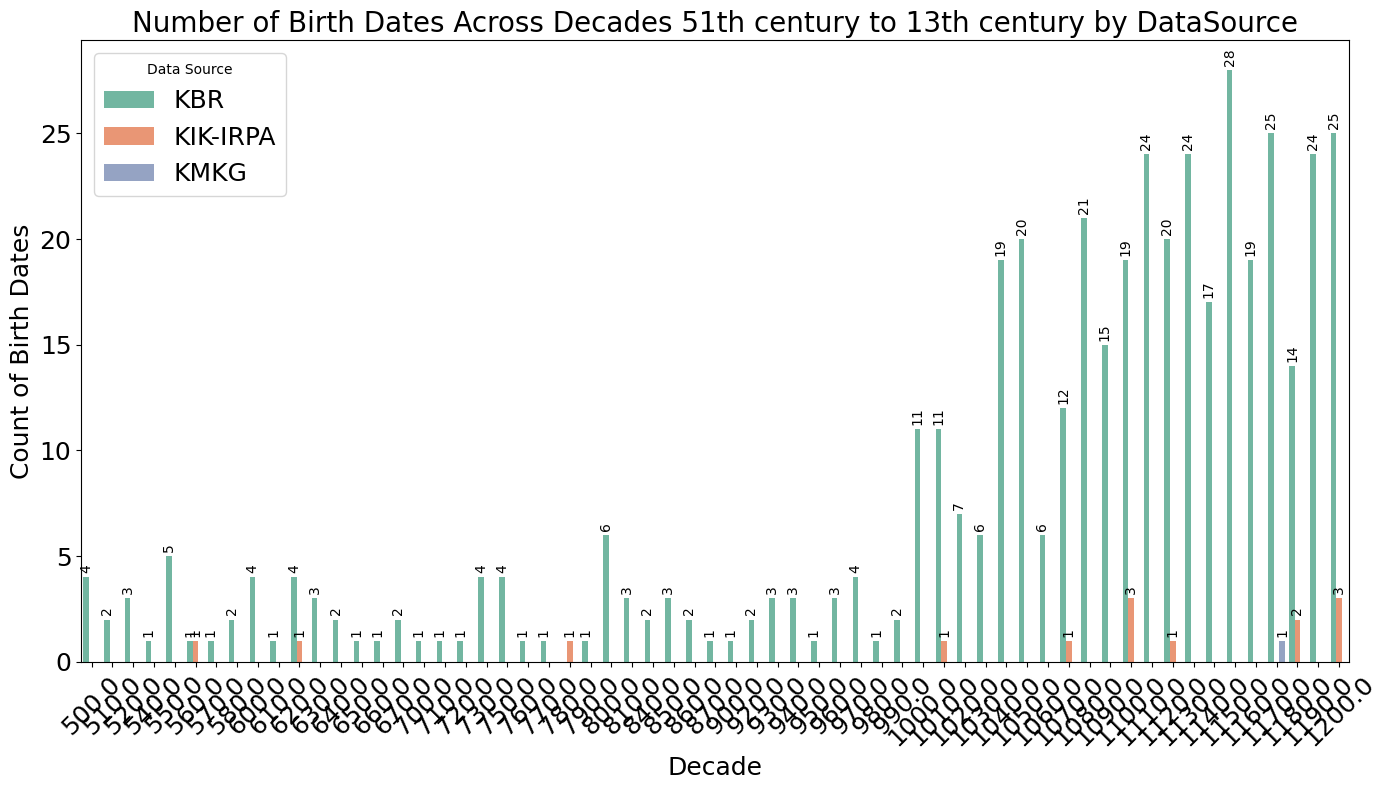

In [139]:
notebook_utils.plotDecade(decade_counts_birth, 'Birth', min_decade=500, max_decade=1200)

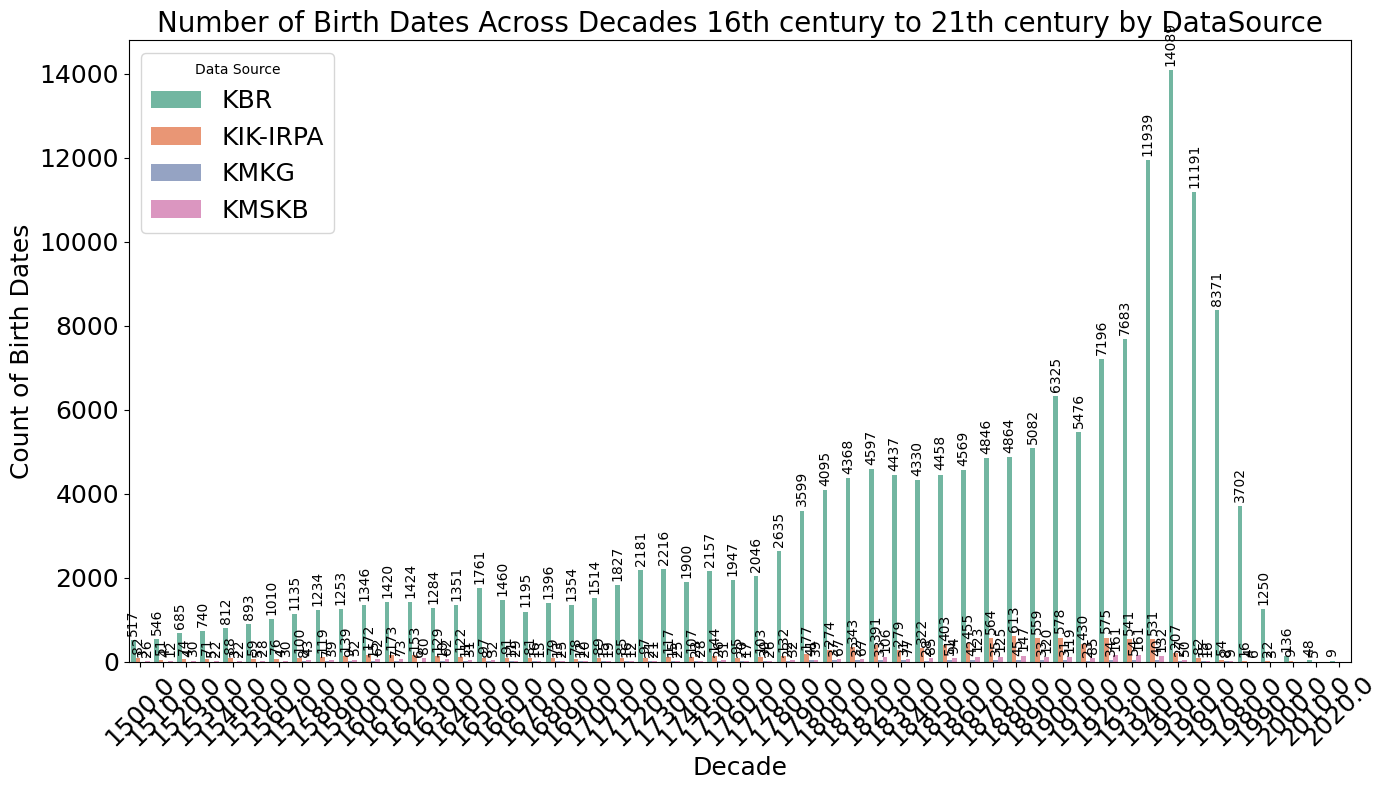

In [140]:
notebook_utils.plotDecade(decade_counts_birth, 'Birth', min_decade=1500, max_decade=2020)

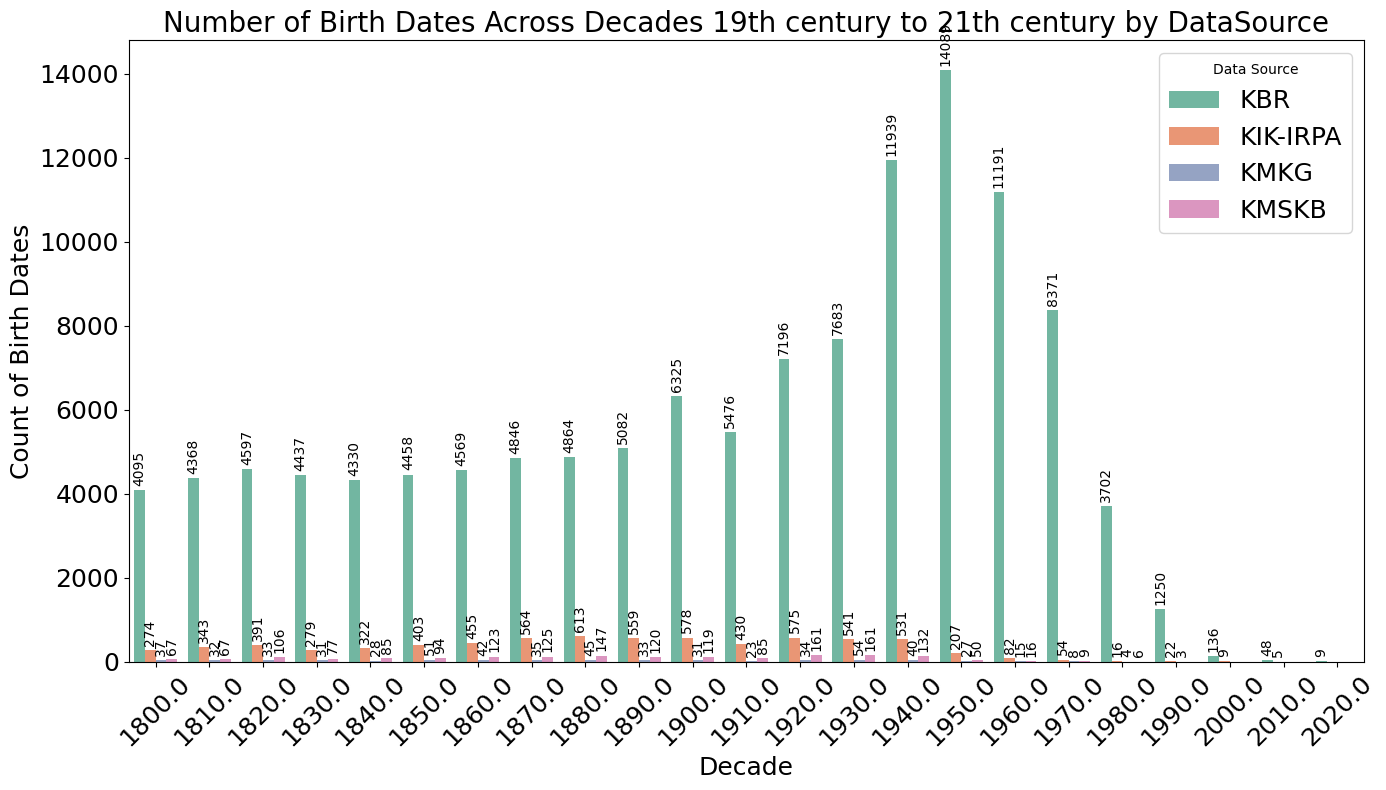

In [141]:
notebook_utils.plotDecade(decade_counts_birth, 'Birth', min_decade=1800, max_decade=2020)

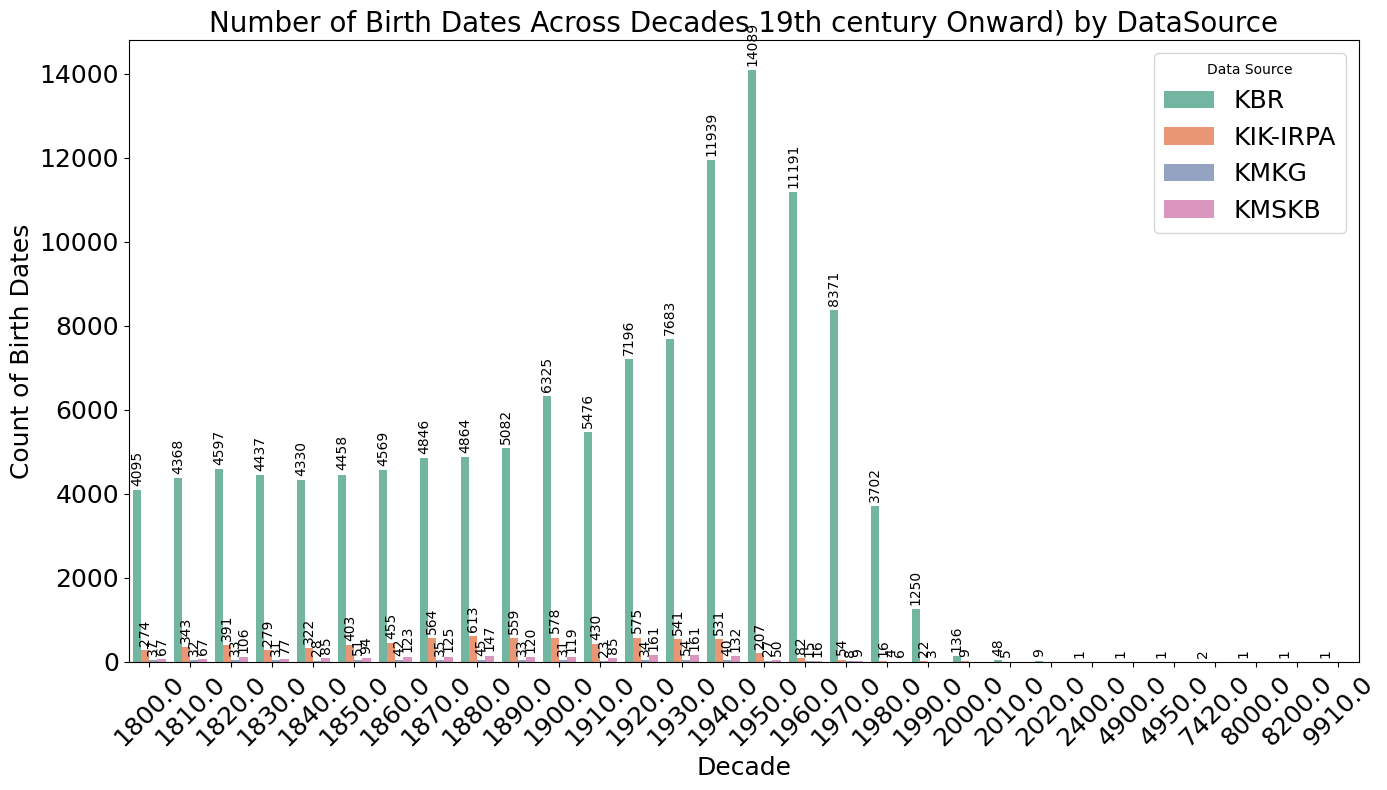

In [142]:
notebook_utils.plotDecade(decade_counts_birth, 'Birth', 1800)

### Death date stats

In [143]:
if useEnriched100d:
    # death dates from df_enriched were already merged with the scalar values from 1:n relationship dataframes in valueDataframes
    deathDateDf = df_enriched100d.copy()
    deathDateDf.loc[deathDateDf['deathDate_rule'].isna(), 'deathDate_rule'] = deathDateDf.loc[deathDateDf['deathDate_rule'].isna(), 'deathDate100dEDTFRule'] 
    deathDateDf = deathDateDf[deathDateDf['deathDateEDTF'].notna()].rename(columns={'deathDate_rule': 'rule'})[['deathDateEDTF', 'deathDate-original', 'rule', 'dataSource']]

else:
    # take death dates scalar values from 1:n relationship dataframes
    deathDateDf = valueDataframes['deathDate'].rename(columns={'deathDate': 'deathDateEDTF'})

In [144]:
groupedDeathDates = deathDateDf.groupby(['rule', 'dataSource']).size().reset_index(name='count').sort_values(by=['count'], ascending=False)

In [145]:
pivotDeathDates = groupedDeathDates.pivot(index='rule', columns='dataSource', values='count').fillna(0).astype(int)

In [146]:
pivotDeathDates

dataSource,KBR,KIK-IRPA,KMKG,KMSKB
rule,,,,
after_written_month_year,0,0,1,0
after_year,86,0,47,1
before_year,22,0,4,0
between_years,0,0,6,0
century,3361,0,1,0
circa_year,585,0,39,94
flourish_century,35,0,0,0
flourish_year,7144,0,0,0
one_of_two_years_dash,144,0,2,6


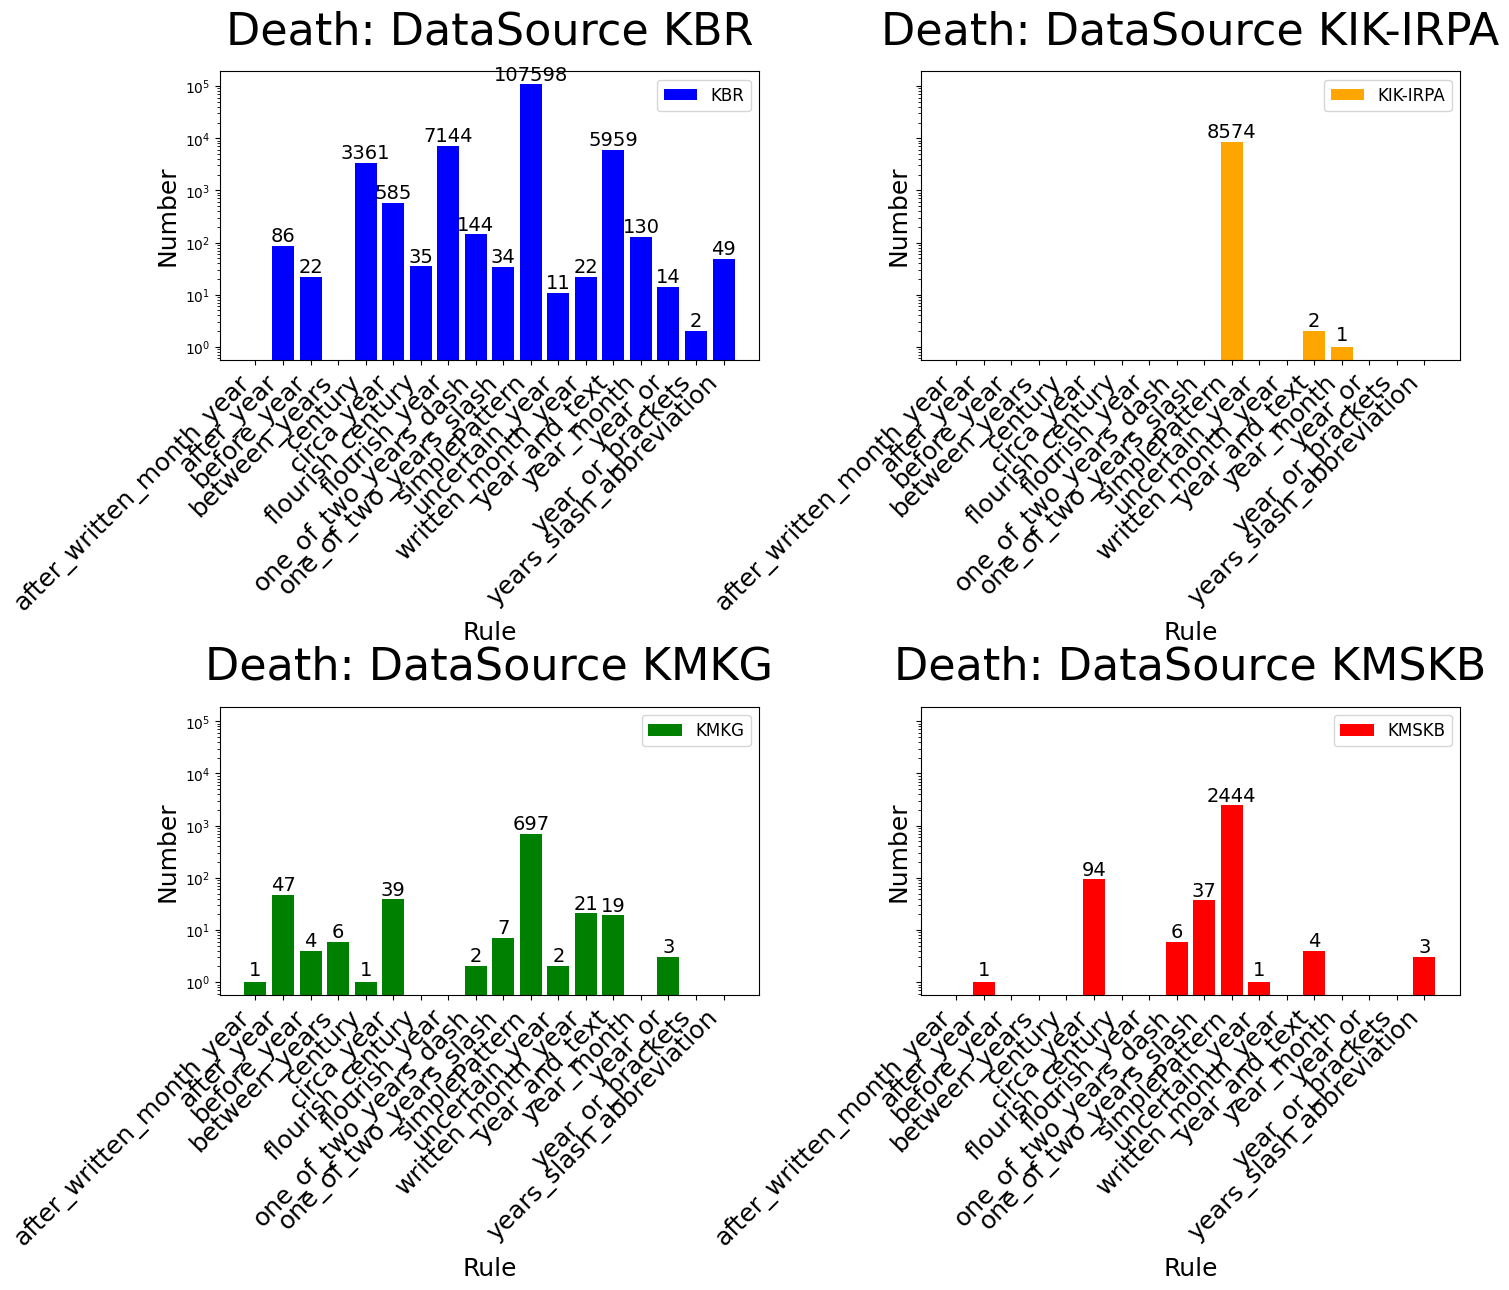

In [147]:
notebook_utils.plotDatePatternsPercentages(pivotDeathDates, 
                                           'Death',
                                           is_percentage=False,
                                           save_path_pdf='deathDate-rules_plot.pdf', 
                                           save_path_png='deathDate-rules_plot.png')

In [148]:
deathDateDf['certainDeathDate'] = deathDateDf['deathDateEDTF'].apply(notebook_utils.isCertainEDTFDate)
deathDateDf['deathDatePrecision'] = deathDateDf['deathDateEDTF'].apply(notebook_utils.getDatePrecision)

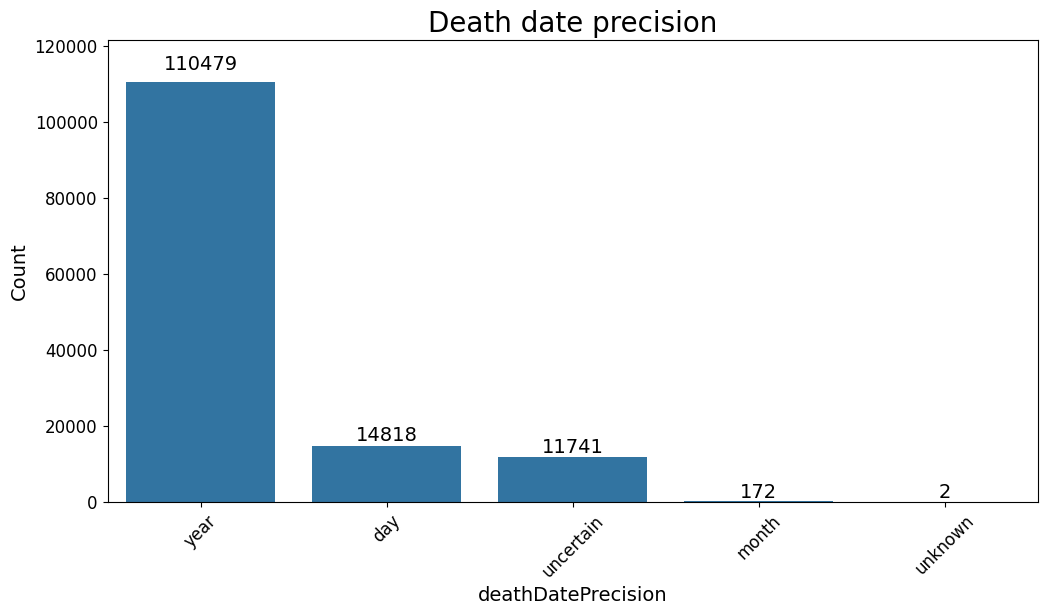

In [149]:
notebook_utils.plotBarChart(deathDateDf, 
                            x_column='deathDatePrecision',
                            title='Death date precision',
                           save_path_pdf='death-date-precision.pdf',
                           save_path_png='death-date-precision.png')

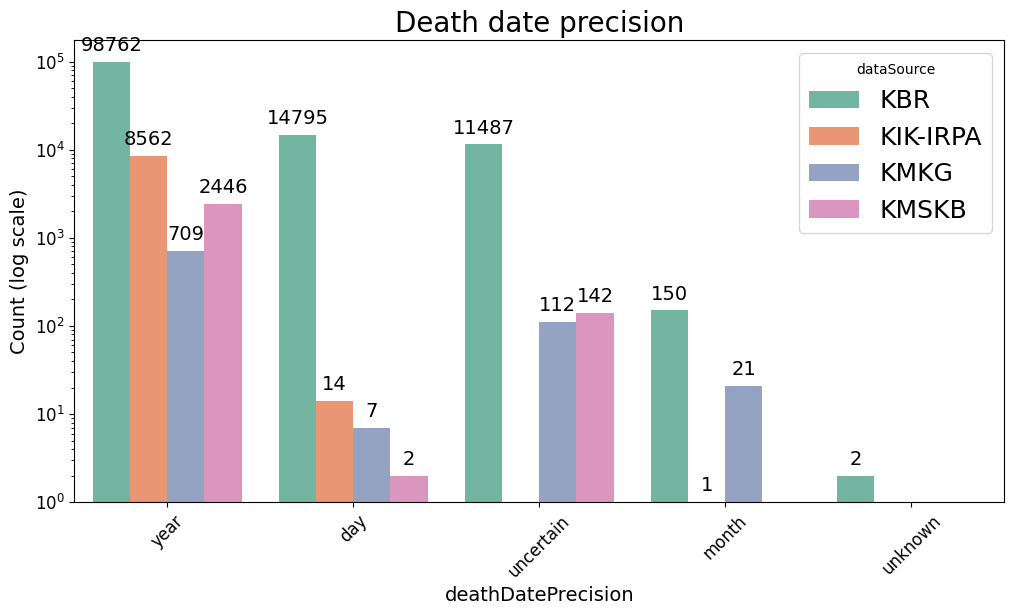

In [150]:
notebook_utils.plotBarChart(deathDateDf, 
                            x_column='deathDatePrecision',
                            group_column='dataSource',
                            title='Death date precision',
                            log_scale=True,
                           save_path_pdf='death-date-precision-per-data-source.pdf',
                           save_path_png='death-date-precision-per-data-source.png')

In [151]:
# Normalize the data by dataSource to get percentages
#percentage_data_death = pivotDeathDates.div(pivotDeathDates.sum(axis=0), axis=1) * 100

In [152]:
#notebook_utils.plotDatePatternsPercentages(percentage_data_death, 
#                                           'Death',
#                                           is_percentage=True,
#                                           save_path_pdf='deathDate-rules_percentage_plot.pdf', 
#                                           save_path_png='deathDate-rules_percentage_plot.png')

In [153]:
deathDateDf['decade'] = deathDateDf['deathDateEDTF'].apply(extract_decade)

# Group data by dataSource and decade
decade_counts_death = (deathDateDf.groupby(['dataSource', 'decade'])
                 .size()
                 .reset_index(name='count'))

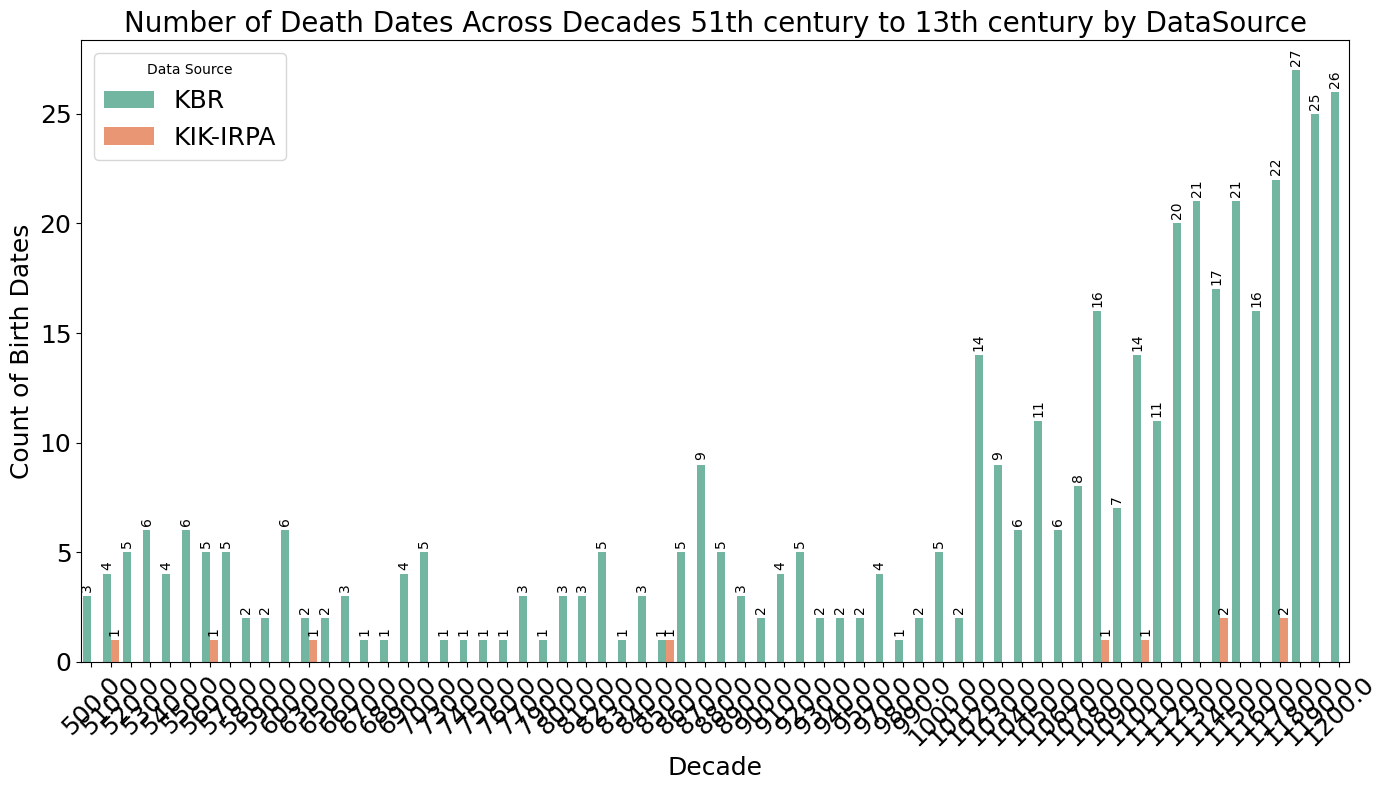

In [154]:
notebook_utils.plotDecade(decade_counts_death, 'Death', min_decade=500, max_decade=1200)

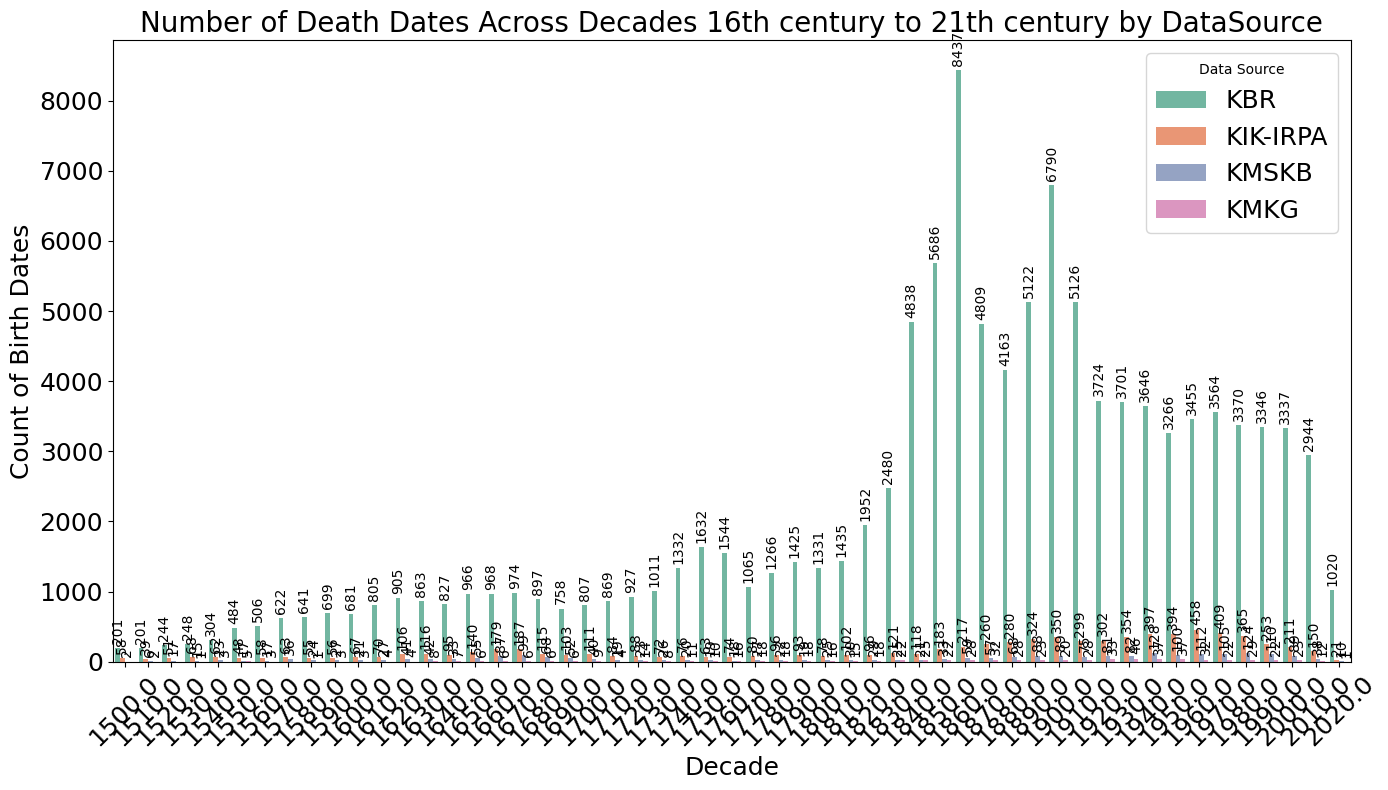

In [155]:
notebook_utils.plotDecade(decade_counts_death, 'Death', min_decade=1500, max_decade=2020)

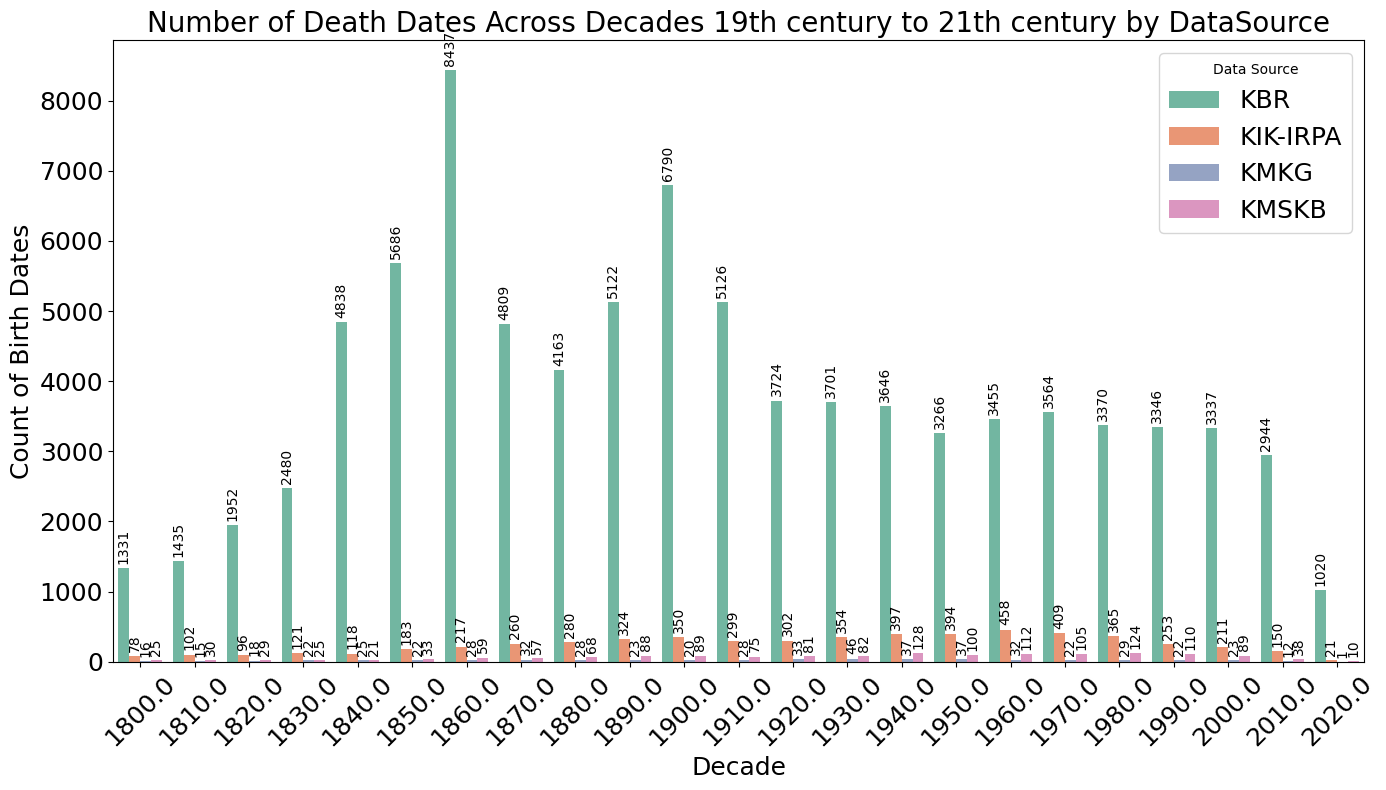

In [156]:
notebook_utils.plotDecade(decade_counts_death, 'Death', min_decade=1800, max_decade=2020)

### Date parsing stats

In [157]:
dateParsingFrames = []
for dataSource, info in extractInfo.items():
    logFileName = os.path.join(os.path.dirname(info['outputFilename']), f'{info["prefix"]}.log')
    if os.path.getsize(logFileName) > 0:
        print(f'processing {logFileName}')
        currentDf = pd.read_csv(logFileName, keep_default_na=False)
        # explicitly indicate the data source in a separate column
        currentDf['dataSource'] = dataSource

        dateParsingFrames.append(currentDf)
    else:
        print(f'empty logfile {logFileName}')
dateParsingDf = pd.concat(dateParsingFrames)

processing kik-irpa/kik-irpa-data-2026.log
processing kbr/kbr-data-2026.log
processing kmskb/kmskb-data.log
processing kmkg/kmkg-data.log


In [158]:
dateParsingDf

,time,level,name,message_type,identifier,message,dataSource
0,2026-03-20 10:43:14.149,WARNING,XML_TO_CSV.utils,invalid_value,14433438,"14433438: placeholder value ""--"" found instead...",KBR
1,2026-03-20 10:43:14.510,WARNING,XML_TO_CSV.utils,invalid_value,14504131,"14504131: placeholder value ""--"" found instead...",KBR
2,2026-03-20 10:43:14.566,WARNING,XML_TO_CSV.utils,invalid_value,14631441,"14631441: placeholder value ""--"" found instead...",KBR
3,2026-03-20 10:43:14.566,WARNING,XML_TO_CSV.utils,invalid_value,14631441,"14631441: placeholder value ""--"" found instead...",KBR
4,2026-03-20 10:43:14.621,WARNING,XML_TO_CSV.utils,invalid_value,21935270,"21935270: placeholder value ""--"" found instead...",KBR
...,...,...,...,...,...,...,...
6,2026-02-13 11:27:54.842,ERROR,XML_TO_CSV.utils,invalid_value,3688,3688: no match with parseDate or parseComplexD...,KMKG
7,2026-02-13 11:27:54.902,ERROR,XML_TO_CSV.utils,invalid_value,522480,522480: no match with parseDate or parseComple...,KMKG
8,2026-02-13 11:27:55.128,ERROR,XML_TO_CSV.utils,invalid_value,643,643: no match with parseDate or parseComplexDa...,KMKG
9,2026-02-13 11:27:55.366,ERROR,XML_TO_CSV.utils,invalid_value,299441,299441: no match with parseDate or parseComple...,KMKG


In [159]:
dateParsingDf['message_type'].value_counts()

message_type
script_configuration_error    6572
invalid_value                 6439
Name: count, dtype: int64

In [160]:
dateParsingDf[dateParsingDf['message_type'] == 'script_configuration_error']

,time,level,name,message_type,identifier,message,dataSource
0,2025-10-03 16:24:06.248,WARNING,XML_TO_CSV.utils,script_configuration_error,,multiple values for subfield lastName in recor...,KMSKB
1,2025-10-03 16:24:06.248,WARNING,XML_TO_CSV.utils,script_configuration_error,,multiple values for subfield firstName in reco...,KMSKB
2,2025-10-03 16:24:06.250,WARNING,XML_TO_CSV.utils,script_configuration_error,,multiple values for subfield lastName in recor...,KMSKB
3,2025-10-03 16:24:06.250,WARNING,XML_TO_CSV.utils,script_configuration_error,,multiple values for subfield firstName in reco...,KMSKB
4,2025-10-03 16:24:06.250,WARNING,XML_TO_CSV.utils,script_configuration_error,,multiple values for subfield lastName in recor...,KMSKB
...,...,...,...,...,...,...,...
6570,2025-10-03 16:24:07.198,WARNING,XML_TO_CSV.utils,script_configuration_error,,multiple values for subfield lastName in recor...,KMSKB
6571,2025-10-03 16:24:07.198,WARNING,XML_TO_CSV.utils,script_configuration_error,,multiple values for subfield lastName in recor...,KMSKB
6572,2025-10-03 16:24:07.198,WARNING,XML_TO_CSV.utils,script_configuration_error,,multiple values for subfield lastName in recor...,KMSKB
6573,2025-10-03 16:24:07.198,WARNING,XML_TO_CSV.utils,script_configuration_error,,multiple values for subfield lastName in recor...,KMSKB


### Stats for enriching of geo information

In [161]:
# todo: execute geoname enrichment, I already have bash scripts for this, 
# because of time pressure I don't need to add this now, 
# I can continue with the analysis of the already created files
if enrichGeoAgain:
    pass

In [162]:
placeEnrichmentLogs = []
for dataSource, info in extractInfo.items():

        enrichLogfileNameBirth = os.path.join(os.path.dirname(info['outputFilename']), f'{info["prefix"]}-birthPlace-enriched.log')
        enrichLogfileNameDeath = os.path.join(os.path.dirname(info['outputFilename']), f'{info["prefix"]}-deathPlace-enriched.log')
        birthPlaceLogDf = pd.read_csv(enrichLogfileNameBirth)
        deathPlaceLogDf = pd.read_csv(enrichLogfileNameDeath)
        
        birthPlaceLogDf['dataSource'] = dataSource
        deathPlaceLogDf['dataSource'] = dataSource
        birthPlaceLogDf['variableType'] = 'birthPlace'
        deathPlaceLogDf['variableType'] = 'deathPlace'
        placeEnrichmentLogs.extend([birthPlaceLogDf, deathPlaceLogDf])
        
placeLogDf = pd.concat(placeEnrichmentLogs)

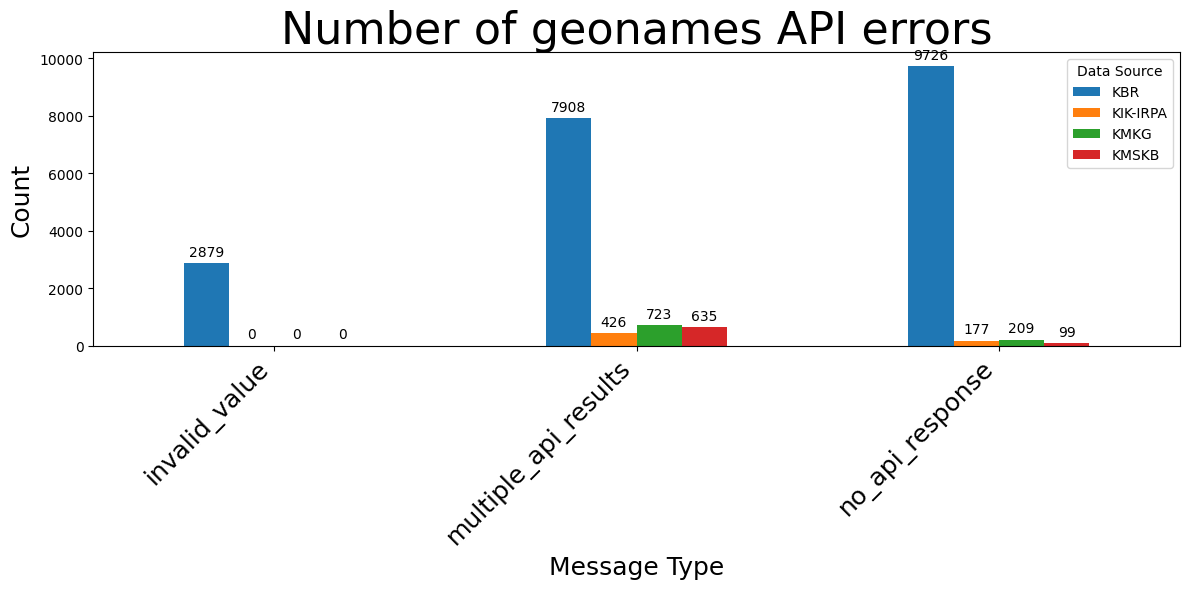

In [163]:
grouped_df = placeLogDf.groupby(['message_type', 'dataSource']).size().to_frame('size').reset_index()

# Pivot the DataFrame: rows = message_type, columns = dataSource, values = size
pivot_df = grouped_df.pivot(index='message_type', columns='dataSource', values='size')

# Plot a grouped bar chart
ax = pivot_df.plot(kind='bar', figsize=(12,6))

# Set labels and title
ax.set_xlabel("Message Type", fontsize=18)
ax.set_ylabel("Count", fontsize=18)
ax.set_title("Number of geonames API errors", fontsize=32)
plt.legend(title="Data Source")

# Annotate bars with their values
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type="edge", padding=3, fontsize=10)

plt.xticks(rotation=45, fontsize=18, ha='right')
plt.margins(x=0.02) 
plt.tight_layout()
plt.savefig('geonames-enrichment-errors.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.savefig('geonames-enrichment-errors.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

In [164]:
placeLogDf[placeLogDf['message_type'] == 'invalid_value']

,time,level,name,message_type,identifier,message,dataSource,variableType
156,2026-03-23 14:26:34.557,WARNING,GEONAME_ENRICHMENT,invalid_value,kbr|14765309,"Invalid placename (kbr|14765309): ""--""",KBR,birthPlace
161,2026-03-23 14:26:36.994,WARNING,GEONAME_ENRICHMENT,invalid_value,kbr|21439583,"Invalid placename (kbr|21439583): ""--""",KBR,birthPlace
315,2026-03-23 14:28:23.076,WARNING,GEONAME_ENRICHMENT,invalid_value,kbr|21987932,"Invalid placename (kbr|21987932): ""--""",KBR,birthPlace
328,2026-03-23 14:28:38.949,WARNING,GEONAME_ENRICHMENT,invalid_value,kbr|21932513,"Invalid placename (kbr|21932513): ""--""",KBR,birthPlace
334,2026-03-23 14:28:39.753,WARNING,GEONAME_ENRICHMENT,invalid_value,kbr|21926421,"Invalid placename (kbr|21926421): ""--""",KBR,birthPlace
...,...,...,...,...,...,...,...,...
7906,2026-03-24 13:06:17.601,WARNING,GEONAME_ENRICHMENT,invalid_value,kbr|22159941,"Invalid placename (kbr|22159941): ""--""",KBR,deathPlace
7915,2026-03-24 13:06:21.228,WARNING,GEONAME_ENRICHMENT,invalid_value,kbr|22163732,"Invalid placename (kbr|22163732): ""--""",KBR,deathPlace
7931,2026-03-24 13:06:32.140,WARNING,GEONAME_ENRICHMENT,invalid_value,kbr|22174446,"Invalid placename (kbr|22174446): ""--""",KBR,deathPlace
7973,2026-03-24 13:06:55.784,WARNING,GEONAME_ENRICHMENT,invalid_value,kbr|22195521,"Invalid placename (kbr|22195521): ""--""",KBR,deathPlace


In [165]:
placeLogDf['multiple_result_list'] = None

placeLogDf['multiple_result_list'] = placeLogDf.apply(
    lambda row: row['message'].split(':', 1)[1].strip() if row['message_type'] == 'multiple_api_results' else None,
    axis=1
)

#placeLogDf.loc[placeLogDf['message_type'] == 'multiple_api_results', 'multiple_result_list'] = (
#  placeLogDf.loc[placeLogDf['message_type'] == 'multiple_api_results', 'multiple_result_list']
#    .str.split(':')
#    .str[1]
#    .str.strip()
#)


In [166]:
multiplePlaceStatsDf = placeLogDf[placeLogDf['message_type'] == 'multiple_api_results'][['multiple_result_list']].groupby(['multiple_result_list']).size().reset_index(name='count').set_index('multiple_result_list').sort_values(by=['count'], ascending=False)

In [167]:
multiplePlaceStatsDf

,count
multiple_result_list,
"chosen ""Paris (FR,2988507)"" from Les Paris (FR, 3000074, population: 0), Paris (FR, 2988507, population: 2138551) based on mapping 2988507",2924
"chosen ""London (GB,2643743)"" from London (GB, 2643743, population: 8961989), City of London (GB, 2643741, population: 8072) based on mapping 2643743",633
"Mechelen-Bovelingen (BE, 2791532, population: 1537), Mechelen-aan-de-Maas (BE, 2791534, population: 15374), Mechelen (BE, 2791537, population: 77530)",267
"Schaerbeek (BE, 2787149, population: 132761), Schaarbeek (BE, 2787154, population: 0)",151
"Marseille-en-Beauvaisis (FR, 2995463, population: 990), Marseille (FR, 2995469, population: 870731)",147
...,...
"Ehingen am Ries (DE, 2932919, population: 0), Ehingen (DE, 2932924, population: 27276)",1
"Ebersberg (DE, 2933939, population: 0), Ebersberg (DE, 2933943, population: 0), Ebersberg (DE, 2933945, population: 11041)",1
"Monsenhor Gil (BR, 3394621, population: 4751), Tupandi (BR, 3445938, population: 0), Potiraguá (BR, 3452548, population: 0), Guamiranga (BR, 3461981, population: 0), Natal (BR, 3394023, population: 896708), Natal (BR, 3456385, population: 0), Natal (BR, 3456386, population: 0), Natal (BR, 8604016, population: 0), Natal (BR, 3663192, population: 0), Natal (BR, 13006187, population: 0)",1


In [168]:
multiplePlaceStatsDf[multiplePlaceStatsDf['count'] > 20]

,count
multiple_result_list,
"chosen ""Paris (FR,2988507)"" from Les Paris (FR, 3000074, population: 0), Paris (FR, 2988507, population: 2138551) based on mapping 2988507",2924
"chosen ""London (GB,2643743)"" from London (GB, 2643743, population: 8961989), City of London (GB, 2643741, population: 8072) based on mapping 2643743",633
"Mechelen-Bovelingen (BE, 2791532, population: 1537), Mechelen-aan-de-Maas (BE, 2791534, population: 15374), Mechelen (BE, 2791537, population: 77530)",267
"Schaerbeek (BE, 2787149, population: 132761), Schaarbeek (BE, 2787154, population: 0)",151
"Marseille-en-Beauvaisis (FR, 2995463, population: 990), Marseille (FR, 2995469, population: 870731)",147
"Berlin (DE, 2950158, population: 0), Berlin (DE, 2950159, population: 3426354)",128
"'t Hasselt (BE, 2785598, population: 0), Hasselt (BE, 2796491, population: 77651)",106
"Bordeaux-en-Gâtinais (FR, 3031579, population: 128), Bordeaux (FR, 3031582, population: 260958), Bordeaux (FR, 12311242, population: 0)",100
"Aalst (BE, 2803450, population: 0), Aalst (BE, 2803448, population: 77534), Aalst (BE, 2803449, population: 747)",99


<Axes: xlabel='multiple_result_list'>

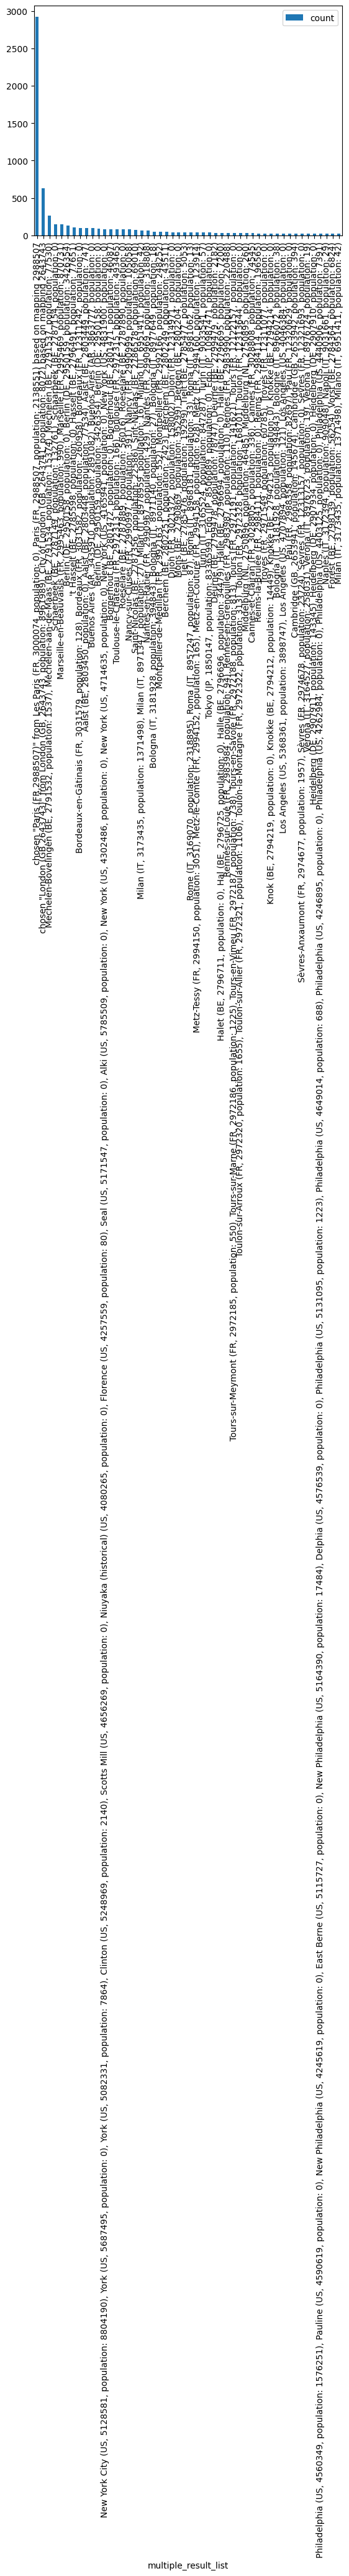

In [169]:
multiplePlaceStatsDf[multiplePlaceStatsDf['count'] > 20].plot(kind='bar')

In [170]:
multiplePlaceStatsDf.to_csv('multiple-api-results-occurrences-list.csv')
multiplePlaceStatsDf[multiplePlaceStatsDf.index.str.contains('BE,')].to_csv('multiple-api-results-occurrences-list-belgium.csv')

In [171]:
groupedBirthPlacesLogs = placeLogDf[placeLogDf['variableType'] == 'birthPlace'].groupby(['message_type', 'dataSource']).size().reset_index(name='count').sort_values(by=['count'], ascending=False)
groupedBirthPlacesLogs

,message_type,dataSource,count
5,no_api_response,KBR,6616
1,multiple_api_results,KBR,4661
0,invalid_value,KBR,1021
3,multiple_api_results,KMKG,394
4,multiple_api_results,KMSKB,384
2,multiple_api_results,KIK-IRPA,340
7,no_api_response,KMKG,127
6,no_api_response,KIK-IRPA,118
8,no_api_response,KMSKB,65


In [172]:
groupedDeathPlaces = placeLogDf[placeLogDf['variableType'] == 'deathPlace'].groupby(['message_type', 'dataSource']).size().reset_index(name='count').sort_values(by=['count'], ascending=False)
groupedDeathPlaces

,message_type,dataSource,count
1,multiple_api_results,KBR,3247
5,no_api_response,KBR,3110
0,invalid_value,KBR,1858
3,multiple_api_results,KMKG,329
4,multiple_api_results,KMSKB,251
2,multiple_api_results,KIK-IRPA,86
7,no_api_response,KMKG,82
6,no_api_response,KIK-IRPA,59
8,no_api_response,KMSKB,34


### Manual curation Geo
The last section has shown statistics regarding the geo enrichment step, such as certain API errors.
Based on the error logs, data managers at the different partner institutions fixed it as much as possible.

This was a long hanging fruit, because instead of finding information about in which place someone was born, we started from already existing info that had to be improved in order to be standardized. Missing country information or spelling mistakes are possible mistakes that required manual curation.

In [173]:
# first read the data that could be enriched automatically
placeEnrichmentDfs = []
#birthPlacesDfs = []
for dataSource, info in extractInfo.items():
    birthPlaceDf = pd.read_csv(info['geo-enriched-birth-place'])
    deathPlaceDf = pd.read_csv(info['geo-enriched-death-place'])
    
    birthPlaceDf['dataSource'] = dataSource
    deathPlaceDf['dataSource'] = dataSource
    birthPlaceDf['variableType'] = 'birthPlace'
    deathPlaceDf['variableType'] = 'deathPlace'
    placeEnrichmentDfs.extend([birthPlaceDf, deathPlaceDf])
#    birthPlacesDfs.append(birthPlaceDf)


In [174]:
placeDf = pd.concat(placeEnrichmentDfs)
placeDf['autID'] = placeDf['autID'].astype(str)

In [175]:
# apply datasource index prefix, but only if needed
prefixMask = ~placeDf['autID'].str.contains(r'|', na=False)
placeDf.loc[prefixMask, 'autID'] = (
    placeDf.loc[prefixMask, 'dataSource'].str.lower() + '|' + placeDf.loc[prefixMask, 'autID']
)

In [176]:
placeDf = placeDf.set_index('autID')

In [177]:
placeDfCountDfBeforeEnrichment = placeDf[['variableType', 'dataSource']].value_counts().reset_index()

In [178]:
# read and add manually enriched records
# it only has to be merged to birthPlaceDf/deathPlaceDf, not to statsDf (because other standardized GeoNames data are also not part of statsDf, 
#there will be a merge later on to merge the standardized data into the main datafragem
placeCorrections = {
    'birthPlacesEnriched': ('geonameIDBirth', 'correctIDs', 'relationshipTypeBirth', 'birthplaceComment', 'birthPlace'),
    'deathPlacesEnriched': ('geonameIDDeath', 'correctIDs', 'relationshipTypeDeath', 'deathplaceComment', 'deathPlace')
}


# add columns for relationshipType and comment
placeDf['relationshipType'] = np.nan
placeDf['placeComment'] = np.nan

# loop over each data source
for dataSource, info in extractInfo.items():

    # loop over each curated field
    for curation, correctedCol in placeCorrections.items():
        targetColPlace = correctedCol[0]
        curationInputCol = correctedCol[1]
        relationshipTypeCol = correctedCol[2]
        commentCol = correctedCol[3]
        variableType = correctedCol[4]
        curationFiles = info['curated'][curation]
        # make one data frame of potentially all files of the same type
        # e.g. for kmkg, birthPlace has several files, per type of issue that was fixed
        if curationFiles:
            curatedDf = pd.concat((pd.read_csv(f, dtype={curationInputCol: 'string'}) for f in curationFiles))
            print(f'{dataSource} - {curation}: read {curatedDf.shape[0]} rows from curation list')
            # replace value in finalEnrichedDf based on matching ID
            #finalEnrichedDf[correctedCol[0]].update(curatedDf[correctedCol[1]])
            curatedDf[curationInputCol] = curatedDf[curationInputCol].astype('string')
            if dataSource == "KIK-IRPA":
                curatedDf = curatedDf.assign(identifier='kik-irpa|' + curatedDf['identifier'].astype(str))

            curatedDf = curatedDf.set_index('identifier')
            curatedDf['dataSource'] = dataSource  
            curatedDf['variableType'] = variableType
            if 'relationshipType' not in curatedDf:
                curatedDf['relationshipType'] = np.nan
            
            # append
            new_rows = curatedDf[[curationInputCol, 'correctIDsName', 'countryCode', 'relationshipType', 'dataSource', 'variableType', 'comment' ]]
            new_rows = new_rows.rename(columns={'correctIDs': 'geonameID', 'correctIDsName': 'placename'})
            placeDf = pd.concat([placeDf, new_rows])


KIK-IRPA - birthPlacesEnriched: read 469 rows from curation list
KIK-IRPA - deathPlacesEnriched: read 360 rows from curation list
KMSKB - birthPlacesEnriched: read 449 rows from curation list
KMSKB - deathPlacesEnriched: read 285 rows from curation list
KMKG - birthPlacesEnriched: read 380 rows from curation list
KMKG - deathPlacesEnriched: read 218 rows from curation list


In [179]:
#allBirthPlacesDf = pd.concat(birthPlacesDfs).set_index('autID')
allBirthPlacesDf = placeDf[placeDf['variableType'] == 'birthPlace']

In [180]:
placeDfCountDfBeforeEnrichment

,variableType,dataSource,count
0,birthPlace,KBR,15899
1,deathPlace,KBR,8967
2,birthPlace,KMSKB,2354
3,deathPlace,KMSKB,2137
4,birthPlace,KIK-IRPA,1936
5,birthPlace,KMKG,1366
6,deathPlace,KMKG,1179
7,deathPlace,KIK-IRPA,1175


In [181]:
# counts after enrichment
placeDf[['variableType', 'dataSource']].value_counts().reset_index()

,variableType,dataSource,count
0,birthPlace,KBR,15899
1,deathPlace,KBR,8967
2,birthPlace,KMSKB,2803
3,deathPlace,KMSKB,2422
4,birthPlace,KIK-IRPA,2405
5,birthPlace,KMKG,1746
6,deathPlace,KIK-IRPA,1535
7,deathPlace,KMKG,1397


In [182]:
placeDf['relationshipType'].value_counts()

relationshipType
broader            22
contemporary        6
candidates          5
country             3
ancient;broader     2
Contemporary        1
Name: count, dtype: int64

### Geo stats

In [183]:
placeDf

,geonameID,placename,countryCode,dataSource,variableType,relationshipType,placeComment,comment
kik-irpa|69,2795011,Ixelles-Elsene,BE,KIK-IRPA,birthPlace,NaN,NaN,NaN
kik-irpa|115,2791964,Maaseik,BE,KIK-IRPA,birthPlace,NaN,NaN,NaN
kik-irpa|240,2988507,Paris,FR,KIK-IRPA,birthPlace,NaN,NaN,NaN
kik-irpa|248,3024090,Commentry,FR,KIK-IRPA,birthPlace,NaN,NaN,NaN
kik-irpa|347,2785470,Tienen,BE,KIK-IRPA,birthPlace,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
kmkg|8043,4560349,Philadelphia,US,KMKG,deathPlace,NaN,NaN,NaN
kmkg|806,5368361,Los Angeles,US,KMKG,deathPlace,NaN,NaN,NaN
kmkg|8066,3081368,Wrocław,PL,KMKG,deathPlace,NaN,NaN,NaN
kmkg|8215,1860026,Karuizawa,JP,KMKG,deathPlace,NaN,NaN,NaN


In [184]:
birthPlaceGeonamesDf = allBirthPlacesDf['dataSource'].value_counts(dropna=False).reset_index().rename(columns={'count': 'geonameCount'})

In [185]:
birthPlaceGeonamesDf

,dataSource,geonameCount
0,KBR,15899
1,KMSKB,2803
2,KIK-IRPA,2405
3,KMKG,1746


In [186]:
birthPlaceCounts = totals_with_100d_enrichment[totals_with_100d_enrichment['Feature'] == 'with birth place value']
birthPlaceCounts

,Feature,KBR,KIK-IRPA,KMSKB,KMKG
7,with birth place value,"{'count': 23978, 'percentage': 2.5078730563147...","{'count': 2289, 'percentage': 7.57119703635100...","{'count': 2785, 'percentage': 87.2220482305042...","{'count': 1885, 'percentage': 25.8502468458584..."


In [187]:
# Extract the 'count' value for each column
counts_dict = {col: birthPlaceCounts[col].iloc[0]['count'] for col in df['dataSource']}

# Convert to DataFrame
counts_df = pd.DataFrame(list(counts_dict.items()), columns=['dataSource', 'birthPlaceTextCount'])

# Merge with df
birthPlaceGeonamesDf = birthPlaceGeonamesDf.merge(counts_df, on='dataSource')

In [188]:
birthPlaceGeonamesDf['geonamePercentage'] = birthPlaceGeonamesDf['geonameCount'] * 100 / birthPlaceGeonamesDf['birthPlaceTextCount'] 
birthPlaceGeonamesDf['geonamePercentage'] = birthPlaceGeonamesDf['geonamePercentage'].round(2)

In [189]:
birthPlaceGeonamesDf

,dataSource,geonameCount,birthPlaceTextCount,geonamePercentage
0,KBR,15899,23978,66.31
1,KMSKB,2803,2785,100.65
2,KIK-IRPA,2405,2289,105.07
3,KMKG,1746,1885,92.63


In [190]:
# Filter for birthPlace and group by dataSource and placename
birth_places = placeDf[placeDf['variableType'] == 'birthPlace']
top_birthplaces = (birth_places.groupby(['dataSource', 'placename'])
                   .size()
                   .reset_index(name='count')
                   .sort_values(['dataSource', 'count'], ascending=[True, False]))

# Get top 10 placenames per dataSource
top_10_birthplaces = top_birthplaces.groupby('dataSource').head(10)
top_10_birthplaces

,dataSource,placename,count
2442,KBR,Paris,1127
499,KBR,Brussels,937
128,KBR,Antwerp,593
1152,KBR,Ghent,406
1839,KBR,Liège,369
1856,KBR,London,286
1800,KBR,Leuven,218
100,KBR,Amsterdam,200
494,KBR,Bruges,195
1463,KBR,Ixelles-Elsene,145


In [191]:
top_10_birthplaces = notebook_utils.getTop10Place(placeDf, 'birthPlace')

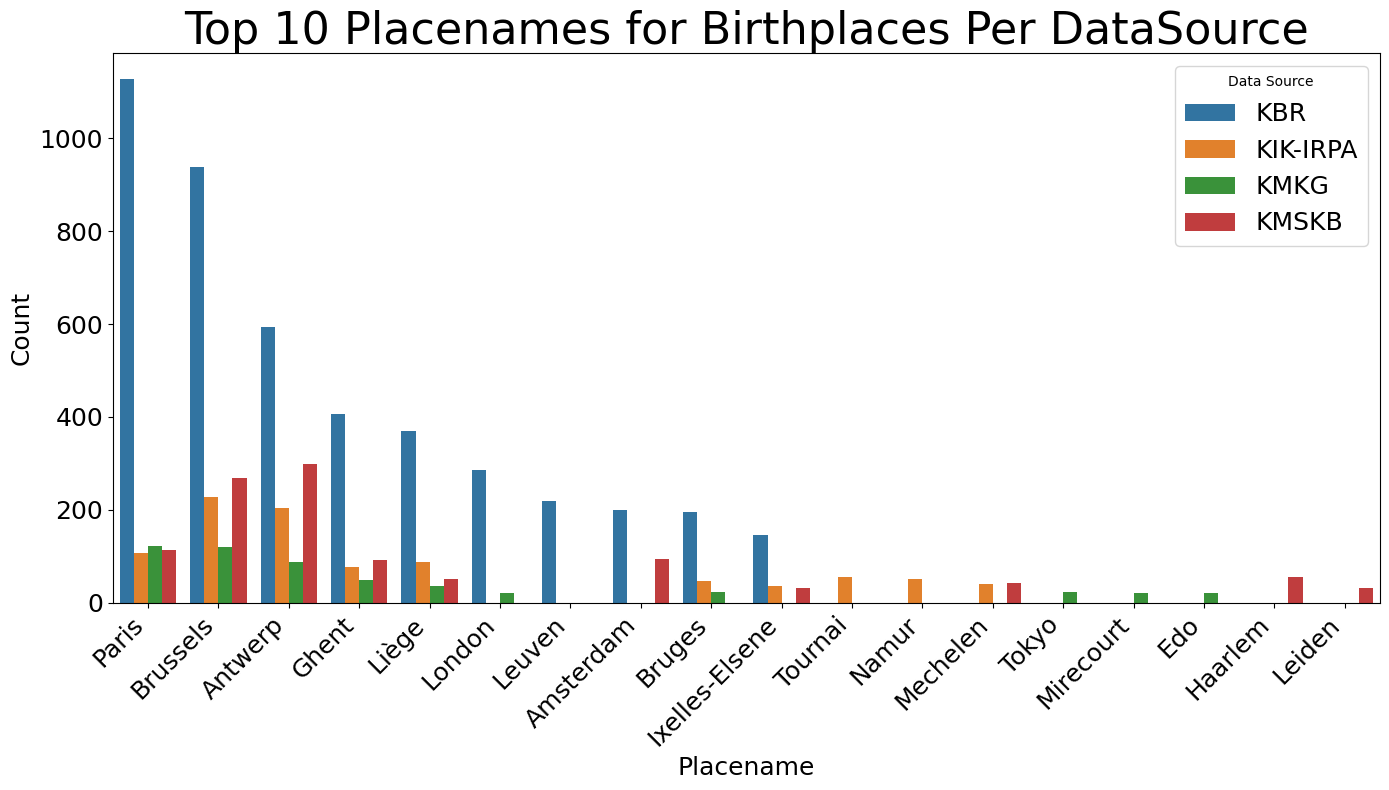

In [192]:
# Create a grouped bar chart
plt.figure(figsize=(14, 8))
sns.barplot(data=top_10_birthplaces, x='placename', y='count', hue='dataSource', dodge=True)

# Customize plot
plt.title('Top 10 Placenames for Birthplaces Per DataSource', fontsize=32)
plt.xlabel('Placename', fontsize=18)
plt.ylabel('Count', fontsize=18)
plt.xticks(rotation=45, ha='right', fontsize=18)  # Enlarged tick labels
plt.yticks(rotation=0, fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Data Source', fontsize=18, loc='upper right')
plt.tight_layout()

plt.savefig('top10-birth-places.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.savefig('top10-birth-places.png', format='png', dpi=300, bbox_inches='tight')

plt.show()

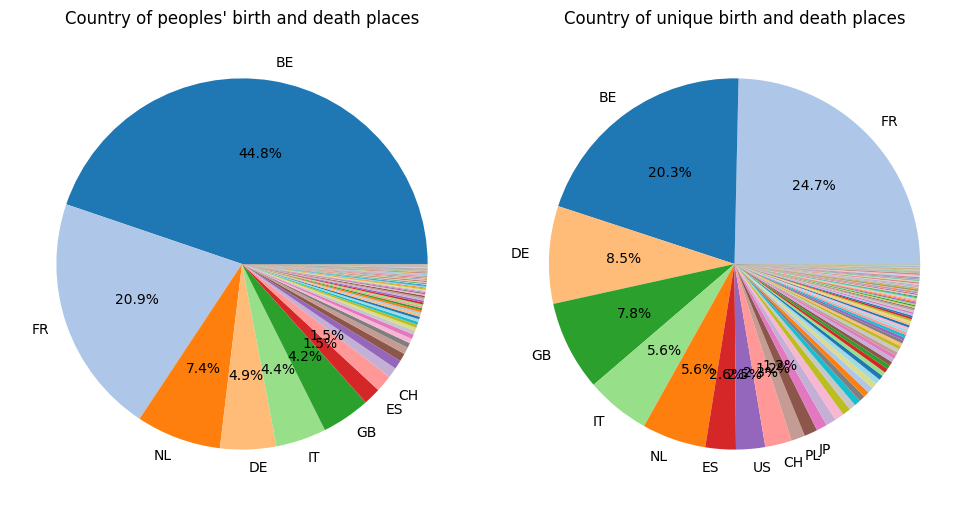

In [193]:

# Compute counts
country_counts_size = placeDf.groupby('countryCode')['placename'].size().sort_values(ascending=False)
country_counts_nunique = placeDf.groupby('countryCode')['placename'].nunique().sort_values(ascending=False)

# Combine and sum counts to get a frequency-based ranking
combined_counts = country_counts_size.add(country_counts_nunique, fill_value=0).sort_values(ascending=False)

# Get countries sorted by overall frequency
sorted_countries = combined_counts.index.tolist()

# Assign colors: Give unique colors to most frequent countries, reuse for less common ones
num_colors = min(len(sorted_countries), 20)  # Limit distinct colors to top 20
palette = sns.color_palette("tab20", num_colors)  # Use "tab20" for distinct colors
color_map = {country: palette[i % num_colors] for i, country in enumerate(sorted_countries)}

# Define function to filter small percentages
def autopct_format(pct):
    return f'{pct:.1f}%' if pct > 1 else ''

# Plot first pie chart (size-based)
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)  # First subplot
plt.title("Country of peoples' birth and death places")
plt.pie(
    country_counts_size, 
    labels=[label if pct > 1 else '' for label, pct in zip(country_counts_size.index, (country_counts_size / country_counts_size.sum()) * 100)],
    autopct=autopct_format, 
    colors=[color_map[country] for country in country_counts_size.index]
)

# Plot second pie chart (nunique-based)
plt.subplot(1, 2, 2)  # Second subplot
plt.title('Country of unique birth and death places')
plt.pie(
    country_counts_nunique, 
    labels=[label if pct > 1 else '' for label, pct in zip(country_counts_nunique.index, (country_counts_nunique / country_counts_nunique.sum()) * 100)],
    autopct=autopct_format, 
    colors=[color_map[country] for country in country_counts_nunique.index]
)

plt.tight_layout()
plt.savefig('placename-by-country.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.savefig('placename-by-country.png', format='png', dpi=300, bbox_inches='tight')
plt.show()


In [194]:
# Aggregate counts by variableType and countryCode
place_type_counts = (placeDf.groupby(['variableType', 'countryCode'])
                     .size()
                     .unstack(level=0)
                     .fillna(0)
                     .astype(int))

# Add a total column and get the top 10 countries
place_type_counts['total'] = place_type_counts.sum(axis=1)
top_10_countries = place_type_counts.nlargest(10, 'total')
top_10_countries

variableType,birthPlace,deathPlace,total
countryCode,,,
BE,10787,5859,16646
FR,4173,3597,7770
NL,1654,1095,2749
DE,1143,670,1813
IT,902,734,1636
GB,862,712,1574
ES,370,193,563
CH,299,250,549
AT,165,165,330


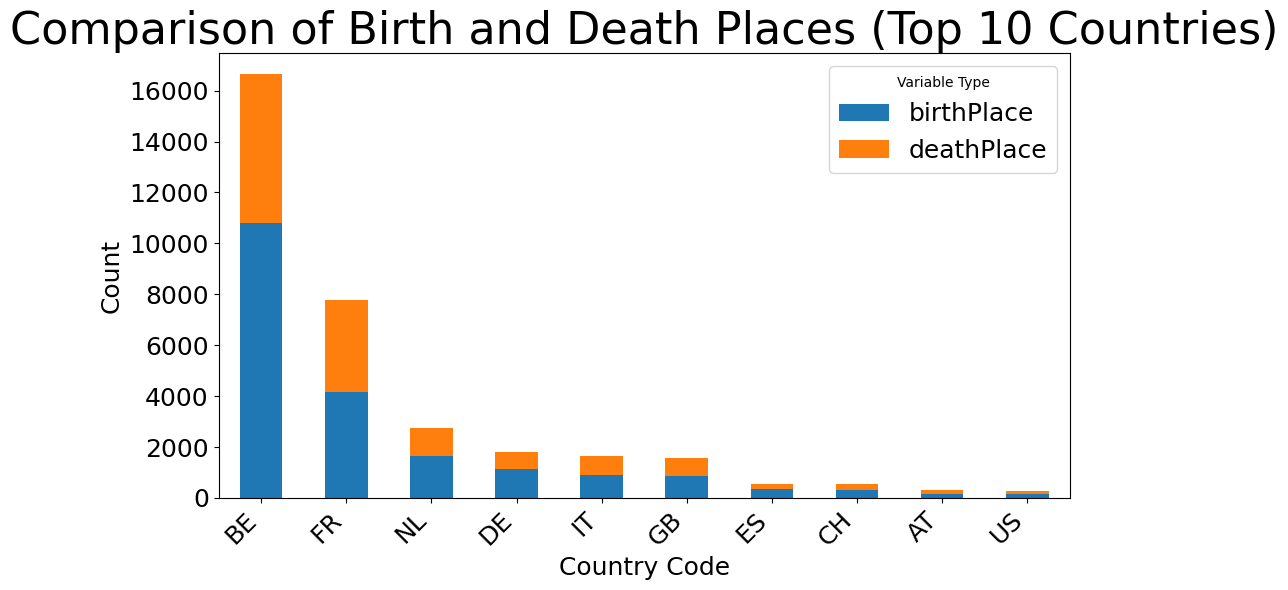

In [195]:

# Plot the top 10 countries
top_10_countries.drop(columns='total').plot(kind='bar', stacked=True, figsize=(10, 6), color=['#1f77b4', '#ff7f0e'])
plt.title('Comparison of Birth and Death Places (Top 10 Countries)', fontsize=32)
plt.xlabel('Country Code', fontsize=18)
plt.ylabel('Count', fontsize=18)
plt.legend(title='Variable Type', fontsize=18)
plt.xticks(rotation=45, ha='right', fontsize=18)  # Enlarged tick labels
plt.yticks(rotation=0, fontsize=18)
plt.tight_layout()

plt.savefig('top10-birth-death-places.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.savefig('top10-birth-death-places.png', format='png', dpi=300, bbox_inches='tight')

plt.show()

In [196]:
top_10_deathplaces = notebook_utils.getTop10Place(placeDf, 'deathPlace')

In [197]:
top_10_deathplaces

,dataSource,placename,count
1268,KBR,Paris,1501
281,KBR,Brussels,756
965,KBR,London,322
65,KBR,Antwerp,292
635,KBR,Ghent,181
958,KBR,Liège,181
46,KBR,Amsterdam,171
788,KBR,Ixelles-Elsene,119
280,KBR,Bruges,111
1668,KBR,Uccle,108


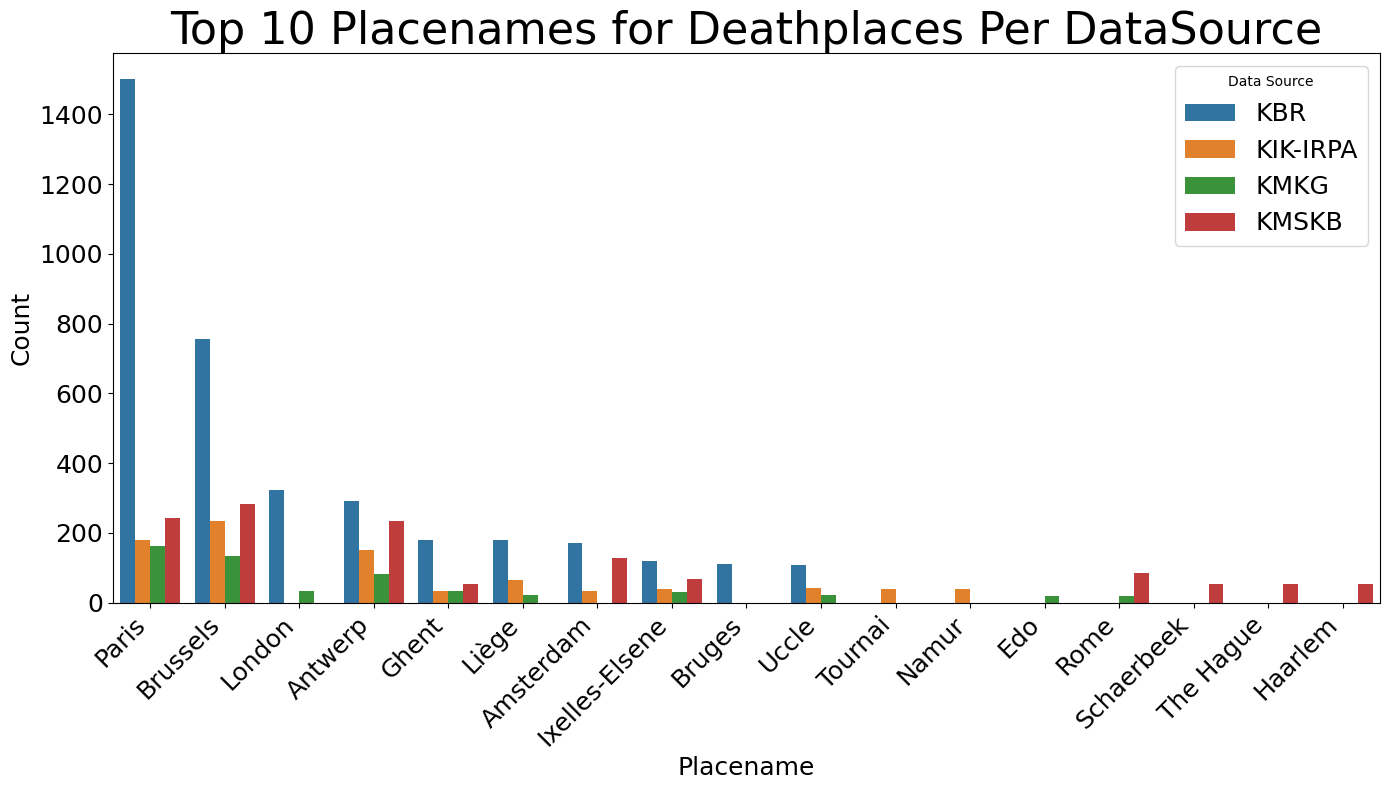

In [198]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a grouped bar chart
plt.figure(figsize=(14, 8))
sns.barplot(data=top_10_deathplaces, x='placename', y='count', hue='dataSource', dodge=True)

# Customize plot
plt.title('Top 10 Placenames for Deathplaces Per DataSource', fontsize=32)
plt.xlabel('Placename', fontsize=18)
plt.ylabel('Count', fontsize=18)
plt.xticks(rotation=45, ha='right', fontsize=18)  # Enlarged tick labels
plt.yticks(rotation=0, fontsize=18)
plt.legend(title='Data Source', fontsize=18, loc='upper right')
plt.tight_layout()

# Save the figure
plt.savefig('top10-death-places.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.savefig('top10-death-places.png', format='png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

 ### Nationality stats

In [199]:
nationalityDf = valueDataframes['nationality']
nationalityDf

,nationality,nationality-original,dataSource
autID,,,
kik-irpa|68,NL,NL,KIK-IRPA
kik-irpa|69,BE,BE,KIK-IRPA
kik-irpa|112,DE,DE,KIK-IRPA
kik-irpa|113,FR,FR,KIK-IRPA
kik-irpa|115,BE,BE,KIK-IRPA
...,...,...,...
kmkg|8043,États-Unis d'Amérique,NaN,KMKG
kmkg|497440,Allemagne,NaN,KMKG
kmkg|8709,Bulgarie,NaN,KMKG


In [200]:
nationalityCounts = notebook_utils.count_multiple_assignments(nationalityDf, 'nationality')
nationalityCounts

,dataSource,unique_nationality_count
autID,,
kbr|21987675,KBR,4
kik-irpa|95807,KIK-IRPA,4
kik-irpa|79903,KIK-IRPA,4
kbr|13907402,KBR,3
kik-irpa|91195,KIK-IRPA,3
...,...,...
kbr|14706760,KBR,2
kbr|14703612,KBR,2
kbr|14700210,KBR,2


In [201]:
nationalityDf[nationalityDf.index == 'kik-irpa|22802']

,nationality,nationality-original,dataSource
autID,,,


In [202]:
nationalityDf[nationalityDf.index == 'kbr|21987675']

,nationality,nationality-original,dataSource
autID,,,
kbr|21987675,ru,NaN,KBR
kbr|21987675,fr,NaN,KBR
kbr|21987675,ua,NaN,KBR
kbr|21987675,sz,NaN,KBR


In [203]:
# Multiple assignments

In [204]:
# Histogram of nationalities

In [205]:
# Standardization of values

### Gender stats

In [206]:
genderDf = valueDataframes['gender']
genderDf

,gender,gender-original,dataSource
autID,,,
kik-irpa|113,man,man,KIK-IRPA
kik-irpa|337,man,man,KIK-IRPA
kik-irpa|347,man,man,KIK-IRPA
kik-irpa|456,man,man,KIK-IRPA
kik-irpa|523,man,man,KIK-IRPA
...,...,...,...
kmkg|497440,Masculin,NaN,KMKG
kmkg|8709,Masculin,NaN,KMKG
kmkg|5678,Masculin,NaN,KMKG


In [207]:
# Multiple assignments
genderCounts = notebook_utils.count_multiple_assignments(genderDf, 'gender')
genderCounts

,dataSource,unique_gender_count
autID,,
kbr|14554760,KBR,2
kbr|14559406,KBR,2


In [208]:
genderDf[genderDf.index == 'kbr|14559406']

,gender,gender-original,dataSource
autID,,,
kbr|14559406,M,NaN,KBR
kbr|14559406,F,NaN,KBR


In [209]:
genderDf['gender'].value_counts()

gender
M           152832
F            63493
Masculin      4001
1             2821
man           1573
Féminin        274
2              169
U              120
vrouw          112
onbekend        80
X               16
Inconnu         16
Name: count, dtype: int64

In [210]:
# Histogram

In [211]:
# Standardization of values

### Occupation stats

In [212]:
roleDf = valueDataframes['role']
roleDf

,role,role-original,dataSource
autID,,,
kik-irpa|19,author,author,KIK-IRPA
kik-irpa|19,creator,creator,KIK-IRPA
kik-irpa|19,curator,curator,KIK-IRPA
kik-irpa|19,person,person,KIK-IRPA
kik-irpa|42,publisher,publisher,KIK-IRPA
...,...,...,...
kmskb|509/992,1,NaN,KMSKB
kmskb|509/993,1,NaN,KMSKB
kmskb|509/994,1,NaN,KMSKB


In [213]:
# Multiple occupations
roleCounts = notebook_utils.count_multiple_assignments(roleDf, 'role')
roleCounts

,dataSource,unique_role_count
autID,,
kbr|14664938,KBR,9
kik-irpa|1711,KIK-IRPA,8
kik-irpa|199,KIK-IRPA,8
kik-irpa|35068,KIK-IRPA,8
kik-irpa|28883,KIK-IRPA,8
...,...,...
kik-irpa|115649,KIK-IRPA,2
kik-irpa|115658,KIK-IRPA,2
kik-irpa|115660,KIK-IRPA,2


In [214]:
roleCounts[roleCounts['dataSource'] == 'KIK-IRPA']

,dataSource,unique_role_count
autID,,
kik-irpa|1711,KIK-IRPA,8
kik-irpa|199,KIK-IRPA,8
kik-irpa|35068,KIK-IRPA,8
kik-irpa|28883,KIK-IRPA,8
kik-irpa|156481,KIK-IRPA,8
...,...,...
kik-irpa|115649,KIK-IRPA,2
kik-irpa|115658,KIK-IRPA,2
kik-irpa|115660,KIK-IRPA,2


In [215]:
roleDf[roleDf.index == 'kik-irpa|2554']

,role,role-original,dataSource
autID,,,
kik-irpa|2554,author,author,KIK-IRPA
kik-irpa|2554,creator,creator,KIK-IRPA
kik-irpa|2554,Dossier contactperson,Dossier contactperson,KIK-IRPA
kik-irpa|2554,Employee KIK-IRPA,Employee KIK-IRPA,KIK-IRPA
kik-irpa|2554,curator,curator,KIK-IRPA
kik-irpa|2554,acquisition source,acquisition source,KIK-IRPA
kik-irpa|2554,Dossier applicatant,Dossier applicatant,KIK-IRPA
kik-irpa|2554,person,person,KIK-IRPA


In [216]:
roleCounts[roleCounts['dataSource'] == 'KMSKB']

,dataSource,unique_role_count
autID,,
kmskb|509/268,KMSKB,6
kmskb|509/1624,KMSKB,6
kmskb|509/3189,KMSKB,6
kmskb|509/325,KMSKB,6
kmskb|509/2274,KMSKB,5
...,...,...
kmskb|509/2929,KMSKB,2
kmskb|509/294,KMSKB,2
kmskb|509/295,KMSKB,2


In [217]:
roleDf[roleDf.index == 'kmskb|509/325']

,role,role-original,dataSource
autID,,,
kmskb|509/325,1,NaN,KMSKB
kmskb|509/325,10,NaN,KMSKB
kmskb|509/325,12,NaN,KMSKB
kmskb|509/325,13,NaN,KMSKB
kmskb|509/325,7,NaN,KMSKB
kmskb|509/325,3,NaN,KMSKB


In [218]:
roleCounts[roleCounts['dataSource'] == 'KBR']

,dataSource,unique_role_count
autID,,
kbr|14664938,KBR,9
kbr|14757885,KBR,6
kbr|14536701,KBR,5
kbr|14560944,KBR,5
kbr|14178485,KBR,5
...,...,...
kbr|14503373,KBR,2
kbr|14503923,KBR,2
kbr|14502855,KBR,2


In [219]:
roleDf[roleDf.index == 'kbr|14664938']

,role,role-original,dataSource
autID,,,
kbr|14664938,Chanteur Ténor allemand,NaN,KBR
kbr|14664938,Leo Frank,NaN,KBR
kbr|14664938,Leo Moll,NaN,KBR
kbr|14664938,Léon Monosson,NaN,KBR
kbr|14664938,Leo Frey,NaN,KBR
kbr|14664938,Leo Emm,NaN,KBR
kbr|14664938,Leo Moon,NaN,KBR
kbr|14664938,Leo Minor,NaN,KBR
kbr|14664938,Fred Mossner,NaN,KBR


In [220]:
roleDf[roleDf.index == 'kbr|14757885']

,role,role-original,dataSource
autID,,,
kbr|14757885,Landvoogd van de Oostenrijkse Nederlanden,NaN,KBR
kbr|14757885,Hertog van Teschen,NaN,KBR
kbr|14757885,Governor of the Austrian Netherlands,NaN,KBR
kbr|14757885,Duke of Teschen,NaN,KBR
kbr|14757885,Gouverneur-général des Pays-Bas autrichiens,NaN,KBR
kbr|14757885,Duc de Teschen,NaN,KBR


In [221]:
# Histogram

In [222]:
# Standardization of values

## datafield stats for records without standard identifiers
We count how often data fields are filled in for records that do *not* have ISNI or VIAF identifiers.

In [223]:
statsDf.loc[statsDf['isni'].isna() & statsDf['viaf'].isna()].explode('birthDateEDTF').groupby(['dataSource']).count()

,isni,name,alternateNames,birthDate-original,birthDate,deathDate-original,deathDate,birthPlace-original,birthPlace,deathPlace-original,...,deathDate_value,deathDate_rule,birthDate100dEDTF,birthDate100dType,birthDate100dEDTFRule,deathDate100dEDTF,deathDate100dType,deathDate100dEDTFRule,birthDateEDTF,deathDateEDTF
dataSource,,,,,,,,,,,,,,,,,,,,,
KBR,0,429408,13390,429415,5716,429415,4690,429415,3913,429415,...,57860,4690,59957,429403,59957,53170,429403,53170,65673,57860
KIK-IRPA,0,29800,4397,29800,10561,29800,8217,29800,2049,29800,...,8217,8217,0,0,0,0,0,0,10561,8217
KMKG,0,5572,472,6092,751,6092,648,0,853,0,...,648,648,0,0,0,0,0,0,751,648
KMSKB,0,3192,0,3193,2931,3193,2590,0,2785,0,...,2590,2590,0,0,0,0,0,0,2931,2590


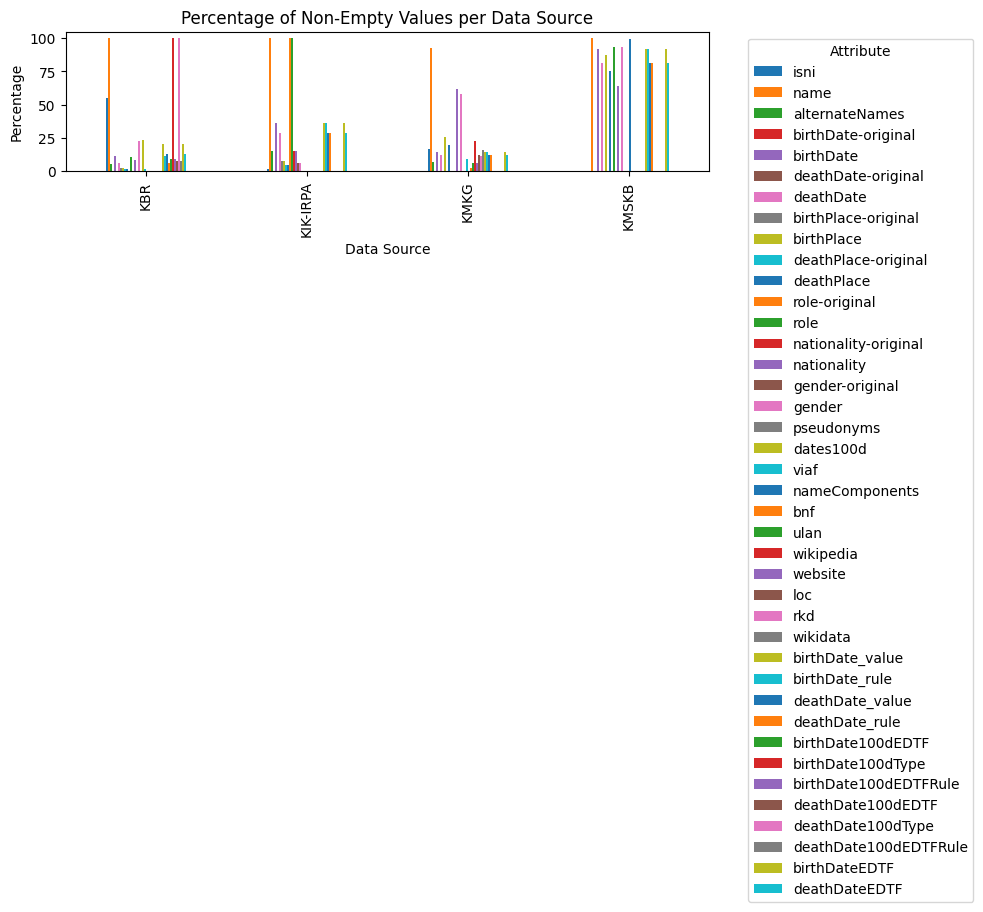

In [224]:
# Specify the columns to exclude from visualization
exclude_columns = ['dataSource']

# Group by 'dataSource' and apply the non_empty_percentage function to each column except the excluded ones
percentages = statsDf.groupby('dataSource').apply(lambda group: group.drop(columns=exclude_columns).apply(utils.non_empty_percentage))

# Plot the stacked bars with the same color palette
percentages.plot.bar()

# Add labels and title
plt.title('Percentage of Non-Empty Values per Data Source')
plt.xlabel('Data Source')
plt.ylabel('Percentage')

# Add legend
plt.legend(title='Attribute', bbox_to_anchor=(1.05, 1), loc='upper left')

# Set the size of the current figure
plt.gcf().set_size_inches(10, 6)  # Width: 10 inches, Height: 6 inches

# Show the plot
plt.tight_layout()
plt.show()

In [225]:
percentages

,isni,name,alternateNames,birthDate-original,birthDate,deathDate-original,deathDate,birthPlace-original,birthPlace,deathPlace-original,...,deathDate_value,deathDate_rule,birthDate100dEDTF,birthDate100dType,birthDate100dEDTFRule,deathDate100dEDTF,deathDate100dType,deathDate100dEDTFRule,birthDateEDTF,deathDateEDTF
dataSource,,,,,,,,,,,,,,,,,,,,,
KBR,54.881922,99.999268,5.287368,0.0,11.176968,0.0,5.861989,2.507873,2.507873,1.47410,...,13.094323,5.861989,8.921995,99.997071,8.921995,7.232334,99.997071,7.232334,20.098964,13.094323
KIK-IRPA,1.432210,100.000000,14.950551,0.0,36.258393,0.0,28.369662,7.571197,7.571197,4.36609,...,28.369662,28.369662,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,36.258393,28.369662
KMKG,16.140976,92.718047,6.609984,0.0,14.440483,0.0,11.642896,0.000000,25.850247,0.00000,...,11.642896,11.642896,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.440483,11.642896
KMSKB,0.000000,99.968681,0.000000,0.0,91.794551,0.0,81.114939,0.000000,87.222048,0.00000,...,81.114939,81.114939,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,91.794551,81.114939


In [226]:
#df = pd.read_csv('kik-irpa/kik-irpa-data.csv', converters={'name':jsonParser}, dtype=str, keep_default_na=False)

In [227]:
#df.name = df.name.tolist()

In [228]:
statsDf[statsDf['dataSource'] == 'KIK-IRPA']['name'][0][0]

'Wery, Anthoon'

In [229]:
# ID 3 no longer part of the export
#statsDf[statsDf.index == "kik-irpa|3"]['name'][0][0]

In [230]:
statsDf.columns

Index(['isni', 'name', 'alternateNames', 'birthDate-original', 'birthDate',
       'deathDate-original', 'deathDate', 'birthPlace-original', 'birthPlace',
       'deathPlace-original', 'deathPlace', 'role-original', 'role',
       'nationality-original', 'nationality', 'gender-original', 'gender',
       'dataSource', 'pseudonyms', 'dates100d', 'viaf', 'nameComponents',
       'bnf', 'ulan', 'wikipedia', 'website', 'loc', 'rkd', 'wikidata',
       'birthDate_value', 'birthDate_rule', 'deathDate_value',
       'deathDate_rule', 'birthDate100dEDTF', 'birthDate100dType',
       'birthDate100dEDTFRule', 'deathDate100dEDTF', 'deathDate100dType',
       'deathDate100dEDTFRule', 'birthDateEDTF', 'deathDateEDTF'],
      dtype='object')

## Data quality categories

In [231]:
# statsDf
mainDfCategories = statsDf.copy()
placeDfCategories = placeDf.copy()

birthDateDfCategories = birthDateDf
deathDateDfCategories = deathDateDf

In [232]:
placeDfCategories[(placeDfCategories["dataSource"] == "KBR") & (placeDfCategories["variableType"] == "birthPlace")]

,geonameID,placename,countryCode,dataSource,variableType,relationshipType,placeComment,comment
kbr|14022004,2487134,Mostaganem,DZ,KBR,birthPlace,NaN,NaN,NaN
kbr|14237973,2784821,Verviers,BE,KBR,birthPlace,NaN,NaN,NaN
kbr|14518737,2800866,Brussels,BE,KBR,birthPlace,NaN,NaN,NaN
kbr|22067289,3033123,Besançon,FR,KBR,birthPlace,NaN,NaN,NaN
kbr|14021194,2784821,Verviers,BE,KBR,birthPlace,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
kbr|22746110,6086225,Natashquan,CA,KBR,birthPlace,NaN,NaN,NaN
kbr|22746368,2988507,Paris,FR,KBR,birthPlace,NaN,NaN,NaN
kbr|22746373,2800866,Brussels,BE,KBR,birthPlace,NaN,NaN,NaN
kbr|22746391,2800866,Brussels,BE,KBR,birthPlace,NaN,NaN,NaN


In [233]:
birthPlaceDfCategories = placeDfCategories[placeDfCategories['variableType'] == 'birthPlace'].copy()
deathPlaceDfCategories = placeDfCategories[placeDfCategories['variableType'] == 'deathPlace'].copy()

birthPlaceDfCategories['geonameID'] = birthPlaceDfCategories['geonameID'].astype(str)
deathPlaceDfCategories['geonameID'] = deathPlaceDfCategories['geonameID'].astype(str)
#df.merge(placeDf, how='left', left_on='autID', right_on='autID')

In [234]:
# all dataframes that we will merge soon (main dataframe with enriched 1:n dataframes)
allInfoDataframes = [mainDfCategories, birthPlaceDfCategories, deathPlaceDfCategories, 
                     birthDateDfCategories, deathDateDfCategories]


In [235]:
birthPlaceDfCategories[birthPlaceDfCategories.index == "kbr|21392424"]

,geonameID,placename,countryCode,dataSource,variableType,relationshipType,placeComment,comment


In [236]:
from functools import reduce

# Define which columns to keep from each dataframe
columns_to_keep = {
    "birthPlaceDf": ["geonameIDBirth", "countryCodeBirth", "placenameBirth", "relationshipTypeBirth", "placeCommentBirth"],
    "deathPlaceDf": ["geonameIDDeath", "countryCodeDeath", "placenameDeath", "relationshipTypeDeath", "placeCommentDeath"],
    "birthDate": ["birthDateEDTF"],
    "deathDate": ["deathDateEDTF"]
}

columns_rename = {
    "birthPlaceDf": {'geonameID': 'geonameIDBirth', 'countryCode': 'countryCodeBirth', 'placename': 'placenameBirth', 
                     "relationshipType": "relationshipTypeBirth", "placeComment": "placeCommentBirth"},
    "deathPlaceDf": {'geonameID': 'geonameIDDeath', 'countryCode': 'countryCodeDeath', 'placename': 'placenameDeath',
                     'relationshipType': 'relationshipTypeDeath', 'placeComment': 'placeCommentDeath'}
}

# Function to preprocess a dataframe before merging
def prepare_df(df, keep_columns, columns_rename=None):
    preparedDf = df.copy()
    if columns_rename:
        preparedDf = preparedDf.rename(columns=columns_rename)
    """Select only the needed columns and aggregate duplicates"""
    preparedDf = preparedDf[keep_columns]  # Keep only relevant columns
    #if len(keep_columns) > 2:  # If more than just autID and one column, aggregate
    #    preparedDf = preparedDf.groupby("autID").agg(lambda x: "; ".join(map(str, x))).reset_index()
    return preparedDf

# Prepare all additional dataframes
birthPlaceDfForMerge = prepare_df(birthPlaceDfCategories, columns_to_keep["birthPlaceDf"], columns_rename["birthPlaceDf"])
deathPlaceDfForMerge = prepare_df(deathPlaceDfCategories, columns_to_keep["deathPlaceDf"], columns_rename["deathPlaceDf"])

birthDf = prepare_df(birthDateDfCategories, columns_to_keep["birthDate"])
deathDf = prepare_df(deathDateDfCategories, columns_to_keep["deathDate"])

# Merge step by step
allInfoDf = mainDfCategories.copy()  # Start with the main df
allInfoDf = allInfoDf.rename(columns={'birthDateEDTF': 'birthDate', 'deathDateEDTF': 'deathDate'})
for right_df in [birthPlaceDfForMerge, deathPlaceDfForMerge, birthDf, deathDf]:
    allInfoDf = allInfoDf.merge(right_df, left_index=True, right_index=True, how="left")

In [237]:
mainDfCategories.shape[0]

996827

In [238]:
allInfoDf.shape[0]

1000683

In [239]:
allInfoDf.columns

Index(['isni', 'name', 'alternateNames', 'birthDate-original', 'birthDate',
       'deathDate-original', 'deathDate', 'birthPlace-original', 'birthPlace',
       'deathPlace-original', 'deathPlace', 'role-original', 'role',
       'nationality-original', 'nationality', 'gender-original', 'gender',
       'dataSource', 'pseudonyms', 'dates100d', 'viaf', 'nameComponents',
       'bnf', 'ulan', 'wikipedia', 'website', 'loc', 'rkd', 'wikidata',
       'birthDate_value', 'birthDate_rule', 'deathDate_value',
       'deathDate_rule', 'birthDate100dEDTF', 'birthDate100dType',
       'birthDate100dEDTFRule', 'deathDate100dEDTF', 'deathDate100dType',
       'deathDate100dEDTFRule', 'birthDate', 'deathDate', 'geonameIDBirth',
       'countryCodeBirth', 'placenameBirth', 'relationshipTypeBirth',
       'placeCommentBirth', 'geonameIDDeath', 'countryCodeDeath',
       'placenameDeath', 'relationshipTypeDeath', 'placeCommentDeath',
       'birthDateEDTF', 'deathDateEDTF'],
      dtype='object')

In [240]:
allInfoDf.index[allInfoDf.index.duplicated()]

Index(['kbr|10038486', 'kbr|10038567', 'kbr|10038567', 'kbr|10038567',
       'kbr|10039040', 'kbr|10039040', 'kbr|10039040', 'kbr|10039073',
       'kbr|10039073', 'kbr|10039073',
       ...
       'kmskb|509/366', 'kmskb|509/3729', 'kmskb|509/420', 'kmskb|509/424',
       'kmskb|509/489', 'kmskb|509/593', 'kmskb|509/728', 'kmskb|509/740',
       'kmskb|509/758', 'kmskb|509/864'],
      dtype='object', name='autID', length=3856)

In [241]:
#allInfoDf = allInfoDf.reset_index()[allInfoDf.reset_index().astype(str).duplicated()].set_index('autID')
#allInfoDf = allInfoDf.reset_index().astype(str).drop_duplicates().set_index('autID')
realDuplicatesMask = allInfoDf.reset_index().astype(str).duplicated()

allInfoDf = allInfoDf.reset_index()[~realDuplicatesMask].copy().set_index('autID')

In [242]:
allInfoDf.index[allInfoDf.index.duplicated()]

Index(['kbr|14113992', 'kbr|21239831', 'kbr|21637615', 'kbr|22153450',
       'kik-irpa|101808', 'kik-irpa|102085', 'kik-irpa|102726',
       'kik-irpa|103405', 'kik-irpa|107066', 'kik-irpa|134206',
       'kik-irpa|22617', 'kik-irpa|255888', 'kik-irpa|256012',
       'kik-irpa|256019', 'kik-irpa|97375', 'kmskb|509/1326', 'kmskb|509/1326',
       'kmskb|509/1326', 'kmskb|509/1460', 'kmskb|509/1501', 'kmskb|509/1553',
       'kmskb|509/1580', 'kmskb|509/16', 'kmskb|509/1660', 'kmskb|509/2389',
       'kmskb|509/2514', 'kmskb|509/2719', 'kmskb|509/2843', 'kmskb|509/3075',
       'kmskb|509/318', 'kmskb|509/3333', 'kmskb|509/339', 'kmskb|509/366',
       'kmskb|509/3729', 'kmskb|509/420', 'kmskb|509/424', 'kmskb|509/489',
       'kmskb|509/593', 'kmskb|509/728', 'kmskb|509/740', 'kmskb|509/758',
       'kmskb|509/864'],
      dtype='object', name='autID')

In [243]:
# example of a case where real duplicates were removed and a single record remained
allInfoDf[allInfoDf.index == 'kbr|10038567']

,isni,name,alternateNames,birthDate-original,birthDate,deathDate-original,deathDate,birthPlace-original,birthPlace,deathPlace-original,...,placenameBirth,relationshipTypeBirth,placeCommentBirth,geonameIDDeath,countryCodeDeath,placenameDeath,relationshipTypeDeath,placeCommentDeath,birthDateEDTF,deathDateEDTF
autID,,,,,,,,,,,,,,,,,,,,,
kbr|10038567,[0000 0003 8204 8376],[Leopold II],"[Brabant (Léopold; duc de), Leopold II, II. Li...",,"[{'birthDate': '1835-04-09', 'rule': 'simplePa...",,"[{'deathDate': '1909-12-17', 'rule': 'simplePa...","['Bruxelles (Belgique)', 'Bruxelles']","[Bruxelles (Belgique), Bruxelles]","['Laeken (Belgique)', 'Laeken']",...,Brussels,NaN,NaN,2793656,BE,Laken,NaN,NaN,1835-04-09,1909-12-17


In [244]:
# example of a case where the combination of index and columns results in a duplicate autID, but different rows
allInfoDf[allInfoDf.index == 'kmskb|509/366']

,isni,name,alternateNames,birthDate-original,birthDate,deathDate-original,deathDate,birthPlace-original,birthPlace,deathPlace-original,...,placenameBirth,relationshipTypeBirth,placeCommentBirth,geonameIDDeath,countryCodeDeath,placenameDeath,relationshipTypeDeath,placeCommentDeath,birthDateEDTF,deathDateEDTF
autID,,,,,,,,,,,,,,,,,,,,,
kmskb|509/366,NaN,"[VAN DER HAAGEN, Joris]",NaN,,"[{'birthDate': '1615~', 'rule': 'circa_year', ...",,"[{'deathDate': '1669', 'rule': 'simplePattern'...",NaN,"[Dordrecht (Nederland) [dut], Arnhem (Nederlan...",NaN,...,Dordrecht,NaN,NaN,2747373,NL,The Hague,NaN,NaN,1615~,1669
kmskb|509/366,NaN,"[VAN DER HAAGEN, Joris]",NaN,,"[{'birthDate': '1615~', 'rule': 'circa_year', ...",,"[{'deathDate': '1669', 'rule': 'simplePattern'...",NaN,"[Dordrecht (Nederland) [dut], Arnhem (Nederlan...",NaN,...,Arnhem,NaN,NaN,2747373,NL,The Hague,NaN,NaN,1615~,1669


In [245]:
duplicates_indices = allInfoDf.index[allInfoDf.index.duplicated()].unique()
allInfoDf[allInfoDf.index.isin(duplicates_indices)].to_csv(duplicateAutIDofMainDfCategories)
allInfoDf = allInfoDf[~allInfoDf.index.isin(duplicates_indices)]

In [246]:
# column with lists is now a string after I had to cast everything for duplicate deletion
#allInfoDf[allInfoDf.index == 'kbr|10038105']['name'][0][0]

In [247]:
mainDfCategories.shape[0]

996827

In [248]:
allInfoDf.shape[0]

996787

In [249]:
mainDfCategories['birthDateEDTF'].isna().value_counts()

birthDateEDTF
True     789713
False    207114
Name: count, dtype: int64

In [250]:
allInfoDf['birthDateEDTF'].isna().value_counts()

birthDateEDTF
True     789713
False    207074
Name: count, dtype: int64

In [251]:
allInfoDf[allInfoDf.index == 'kmskb|509/2557']

,isni,name,alternateNames,birthDate-original,birthDate,deathDate-original,deathDate,birthPlace-original,birthPlace,deathPlace-original,...,placenameBirth,relationshipTypeBirth,placeCommentBirth,geonameIDDeath,countryCodeDeath,placenameDeath,relationshipTypeDeath,placeCommentDeath,birthDateEDTF,deathDateEDTF
autID,,,,,,,,,,,,,,,,,,,,,
kmskb|509/2557,NaN,"[van Imschoot, Jules, van Imschoot, Jules, van...",NaN,,"[{'birthDate': '1821', 'rule': 'simplePattern'...",,"[{'deathDate': '1884', 'rule': 'simplePattern'...",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1821,1884


In [252]:
birthPlaceDfForMerge[birthPlaceDfForMerge['geonameIDBirth'].notna()]

,geonameIDBirth,countryCodeBirth,placenameBirth,relationshipTypeBirth,placeCommentBirth
kik-irpa|69,2795011,BE,Ixelles-Elsene,NaN,NaN
kik-irpa|115,2791964,BE,Maaseik,NaN,NaN
kik-irpa|240,2988507,FR,Paris,NaN,NaN
kik-irpa|248,3024090,FR,Commentry,NaN,NaN
kik-irpa|347,2785470,BE,Tienen,NaN,NaN
...,...,...,...,...,...
kmkg|9225,3123889,ES,Dima,NaN,NaN
kmkg|943,2826384,DE,Storndorf,NaN,NaN
kmkg|99,6695204,GB,Barnwood,NaN,NaN
kmkg|99450,2791324,BE,Merchtem,NaN,NaN


In [253]:
# debugging merging in case something does not work as expected after changes
#
#testDf = mainDfCategories.merge(birthPlaceDfForMerge, left_on="autID", right_on="autID", how="left")
#testDf[testDf["autID"] == 'KBR|21392424']
#birthPlaceDfCategories[birthPlaceDfCategories["autID"] == "KBR|21392424"]
#testDf[testDf['autID'].str.startswith('KBR')]

In [254]:
allInfoDf.columns

Index(['isni', 'name', 'alternateNames', 'birthDate-original', 'birthDate',
       'deathDate-original', 'deathDate', 'birthPlace-original', 'birthPlace',
       'deathPlace-original', 'deathPlace', 'role-original', 'role',
       'nationality-original', 'nationality', 'gender-original', 'gender',
       'dataSource', 'pseudonyms', 'dates100d', 'viaf', 'nameComponents',
       'bnf', 'ulan', 'wikipedia', 'website', 'loc', 'rkd', 'wikidata',
       'birthDate_value', 'birthDate_rule', 'deathDate_value',
       'deathDate_rule', 'birthDate100dEDTF', 'birthDate100dType',
       'birthDate100dEDTFRule', 'deathDate100dEDTF', 'deathDate100dType',
       'deathDate100dEDTFRule', 'birthDate', 'deathDate', 'geonameIDBirth',
       'countryCodeBirth', 'placenameBirth', 'relationshipTypeBirth',
       'placeCommentBirth', 'geonameIDDeath', 'countryCodeDeath',
       'placenameDeath', 'relationshipTypeDeath', 'placeCommentDeath',
       'birthDateEDTF', 'deathDateEDTF'],
      dtype='object')

In [255]:
allInfoDfCategories = allInfoDf[['name', 'alternateNames', 'isni', 'viaf',
                                  'geonameIDBirth', 'geonameIDDeath', 'placenameBirth', 'birthPlace', 'placenameDeath', 'deathPlace',
                                  'dataSource', 'website', 'relationshipTypeBirth', 'relationshipTypeDeath', 'placeCommentBirth', 'placeCommentDeath',
                                  'birthDateEDTF', 'deathDateEDTF', 'countryCodeBirth', 'countryCodeDeath']].copy()  # Add .copy() to avoid SettingWithCopyWarning

#allInfoDfCategories['name'] = allInfoDfCategories['name'].apply(nanToList)
#allInfoDfCategories['alternateNames'] = allInfoDfCategories['alternateNames'].apply(nanToList)


In [256]:
allInfoDfCategories.shape[0]

996787

In [257]:
# remove duplicates
#allInfoDfCategories = allInfoDfCategories.loc[allInfoDfCategories.astype(str).drop_duplicates().index]

In [258]:
allInfoDfCategories['birthDateEDTF'].isna().value_counts()

birthDateEDTF
True     789713
False    207074
Name: count, dtype: int64

In [259]:
# test duplicate removal for one specific instance
allInfoDfCategories[allInfoDfCategories.index =='kmskb|509/2557']

,name,alternateNames,isni,viaf,geonameIDBirth,geonameIDDeath,placenameBirth,birthPlace,placenameDeath,deathPlace,dataSource,website,relationshipTypeBirth,relationshipTypeDeath,placeCommentBirth,placeCommentDeath,birthDateEDTF,deathDateEDTF,countryCodeBirth,countryCodeDeath
autID,,,,,,,,,,,,,,,,,,,,
kmskb|509/2557,"[van Imschoot, Jules, van Imschoot, Jules, van...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,KMSKB,NaN,NaN,NaN,NaN,NaN,1821,1884,NaN,NaN


In [260]:
pd.set_option('display.max_colwidth', 500)
allInfoDf[allInfoDf.index =='kmskb|509/2557']

,isni,name,alternateNames,birthDate-original,birthDate,deathDate-original,deathDate,birthPlace-original,birthPlace,deathPlace-original,...,placenameBirth,relationshipTypeBirth,placeCommentBirth,geonameIDDeath,countryCodeDeath,placenameDeath,relationshipTypeDeath,placeCommentDeath,birthDateEDTF,deathDateEDTF
autID,,,,,,,,,,,,,,,,,,,,,
kmskb|509/2557,NaN,"[van Imschoot, Jules, van Imschoot, Jules, van Imschoot, Jules]",NaN,,"[{'birthDate': '1821', 'rule': 'simplePattern', 'birthDate-original': '1821'}, {'birthDate': '1821', 'rule': 'simplePattern', 'birthDate-original': '1821'}]",,"[{'deathDate': '1884', 'rule': 'simplePattern', 'deathDate-original': '1884'}, {'deathDate': '1884', 'rule': 'simplePattern', 'deathDate-original': '1884'}]",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1821,1884


In [261]:
allInfoDfCategories[allInfoDfCategories.index == 'kmskb|509/875']['birthDateEDTF']

autID
kmskb|509/875    [1460,1470]
Name: birthDateEDTF, dtype: object

In [262]:
#allInfoDfCategories[allInfoDfCategories['birthDateEDTF']

In [263]:
# define named filters (masks) to have a more readable classification into quality categories afterwards

atLeastOneStandardIdentifier = (allInfoDfCategories["isni"].notna() | (allInfoDfCategories["viaf"]).notna())
noStandardIdentifier = allInfoDfCategories["isni"].isna() & (allInfoDfCategories["viaf"]).isna()
atLeastOneName = (allInfoDfCategories["name"].notna() | allInfoDfCategories["alternateNames"].notna())

hasBirthPlace = allInfoDfCategories["birthPlace"].notna()
hasDeathPlace = allInfoDfCategories["deathPlace"].notna()
hasGeonameBirthPlace = allInfoDfCategories["geonameIDBirth"].notna()
hasGeonameDeathPlace = allInfoDfCategories["geonameIDDeath"].notna()
hasBirthDate = allInfoDfCategories["birthDateEDTF"].notna()
hasDeathDate = allInfoDfCategories["deathDateEDTF"].notna()

hasPlaces = hasBirthPlace & hasDeathPlace
hasGeonamePlaces = hasGeonameBirthPlace & hasGeonameDeathPlace
hasDates = hasBirthDate & hasDeathDate

noName = (allInfoDfCategories["name"].isna() & allInfoDfCategories["alternateNames"].isna())
noBirthPlace = ~hasBirthPlace
noDeathPlace = ~hasDeathPlace
noGeonameBirthPlace = ~hasGeonameBirthPlace
noGeonameDeathPlace = ~hasGeonameDeathPlace
noBirthDate = ~hasBirthDate
noDeathDate = ~hasDeathDate

noDates = noBirthDate & noDeathDate
noPlaces = noBirthPlace & noDeathPlace
noGeonamePlaces = noGeonameBirthPlace & noGeonameDeathPlace
noNames = (allInfoDfCategories["name"].isna() & allInfoDfCategories["alternateNames"].isna())

In [264]:
# External identifier and complete standardized metadata
mbq1Mask = atLeastOneStandardIdentifier & atLeastOneName & hasPlaces & hasGeonamePlaces & hasDates

# External identifier but incomplete metadata
mbq2Mask = atLeastOneStandardIdentifier & \
  (noName | noBirthDate | noDeathDate | noBirthPlace | noDeathPlace | noGeonameBirthPlace | noGeonameDeathPlace)

# Complete standardized metadata but missing external identifier
mbq3Mask = noStandardIdentifier & atLeastOneName & hasPlaces & hasGeonamePlaces & hasDates

# Unstandardized place
mbq4Mask = (hasBirthPlace & noGeonameBirthPlace) | (hasDeathPlace & noGeonameDeathPlace)

# Date but no place and no external identifier
mbq5Mask = noStandardIdentifier & (hasBirthDate & noBirthPlace & noGeonameBirthPlace) | (hasDeathDate & noDeathPlace & noGeonameDeathPlace)

# Place but no date and no external identifier
mbq6Mask = noStandardIdentifier & (hasBirthPlace & hasGeonameBirthPlace & noBirthDate) | (hasDeathPlace & hasGeonameDeathPlace & noDeathDate)

# Missing metadata and no external identifier
mbq7Mask = noStandardIdentifier & atLeastOneName & \
  (noBirthDate | noDeathDate | noBirthPlace | noDeathPlace | noGeonameBirthPlace | noGeonameDeathPlace)

# Only  name, no metadata and no external identifier
mbq8Mask = atLeastOneName & noStandardIdentifier & noPlaces & noGeonamePlaces & noDates

# Not even a name
mbq9Mask = noStandardIdentifier & noNames



In [265]:
qualityMasks = [
    (mbq1Mask, 'mbq1'), 
    (mbq2Mask, 'mbq2'), 
    (mbq3Mask, 'mbq3'), 
    (mbq7Mask, 'mbq7'), # mbq7 should be applied before mbq5 and mbq6
    (mbq5Mask, 'mbq5'), 
    (mbq6Mask, 'mbq6'),
    (mbq8Mask, 'mbq8'),
    (mbq9Mask, 'mbq9'),
    (mbq4Mask, 'mbq4')] # mbq4 needs to be applied last

In [266]:
allInfoDfCategories.shape[0]

996787

In [267]:
qualityColumn = "qualityCategory"

# initialize column
allInfoDfCategories[qualityColumn] = np.nan

for mask, category in qualityMasks:
    #allInfoDfCategories.loc[mask & allInfoDfCategories[qualityColumn].isna(), qualityColumn] = category  # Only assign if still NaN
    allInfoDfCategories.loc[mask, qualityColumn] = category



In [268]:
allInfoDfCategories[qualityColumn].value_counts(dropna=False)

qualityCategory
mbq2    454635
mbq8    362688
mbq5    154453
mbq4     12359
mbq1      5283
mbq3      4688
mbq6      1455
mbq7      1167
mbq9        59
Name: count, dtype: int64

In [269]:
allInfoDfCategories.to_csv(qualityCategorizationFilename)

for col, colDf in valueDataframes.items():
    fieldFilename = os.path.join(qualityCategorizationDataframesDir, f'{col}.csv')
    colDf.to_csv(fieldFilename)

In [270]:
mainDfCategories[mainDfCategories.index == 'kbr|14143868']

,isni,name,alternateNames,birthDate-original,birthDate,deathDate-original,deathDate,birthPlace-original,birthPlace,deathPlace-original,...,deathDate_value,deathDate_rule,birthDate100dEDTF,birthDate100dType,birthDate100dEDTFRule,deathDate100dEDTF,deathDate100dType,deathDate100dEDTFRule,birthDateEDTF,deathDateEDTF
autID,,,,,,,,,,,,,,,,,,,,,
kbr|14143868,NaN,NaN,NaN,,NaN,,NaN,,NaN,,...,NaN,NaN,NaN,noDate,NaN,NaN,noDate,NaN,NaN,NaN


In [271]:
allInfoDfCategories[allInfoDfCategories['qualityCategory'].isna()][['name', 'alternateNames', 'isni', 'viaf', 'placenameBirth', 'geonameIDBirth', 'placenameDeath', 'geonameIDDeath', 'birthDateEDTF', 'deathDateEDTF']]

,name,alternateNames,isni,viaf,placenameBirth,geonameIDBirth,placenameDeath,geonameIDDeath,birthDateEDTF,deathDateEDTF
autID,,,,,,,,,,


In [272]:
allInfoDfCategories[(allInfoDfCategories['qualityCategory'] == 'mbq4') & (allInfoDfCategories['dataSource'] != 'KBR')]

,name,alternateNames,isni,viaf,geonameIDBirth,geonameIDDeath,placenameBirth,birthPlace,placenameDeath,deathPlace,...,website,relationshipTypeBirth,relationshipTypeDeath,placeCommentBirth,placeCommentDeath,birthDateEDTF,deathDateEDTF,countryCodeBirth,countryCodeDeath,qualityCategory
autID,,,,,,,,,,,,,,,,,,,,,
kik-irpa|100021,"[Stacquet, Henry]",NaN,NaN,NaN,2800866,NaN,Brussels,[Bruxelles],NaN,[Schaarbeek],...,NaN,NaN,NaN,NaN,NaN,1838,1906,BE,NaN,mbq4
kik-irpa|100136,"[Deseyn, Norbert]",NaN,NaN,NaN,NaN,NaN,NaN,[Tielt],NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1945,1969,NaN,NaN,mbq4
kik-irpa|100276,"[Degand, Victor]",NaN,NaN,NaN,NaN,NaN,NaN,[Alost[localité]],NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1889,1968,NaN,NaN,mbq4
kik-irpa|100521,"[Feremans-Warzée, Adrienne]",NaN,NaN,NaN,2797694,NaN,Genappe,[Genappe],NaN,[Schaarbeek],...,NaN,NaN,NaN,NaN,NaN,1888,1965,BE,NaN,mbq4
kik-irpa|101782,"[Bartlett, Charles William]",NaN,NaN,NaN,NaN,5855797,NaN,[Bridport[GB]],Hawaii,NaN,...,NaN,NaN,NaN,NaN,NaN,1860,1940,NaN,US,mbq4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
kmkg|921,"[Berg, Soren]",NaN,NaN,NaN,NaN,NaN,NaN,"[{'birthTown': '', 'birthCountry': 'Danemark'}]",NaN,"[{'deathTown': '', 'deathCountry': 'Danemark'}]",...,NaN,NaN,NaN,NaN,NaN,1897,1987,NaN,NaN,mbq4
kmkg|9276,[Takagi Shirō],NaN,NaN,NaN,NaN,NaN,NaN,"[{'birthTown': '', 'birthCountry': 'Japon'}]",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1934,1998,NaN,NaN,mbq4
kmkg|9326,[Utagawa Toyonobu],NaN,[0000000379490729],NaN,NaN,NaN,NaN,"[{'birthTown': '', 'birthCountry': 'Japon'}]",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1859-11,NaN,NaN,NaN,mbq4


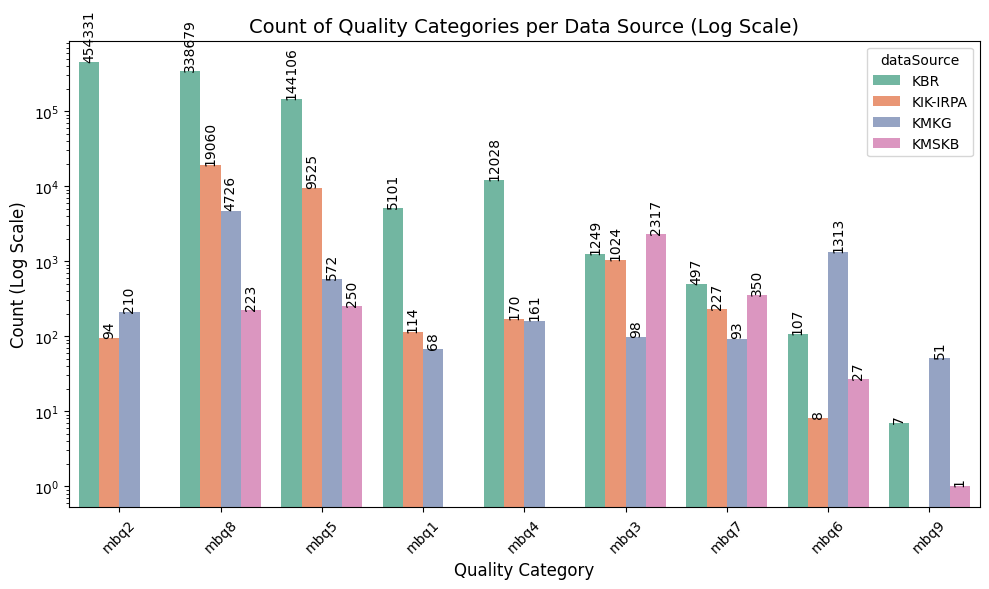

In [273]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# Create the bar plot
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=allInfoDfCategories, x='qualityCategory', hue='dataSource', palette='Set2')

# Add the total count labels on top of each bar
for p in ax.patches:
    # Get the height (count) of each bar
    height = int(p.get_height())
    # Get the x position for placing the label (centered above the bar)
    x = p.get_x() + p.get_width() / 2
    # Add the label with the count
    ax.annotate(f'{height}', (x, height), ha='center', va='bottom', fontsize=10, rotation=90)

# Set logarithmic scale for the y-axis
ax.set_yscale('log')

# Customize the plot labels and title
ax.set_xlabel('Quality Category', fontsize=12)
ax.set_ylabel('Count (Log Scale)', fontsize=12)
ax.set_title('Count of Quality Categories per Data Source (Log Scale)', fontsize=14)

# Show the plot
plt.xticks(rotation=45)  # Rotate x-ticks if necessary
plt.tight_layout()

plt.savefig('quality-categories-logarithmic-totals.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.savefig('quality-categories-logarithmic-totals.png', format='png', dpi=300, bbox_inches='tight')
plt.show()


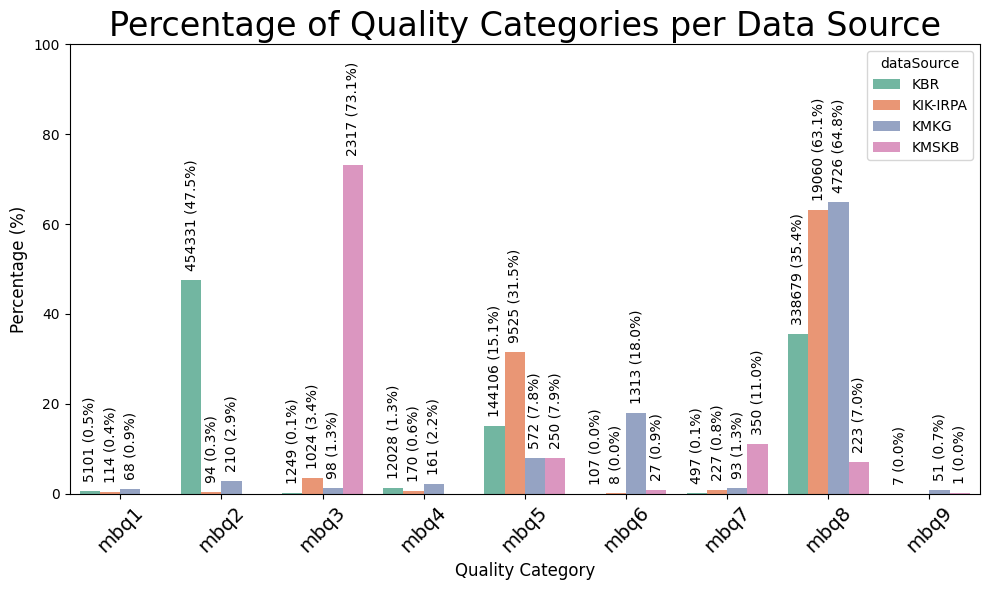

In [274]:
# Calculate the count of each combination of 'qualityCategory' and 'dataSource'
category_counts = allInfoDfCategories.groupby(['qualityCategory', 'dataSource']).size().reset_index(name='count')

# Calculate the total count for each 'dataSource'
total_counts_per_source = allInfoDfCategories['dataSource'].value_counts().reset_index(name='total_count').rename(columns={'index': 'dataSource'})

# Merge the category counts with the total counts to calculate percentages
category_counts = category_counts.merge(total_counts_per_source, on='dataSource')

# Calculate the percentage of each qualityCategory per dataSource
category_counts['percentage'] = (category_counts['count'] / category_counts['total_count']) * 100

# Create the bar plot with percentages
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=category_counts, x='qualityCategory', y='percentage', hue='dataSource', palette='Set2')

# Add the labels on top of each bar
for p, (count, percentage) in zip(ax.patches, zip(category_counts['count'], category_counts['percentage'])):
    height = p.get_height()
    x = p.get_x() + p.get_width() / 2
    offset = max(2, height * 0.02)  # Ensures at least 2% distance but scales with height
    
    # Format as "2417 (17.3%)"
    label = f"{count} ({percentage:.1f}%)"
    
    # Add the annotation
    ax.annotate(label, (x, height + offset), ha='center', va='bottom', fontsize=10, rotation=90)

# Customize the plot labels and title
ax.set_xlabel('Quality Category', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Percentage of Quality Categories per Data Source', fontsize=24)

# Fix y-axis to 100%
ax.set_ylim(0, 100)

# Rotate x-ticks for better readability
plt.xticks(rotation=45, fontsize=14)

# Ensure layout doesn't cut off labels
plt.tight_layout()

plt.savefig('quality-categories-percentages.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.savefig('quality-categories-percentages.png', format='png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()



In [275]:
allInfoDfCategories['qualityCategory'].value_counts()

qualityCategory
mbq2    454635
mbq8    362688
mbq5    154453
mbq4     12359
mbq1      5283
mbq3      4688
mbq6      1455
mbq7      1167
mbq9        59
Name: count, dtype: int64

In [276]:
allInfoDfCategories[allInfoDfCategories['name'].isna()]['qualityCategory'].value_counts(dropna=False)

qualityCategory
mbq8    467
mbq9     59
mbq6      9
mbq2      2
mbq4      2
Name: count, dtype: int64

In [277]:
allInfoDfCategories[(allInfoDfCategories["qualityCategory"] == 'mbq4') & (allInfoDfCategories["dataSource"] != 'KBR')][['name', 'geonameIDBirth', 'placenameBirth', 'birthPlace', 'countryCodeBirth', 'geonameIDDeath', 'placenameDeath', 'deathPlace', 'countryCodeDeath', 'birthDateEDTF', 'deathDateEDTF']]

,name,geonameIDBirth,placenameBirth,birthPlace,countryCodeBirth,geonameIDDeath,placenameDeath,deathPlace,countryCodeDeath,birthDateEDTF,deathDateEDTF
autID,,,,,,,,,,,
kik-irpa|100021,"[Stacquet, Henry]",2800866,Brussels,[Bruxelles],BE,NaN,NaN,[Schaarbeek],NaN,1838,1906
kik-irpa|100136,"[Deseyn, Norbert]",NaN,NaN,[Tielt],NaN,NaN,NaN,NaN,NaN,1945,1969
kik-irpa|100276,"[Degand, Victor]",NaN,NaN,[Alost[localité]],NaN,NaN,NaN,NaN,NaN,1889,1968
kik-irpa|100521,"[Feremans-Warzée, Adrienne]",2797694,Genappe,[Genappe],BE,NaN,NaN,[Schaarbeek],NaN,1888,1965
kik-irpa|101782,"[Bartlett, Charles William]",NaN,NaN,[Bridport[GB]],NaN,5855797,Hawaii,NaN,US,1860,1940
...,...,...,...,...,...,...,...,...,...,...,...
kmkg|921,"[Berg, Soren]",NaN,NaN,"[{'birthTown': '', 'birthCountry': 'Danemark'}]",NaN,NaN,NaN,"[{'deathTown': '', 'deathCountry': 'Danemark'}]",NaN,1897,1987
kmkg|9276,[Takagi Shirō],NaN,NaN,"[{'birthTown': '', 'birthCountry': 'Japon'}]",NaN,NaN,NaN,NaN,NaN,1934,1998
kmkg|9326,[Utagawa Toyonobu],NaN,NaN,"[{'birthTown': '', 'birthCountry': 'Japon'}]",NaN,NaN,NaN,NaN,NaN,1859-11,NaN


In [278]:
# debug adding of quality category one by one and inspect after each assignment 
# to see if one category all of a sudden swallows another
#
#allInfoDfCategories['qualityCategoryTest'] = np.nan
#allInfoDfCategories.loc[mbq1Mask, 'qualityCategoryTest'] = 'mbq1'
#allInfoDfCategories.loc[mbq2Mask, 'qualityCategoryTest'] = 'mbq2'
#allInfoDfCategories.loc[mbq3Mask, 'qualityCategoryTest'] = 'mbq3'
#allInfoDfCategories.loc[mbq4Mask, 'qualityCategoryTest'] = 'mbq4'
#allInfoDfCategories.loc[mbq5Mask, 'qualityCategoryTest'] = 'mbq5'
#allInfoDfCategories.loc[mbq6Mask, 'qualityCategoryTest'] = 'mbq6'
#allInfoDfCategories.loc[mbq7Mask, 'qualityCategoryTest'] = 'mbq7'

In [279]:
#allInfoDfCategories['qualityCategoryTest'].value_counts()

### Spatio temporal stats
After we organized all standardized data in a dataframe we can query some data to get some insights into spatio temporal statistics.

In [280]:
allInfoDfCategories['birthDateEDTF'].isna().value_counts()

birthDateEDTF
True     789713
False    207074
Name: count, dtype: int64

In [281]:
allInfoDfCategories.columns

Index(['name', 'alternateNames', 'isni', 'viaf', 'geonameIDBirth',
       'geonameIDDeath', 'placenameBirth', 'birthPlace', 'placenameDeath',
       'deathPlace', 'dataSource', 'website', 'relationshipTypeBirth',
       'relationshipTypeDeath', 'placeCommentBirth', 'placeCommentDeath',
       'birthDateEDTF', 'deathDateEDTF', 'countryCodeBirth',
       'countryCodeDeath', 'qualityCategory'],
      dtype='object')

In [282]:
allInfoDfCategories['certainBirthDate'] = allInfoDfCategories['birthDateEDTF'].apply(notebook_utils.isCertainEDTFDate)

In [283]:
allInfoDfCategories[(allInfoDfCategories['countryCodeBirth'] == 'BE') & ((allInfoDfCategories['certainBirthDate'] == True) & (allInfoDfCategories['birthDateEDTF'] < '1830')) ]

,name,alternateNames,isni,viaf,geonameIDBirth,geonameIDDeath,placenameBirth,birthPlace,placenameDeath,deathPlace,...,relationshipTypeBirth,relationshipTypeDeath,placeCommentBirth,placeCommentDeath,birthDateEDTF,deathDateEDTF,countryCodeBirth,countryCodeDeath,qualityCategory,certainBirthDate
autID,,,,,,,,,,,,,,,,,,,,,
kbr|10039097,"[Simon, Jean-Henri]",NaN,[0000 0003 9022 4026],NaN,2800866,2800866,Brussels,[Bruxelles],Brussels,[Bruxelles],...,NaN,NaN,NaN,NaN,1752-10-28,1834-03-12,BE,BE,mbq1,True
kbr|10039434,"[Philippe le Beau, Filips de Schone]","[Filips I, Koning van Castilië, Philippe le Beau, Philip the fair, Philippe I, roi de Castille]",[0000 0001 0823 5048],NaN,2800931,3127461,Bruges,[Bruges (Belgique)],Burgos,[Burgos (Espagne)],...,NaN,NaN,NaN,NaN,1478-07-22,1506-09-25,BE,ES,mbq1,True
kbr|10039589,"[Hart, Laurent Joseph]",NaN,[0000 0005 2792 7559],NaN,2803138,2800866,Antwerp,"[Antwerpen (België), Antwerpen]",Brussels,"[Brussel (België), Brussel]",...,NaN,NaN,NaN,NaN,1810-12-06,1860-01-10,BE,BE,mbq1,True
kbr|10039630,"[Braemt, Joseph-Pierre]",NaN,[0000 0003 9284 1888],NaN,2797656,2800866,Ghent,[Gand],Brussels,[Bruxelles],...,NaN,NaN,NaN,NaN,1796,1864,BE,BE,mbq1,True
kbr|10164935,"[Sigart, Joseph-Désiré]",NaN,NaN,NaN,2790869,2795011,Mons,[Mons],Ixelles-Elsene,[Ixelles],...,NaN,NaN,NaN,NaN,1798-09-03,1869-04-15,BE,BE,mbq3,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
kmskb|509/866,"[WILDENS, Jan]",NaN,NaN,NaN,2803138,2803138,Antwerp,[Antwerpen [dut]],Antwerp,[Antwerpen [dut]],...,NaN,NaN,NaN,NaN,1586,1653,BE,BE,mbq3,True
kmskb|509/870,"[VAN WINGHE, Joos]",NaN,NaN,NaN,2800866,2925533,Brussels,[Brussel [dut]],Frankfurt,"[Frankfurt am Main, Hessen (Duitsland) [dut]]",...,NaN,NaN,NaN,NaN,1544,1603,BE,DE,mbq3,True
kmskb|509/93,"[SIMONIS, Eugène]",NaN,NaN,NaN,2792413,2794190,Liège,[Luik [dut]],Koekelberg,[Koekelberg / Brussel [dut]],...,NaN,NaN,NaN,NaN,1810,1882,BE,BE,mbq3,True


In [284]:
allInfoDfCategories.columns

Index(['name', 'alternateNames', 'isni', 'viaf', 'geonameIDBirth',
       'geonameIDDeath', 'placenameBirth', 'birthPlace', 'placenameDeath',
       'deathPlace', 'dataSource', 'website', 'relationshipTypeBirth',
       'relationshipTypeDeath', 'placeCommentBirth', 'placeCommentDeath',
       'birthDateEDTF', 'deathDateEDTF', 'countryCodeBirth',
       'countryCodeDeath', 'qualityCategory', 'certainBirthDate'],
      dtype='object')

<Figure size 1400x800 with 0 Axes>

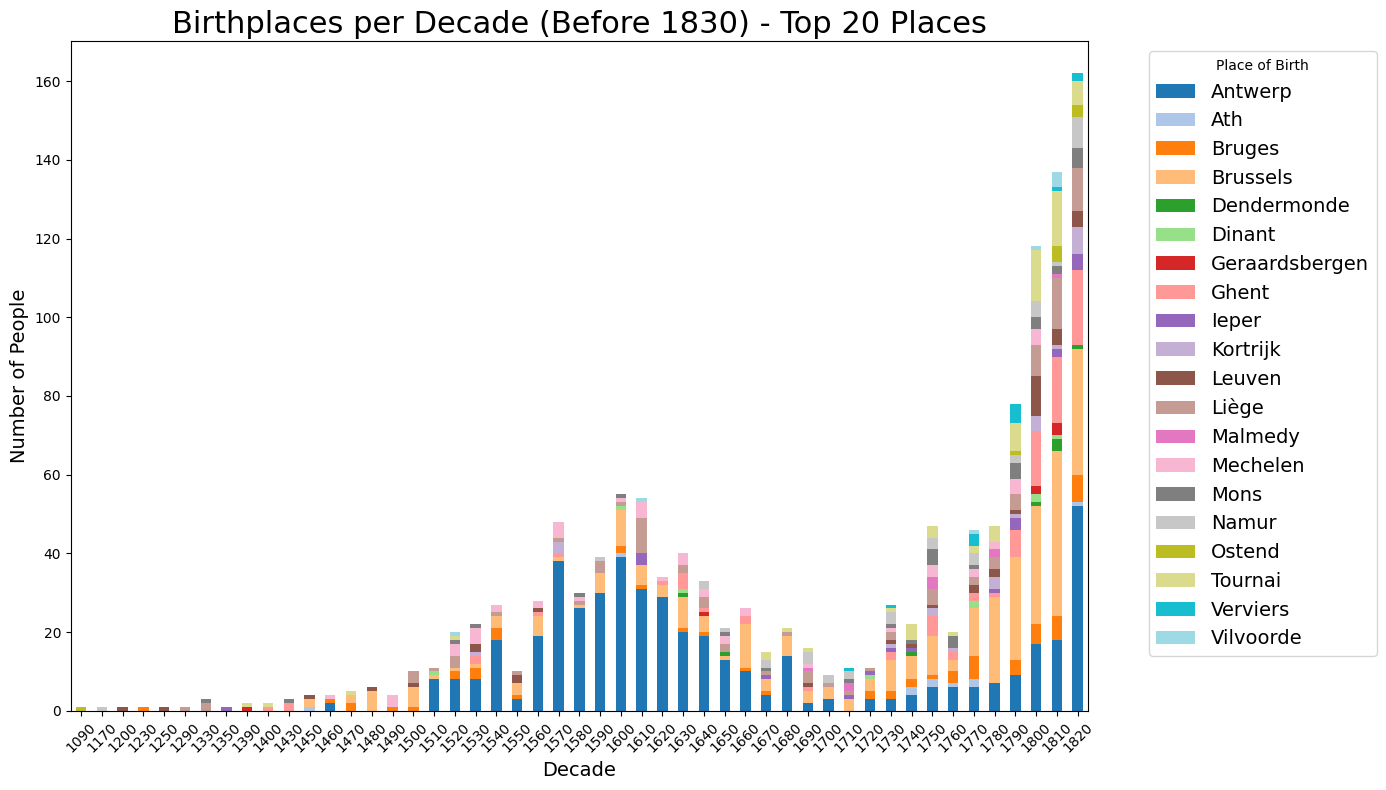

In [285]:
# Set the number of top places to include
TOP_X = 20  # Change this to the desired number

# Filter dataset for people born in Belgium before 1830
filtered_df = allInfoDfCategories[
    (allInfoDfCategories['countryCodeBirth'] == 'BE') &
    (allInfoDfCategories['certainBirthDate'] == True) &
    (allInfoDfCategories['birthDateEDTF'] < '1830')
].copy()

# Extract birth year safely
filtered_df['birthYear'] = pd.to_numeric(filtered_df['birthDateEDTF'].str[:4], errors='coerce')

# Remove NaN values and convert to integer
filtered_df = filtered_df.dropna(subset=['birthYear'])
filtered_df['birthYear'] = filtered_df['birthYear'].astype(int)

# Calculate decade
filtered_df['decade'] = (filtered_df['birthYear'] // 10) * 10

# Get top X places with most occurrences
top_places = filtered_df['placenameBirth'].value_counts().nlargest(TOP_X).index

# Filter dataset to include only top X places
filtered_df = filtered_df[filtered_df['placenameBirth'].isin(top_places)]

# Count occurrences per decade and place name
decade_counts = filtered_df.groupby(['decade', 'placenameBirth']).size().reset_index(name='count')

# Pivot to wide format for stacked bar chart
pivot_df = decade_counts.pivot(index='decade', columns='placenameBirth', values='count').fillna(0)

# Plot stacked bar chart
plt.figure(figsize=(14, 8))
pivot_df.plot(kind='bar', stacked=True, colormap='tab20', figsize=(14, 8))

plt.title(f'Birthplaces per Decade (Before 1830) - Top {TOP_X} Places', fontsize=22)
plt.xlabel('Decade', fontsize=14)
plt.ylabel('Number of People', fontsize=14)
plt.xticks(rotation=45)
plt.legend(title='Place of Birth', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=14)
plt.tight_layout()

plt.savefig(f'birthplace-per-decade-before-1830-top-{TOP_X}.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'birthplace-per-decade-before-1830-top-{TOP_X}.png', format='png', dpi=300, bbox_inches='tight')
plt.show()


allInfoDfCategories